# Thesis Figures Notebook

This notebook generates and/or documents the figures used in the thesis. Empirical figures are generated from repository artifacts under `final_runs/**`. Conceptual figures are implemented as reproducible vector-style Matplotlib diagrams where possible; image-generation prompts are retained only as fallback or design-draft instructions.

Primary export directory: `paper_artifacts/figures_generated/`.

## Global notebook contract
- Run top-to-bottom from a clean kernel.
- Empirical figures must be artifact-grounded and must not rely on typed benchmark numbers except validation constants.
- Conceptual figures must preserve controlled-benchmark language and avoid live-profitability or production-execution implications.
- `pnl_sum` is the primary deployment-oriented metric; `gross_pnl_sum`, `n_trades`, `trade_rate`, and `pnl_per_trade` explain signal extraction, turnover, selectivity, and cost drag.
- A manifest is written at the end of the notebook for thesis integration.


## Shared setup structure

**Planned future cells**
1. imports
2. plotting theme / style
3. export helper
4. common path configuration
5. shared artifact loaders


In [65]:
import os
import json
from pathlib import Path


def _find_repo_root_for_mpl(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "final_runs").exists() and (candidate / "paper_artifacts").exists():
            return candidate
    return start

_MPLCONFIGDIR = _find_repo_root_for_mpl() / "paper_artifacts" / ".mplconfig"
os.environ.setdefault("MPLCONFIGDIR", str(_MPLCONFIGDIR))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch, FancyArrowPatch, Circle


In [66]:
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "grid.linestyle": "--",
})

THESIS_COLORS = {
    "navy": "#1f4e79",
    "teal": "#2a9d8f",
    "orange": "#f4a261",
    "slate": "#64748b",
    "ink": "#0f172a",
    "light_blue": "#e8f1fb",
    "light_teal": "#e5f4f1",
    "light_orange": "#fff0df",
    "light_slate": "#f1f5f9",
    "green": "#54a24b",
    "red": "#e45756",
    "purple": "#7c3aed",
}

FAMILY_COLORS = {
    "base-gnn": "#4c78a8",
    "multi-gnn": "#72b7b2",
    "memory-gnn": "#f58518",
}

RELATION_COLORS = {
    "price_dep": THESIS_COLORS["navy"],
    "order_flow": THESIS_COLORS["teal"],
    "liquidity": THESIS_COLORS["orange"],
}


def thesis_box(
    ax,
    xy,
    width,
    height,
    title,
    body="",
    facecolor=None,
    edgecolor="none",
    title_color=None,
    body_color="#334155",
    fontsize=9,
    title_size=10,
    align="center",
):
    """Draw a rounded publication-style annotation box."""
    facecolor = facecolor or THESIS_COLORS["light_slate"]
    title_color = title_color or THESIS_COLORS["ink"]
    patch = FancyBboxPatch(
        xy,
        width,
        height,
        boxstyle="round,pad=0.018,rounding_size=0.025",
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=0.8,
        alpha=0.98,
    )
    ax.add_patch(patch)
    x, y = xy
    ha = align
    tx = x + width / 2 if align == "center" else x + 0.025
    ax.text(tx, y + height * 0.66, title, ha=ha, va="center", fontsize=title_size, fontweight="bold", color=title_color)
    if body:
        ax.text(tx, y + height * 0.34, body, ha=ha, va="center", fontsize=fontsize, color=body_color, linespacing=1.25)
    return patch


def thesis_arrow(ax, start, end, color=None, lw=1.6, rad=0.0, mutation_scale=13, linestyle="-"):
    """Draw a consistent arrow for conceptual thesis diagrams."""
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=mutation_scale,
        linewidth=lw,
        linestyle=linestyle,
        color=color or THESIS_COLORS["slate"],
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=4,
        shrinkB=4,
    )
    ax.add_patch(arrow)
    return arrow


In [67]:
def find_repo_root(start=None):
    """Find the repository root from any notebook working directory."""
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "final_runs").exists() and (candidate / "paper_artifacts").exists():
            return candidate
    raise RuntimeError("Could not find repo root containing final_runs/ and paper_artifacts/")


REPO_ROOT = find_repo_root()
THESIS_PATH = REPO_ROOT / "paper_artifacts" / "good_Paper_draft.md"
FIGURES_DIR = REPO_ROOT / "paper_artifacts" / "figures_generated"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_REGISTRY = []


def _rel(path):
    path = Path(path)
    try:
        return str(path.relative_to(REPO_ROOT))
    except ValueError:
        return str(path)


def save_thesis_figure(
    fig,
    figure_id,
    filename_stem,
    title,
    source_artifacts,
    rendering_method,
    main_text_section,
    status="implemented",
    validation_checks="Generated file is non-empty; semantic checks documented in notebook section.",
    save_vector=True,
):
    """Save a thesis figure and append a manifest row.

    PNG is used by the markdown thesis draft. SVG is retained for vector-quality
    export when Matplotlib can produce it.
    """
    png = FIGURES_DIR / f"{filename_stem}.png"
    svg = FIGURES_DIR / f"{filename_stem}.svg"
    fig.savefig(png, bbox_inches="tight", dpi=300)
    svg_value = ""
    if save_vector:
        fig.savefig(svg, bbox_inches="tight")
        svg_value = _rel(svg)
    # Keep repeated notebook execution from duplicating rows.
    FIGURE_REGISTRY[:] = [row for row in FIGURE_REGISTRY if row["figure_id"] != figure_id]
    FIGURE_REGISTRY.append({
        "figure_id": figure_id,
        "title": title,
        "filename_png": _rel(png),
        "filename_svg_or_pdf": svg_value,
        "rendering_method": rendering_method,
        "source_artifacts": "; ".join(_rel(pth) for pth in source_artifacts),
        "main_text_section": main_text_section,
        "status": status,
        "validation_checks": validation_checks,
    })
    return png


def write_manifest():
    manifest = pd.DataFrame(FIGURE_REGISTRY, columns=[
        "figure_id",
        "title",
        "filename_png",
        "filename_svg_or_pdf",
        "rendering_method",
        "source_artifacts",
        "main_text_section",
        "status",
        "validation_checks",
    ])
    csv_path = FIGURES_DIR / "figure_manifest.csv"
    md_path = FIGURES_DIR / "figure_manifest.md"
    manifest.to_csv(csv_path, index=False)
    rows = ["| " + " | ".join(manifest.columns) + " |", "| " + " | ".join(["---"] * len(manifest.columns)) + " |"]
    for _, row in manifest.fillna("").iterrows():
        rows.append("| " + " | ".join(str(row[col]).replace("|", "\\|") for col in manifest.columns) + " |")
    md_path.write_text("\n".join(rows) + "\n", encoding="utf-8")
    return manifest, csv_path, md_path


In [68]:
SPLIT_PATHS = {
    "5min": REPO_ROOT / "final_runs/5min-base-gnn/splits/split_summary.json",
    "1min": REPO_ROOT / "final_runs/1min-base-gnn-conv/splits/split_summary.json",
    "1sec": REPO_ROOT / "final_runs/1sec-base-gnn-conv/splits/split_summary.json",
}
FINAL_HOLDOUT_ALIGNMENT_PATH = REPO_ROOT / "paper_artifacts/final_holdout_alignment_table.csv"

REGIME_SPECS = {
    "5min": {"run": "5min-base-gnn", "lookback": "30 min = 6 bars", "horizon": "5 min = 1 bar", "task_note": "same clock-time task as 1min"},
    "1min": {"run": "1min-base-gnn-conv", "lookback": "30 min = 30 bars", "horizon": "5 min = 5 bars", "task_note": "reference clock-time task"},
    "1sec": {"run": "1sec-base-gnn-conv", "lookback": "2 min = 120 bars", "horizon": "2 min = 120 bars", "task_note": "adapted high-frequency stress test"},
}


In [69]:
PRIMARY_BENCHMARK_SOURCES = {
    ("5min", "base-gnn-conv"): (REPO_ROOT / "final_runs/5min-base-gnn/final_report.csv", "adaptive_conv"),
    ("5min", "base-gnn-mpnn"): (REPO_ROOT / "final_runs/5min-base-gnn/final_report.csv", "adaptive_mpnn"),
    ("5min", "multi-gnn-conv"): (REPO_ROOT / "final_runs/5min-multi-gnn/final_report.csv", "dynamic_rel_conv"),
    ("5min", "multi-gnn-mpnn"): (REPO_ROOT / "final_runs/5min-multi-gnn/final_report.csv", "dynamic_edge_mpnn"),
    ("5min", "memory-gnn-conv"): (REPO_ROOT / "final_runs/5min-memory-gnn/final_report.csv", "conv"),
    ("5min", "memory-gnn-mpnn"): (REPO_ROOT / "final_runs/5min-memory-gnn/final_report.csv", "mpnn"),
    ("1min", "base-gnn-conv"): (REPO_ROOT / "final_runs/1min-base-gnn-conv/final_report.csv", None),
    ("1min", "base-gnn-mpnn"): (REPO_ROOT / "final_runs/1min-base-gnn-mpnn/final_report.csv", None),
    ("1min", "multi-gnn-conv"): (REPO_ROOT / "final_runs/1min-multi-gnn-conv/final_report.csv", None),
    ("1min", "multi-gnn-mpnn"): (REPO_ROOT / "final_runs/1min-multi-gnn-mpnn/final_report.csv", None),
    ("1min", "memory-gnn-conv"): (REPO_ROOT / "final_runs/1min-memory-gnn/final_report.csv", "conv"),
    ("1min", "memory-gnn-mpnn"): (REPO_ROOT / "final_runs/1min-memory-gnn/final_report.csv", "mpnn"),
    ("1sec", "base-gnn-conv"): (REPO_ROOT / "final_runs/1sec-base-gnn-conv/final_report.csv", None),
    ("1sec", "base-gnn-mpnn"): (REPO_ROOT / "final_runs/1sec-base-gnn-mpnn/final_report.csv", None),
    ("1sec", "multi-gnn-conv"): (REPO_ROOT / "final_runs/1sec-multi-gnn-conv/final_report.csv", None),
    ("1sec", "multi-gnn-mpnn"): (REPO_ROOT / "final_runs/1sec-multi-gnn-mpnn/final_report.csv", None),
    ("1sec", "memory-gnn-conv"): (REPO_ROOT / "final_runs/1sec-memory-gnn-conv/final_report.csv", None),
    ("1sec", "memory-gnn-mpnn"): (REPO_ROOT / "final_runs/1sec-memory-gnn-mpnn/final_report.csv", None),
}

BENCHMARK_ORDER = [
    "base-gnn-conv",
    "base-gnn-mpnn",
    "multi-gnn-conv",
    "multi-gnn-mpnn",
    "memory-gnn-conv",
    "memory-gnn-mpnn",
]
FREQUENCY_ORDER = ["5min", "1min", "1sec"]
TRADE_COST = 0.0003


def load_split_summary(freq):
    with open(SPLIT_PATHS[freq], "r", encoding="utf-8") as f:
        return json.load(f)


def load_benchmark_metrics(model_state="last_cv", validate_cost=True):
    """Return the normalized benchmark table used by Figures 5.1, 5.4, D.1, and D.2."""
    rows = []
    for (freq, label), (csv_path, operator_filter) in PRIMARY_BENCHMARK_SOURCES.items():
        if not csv_path.exists():
            raise FileNotFoundError(csv_path)
        df = pd.read_csv(csv_path)
        df = df[df["model_state"] == model_state].copy()
        if operator_filter is not None and "operator" in df.columns:
            df = df[df["operator"] == operator_filter].copy()
        if df.empty:
            raise ValueError(f"No rows found for {freq} {label} ({model_state}) in {csv_path}")
        row = df.iloc[0].to_dict()
        row["frequency"] = freq
        row["model_label"] = label
        row["source_csv"] = csv_path
        rows.append(row)
    out = pd.DataFrame(rows)
    out["family"] = out["model_label"].str.extract(r"^(base-gnn|multi-gnn|memory-gnn)")
    out["operator_short"] = out["model_label"].str.extract(r"(conv|mpnn)$")[0].str.upper()
    out["x_label"] = out["family"].map({"base-gnn": "Base", "multi-gnn": "Multi", "memory-gnn": "Memory"}) + "\n" + out["operator_short"]
    out["order"] = out["model_label"].map({label: i for i, label in enumerate(BENCHMARK_ORDER)})
    out["frequency_order"] = out["frequency"].map({freq: i for i, freq in enumerate(FREQUENCY_ORDER)})
    out["cost_drag"] = out["gross_pnl_sum"] - out["pnl_sum"]
    out["implied_cost_drag"] = out["n_trades"] * TRADE_COST
    if validate_cost:
        cost_rows = out[["gross_pnl_sum", "pnl_sum", "n_trades"]].notna().all(axis=1)
        if cost_rows.any() and not np.allclose(out.loc[cost_rows, "cost_drag"], out.loc[cost_rows, "implied_cost_drag"], atol=1e-8):
            bad = out.loc[~np.isclose(out["cost_drag"], out["implied_cost_drag"], atol=1e-8), ["frequency", "model_label", "cost_drag", "implied_cost_drag"]]
            raise AssertionError(f"Benchmark cost-drag validation failed:\n{bad}")
    return out.sort_values(["frequency_order", "order"]).reset_index(drop=True)


# Backwards-compatible name used by earlier notebook cells.
def load_primary_benchmark_table(model_state="last_cv"):
    return load_benchmark_metrics(model_state=model_state)


## Figure 1.1 — Conceptual pipeline from limit order book snapshots to graph-based entry decisions

**Why this format**
- Hybrid is best because the figure is conceptual, but its objects are tightly tied to repo terminology and thesis pipeline stages.

**Metadata**
- Figure type: `hybrid`
- Evidence source: `mixed`
- Rendering method: `Prompt-first hybrid`
- Primary inputs: `co_om_thesis_enhanced.md`, `train_config.yaml`, `models/base_gnn_pipeline.py`, `models/multigraph_pipeline.py`, `models/memorygraph_pipeline.py`
- Acceptance check: ADA/BTC/ETH inputs, node features, relation-aware edges, graph prediction stage, entry decision, cost-aware final-holdout backtest


**Generation body — final image prompt**

```text
Create a clean academic systems diagram for a master's thesis in quantitative finance.

Title: "Conceptual pipeline from limit order book snapshots to graph-based entry decisions"

Style requirements:
- white background
- publication-quality vector-like look
- minimal color palette: dark blue, muted teal, gray, subtle orange accents
- professional academic layout, no marketing style
- landscape orientation
- sharp readable labels
- consistent arrow styles
- elegant, uncluttered composition

Diagram structure from left to right:
1. Three separate crypto limit order book snapshot panels labeled ADA, BTC, and ETH.
2. Feature extraction block with node and relation features.
3. Graph construction block with ADA, BTC, ETH and directed complete graph with self-loops.
4. Graph model block.
5. Output head block.
6. Decision block.
7. Evaluation block with realized exit, gross PnL, cost adjustment, final-holdout net PnL.

Important semantic constraint:
This is a controlled research benchmark pipeline from LOB snapshots to graph-based entry decisions and cost-aware backtest evaluation.
```


## Figure 1.2 — Research-question map for the controlled graph benchmark

**Why this format**
- Python is enough because the figure is essentially a structured mapping from RQ1–RQ4 to benchmark dimensions.

**Metadata**
- Figure type: `conceptual-executable`
- Evidence source: `thesis-only`
- Rendering method: `Python`
- Primary inputs: `co_om_thesis_enhanced.md`
- Acceptance check: RQ1→family, RQ2→Conv/MPNN, RQ3→temporal resolution, RQ4→`last_CV`/`final_refit`


**Generation body**
- Build a 4-row mapping diagram or matrix.
- Left column: `RQ1`–`RQ4`.
- Right side: benchmark dimensions with arrows / assignment cells.
- Keep the layout compact and thesis-like.

**Planned future code cells**
1. load thesis text / labels
2. prepare RQ-to-dimension structure
3. render figure
4. export figure


In [70]:
rq_mapping = [
    {"rq": "RQ1", "question": "Which graph family performs best under a controlled benchmark?", "dimension": "Model family", "detail": "base_gnn | multigraph | memorygraph", "color": "#4c78a8"},
    {"rq": "RQ2", "question": "How important is the Conv vs MPNN operator choice?", "dimension": "Graph operator", "detail": "Conv-style vs MPNN-style", "color": "#72b7b2"},
    {"rq": "RQ3", "question": "How does temporal resolution change the value of relational modelling?", "dimension": "Temporal resolution", "detail": "5min | 1min | 1sec", "color": "#f58518"},
    {"rq": "RQ4", "question": "Are conclusions stable between `last_CV` and `final_refit`?", "dimension": "Deployment state", "detail": "`last_CV` vs `final_refit`", "color": "#e45756"},
]
pd.DataFrame(rq_mapping)


,rq,question,dimension,detail,color
0,RQ1,Which graph family performs best under a contr...,Model family,base_gnn | multigraph | memorygraph,#4c78a8
1,RQ2,How important is the Conv vs MPNN operator cho...,Graph operator,Conv-style vs MPNN-style,#72b7b2
2,RQ3,How does temporal resolution change the value ...,Temporal resolution,5min | 1min | 1sec,#f58518
3,RQ4,Are conclusions stable between `last_CV` and `...,Deployment state,`last_CV` vs `final_refit`,#e45756


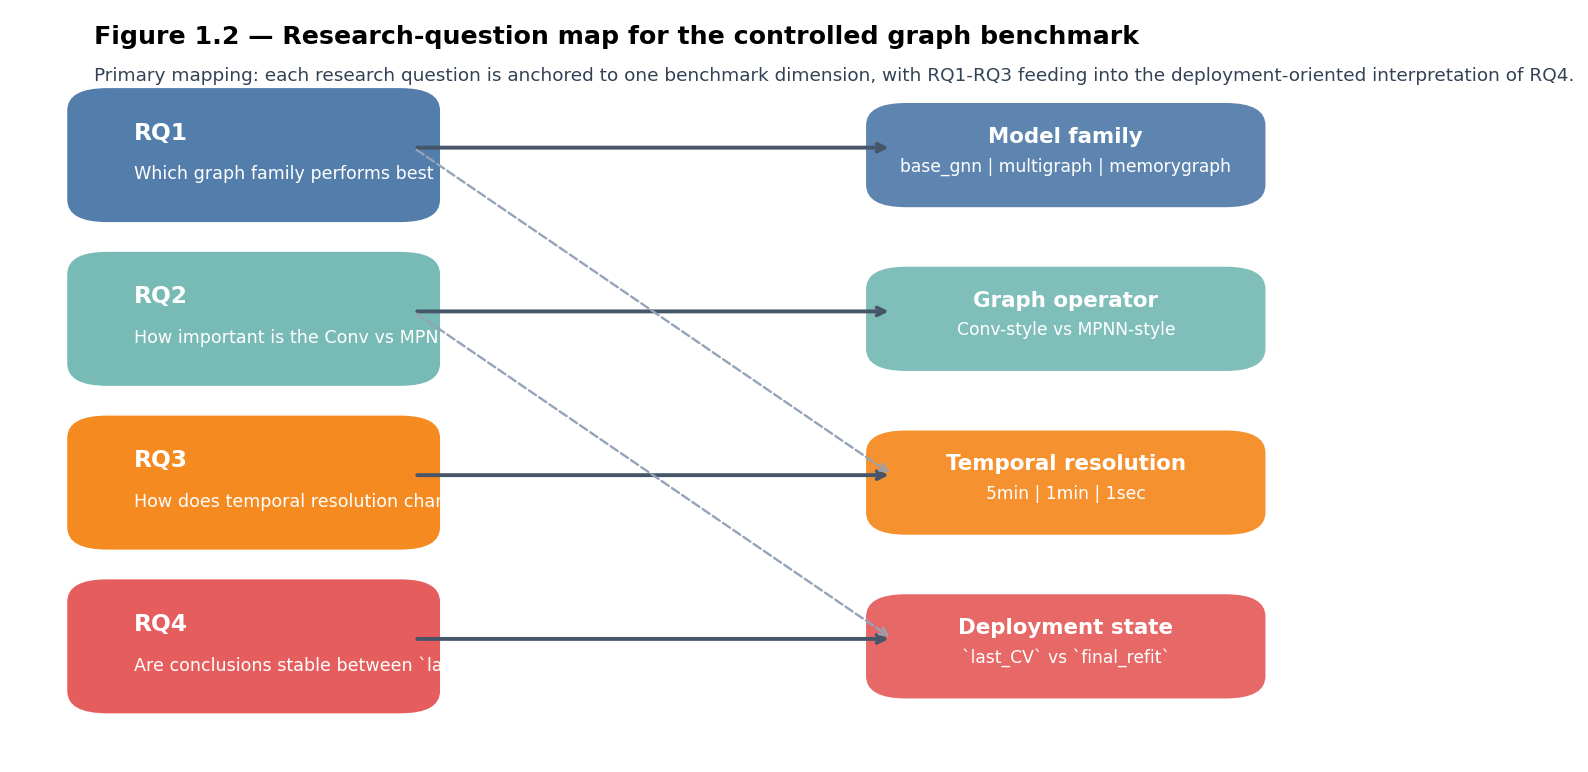

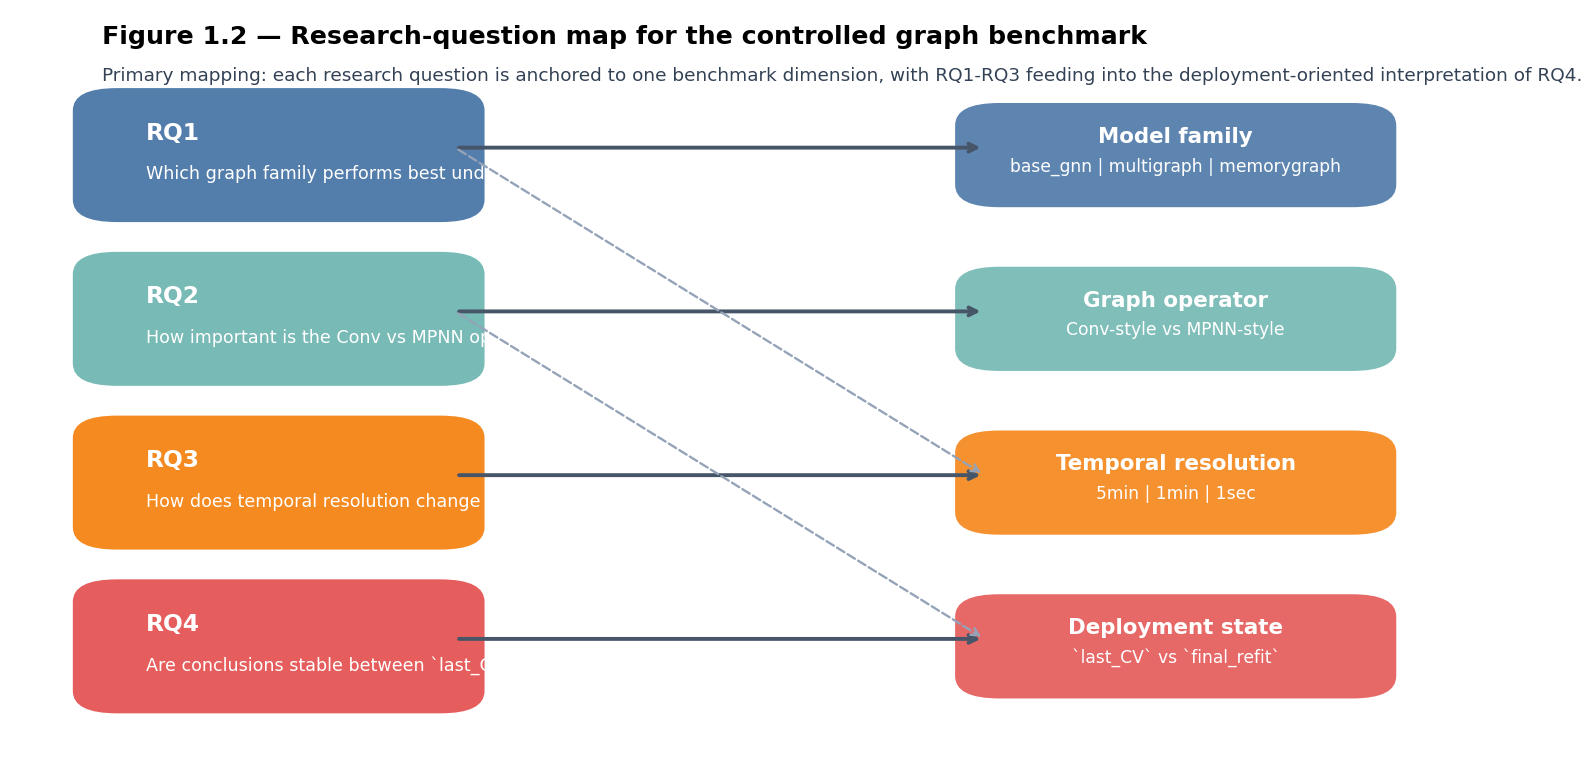

In [71]:
fig, ax = plt.subplots(figsize=(11.5, 5.4), constrained_layout=True)
ax.axis("off")
left_x = 0.06
left_positions = [0.82, 0.60, 0.38, 0.16]
right_positions = [0.82, 0.60, 0.38, 0.16]

for item, y in zip(rq_mapping, left_positions):
    box = FancyBboxPatch((left_x, y - 0.08), 0.24, 0.14, boxstyle="round,pad=0.02,rounding_size=0.03", facecolor=item["color"], edgecolor="none", alpha=0.96)
    ax.add_patch(box)
    ax.text(left_x + 0.03, y + 0.02, item["rq"], color="white", fontweight="bold", fontsize=12, ha="left", va="center")
    ax.text(left_x + 0.03, y - 0.035, item["question"], color="white", fontsize=9, ha="left", va="center")

for item, y in zip(rq_mapping, right_positions):
    box = FancyBboxPatch((0.66, y - 0.06), 0.26, 0.10, boxstyle="round,pad=0.02,rounding_size=0.03", facecolor=item["color"], edgecolor="none", alpha=0.90)
    ax.add_patch(box)
    ax.text(0.79, y + 0.015, item["dimension"], color="white", fontweight="bold", fontsize=11, ha="center", va="center")
    ax.text(0.79, y - 0.025, item["detail"], color="white", fontsize=8.8, ha="center", va="center")

for y in right_positions:
    ax.annotate("", xy=(0.66, y), xytext=(0.30, y), arrowprops=dict(arrowstyle="->", lw=2.0, color="#475569"))
ax.annotate("", xy=(0.66, 0.38), xytext=(0.30, 0.82), arrowprops=dict(arrowstyle="->", lw=1.2, color="#94a3b8", linestyle="--"))
ax.annotate("", xy=(0.66, 0.16), xytext=(0.30, 0.60), arrowprops=dict(arrowstyle="->", lw=1.2, color="#94a3b8", linestyle="--"))

ax.text(0.06, 0.96, "Figure 1.2 — Research-question map for the controlled graph benchmark", fontsize=13, fontweight="bold", ha="left")
ax.text(0.06, 0.91, "Primary mapping: each research question is anchored to one benchmark dimension, with RQ1-RQ3 feeding into the deployment-oriented interpretation of RQ4.", fontsize=9.5, color="#334155", ha="left")
fig


In [72]:
fig_1_2_path = save_thesis_figure(
    fig,
    figure_id="1.2",
    filename_stem="fig_1_2_research_question_map",
    title="Research-question map for the controlled graph benchmark",
    source_artifacts=['paper_artifacts/good_Paper_draft.md'],
    rendering_method="Python vector",
    main_text_section="Chapter 1",
    validation_checks="RQ mapping: family/operator/frequency/model-state dimensions.",
)
fig_1_2_path


PosixPath('/Users/vitalii/Desktop/Model_Market_Microstructure/GNN_for_LOB/paper_artifacts/figures_generated/fig_1_2_research_question_map.png')

In [73]:
# Optional future refinement cell:
# keep for label shortening or layout polishing if the thesis page width requires tighter spacing.


## Figure 3.1 — Graph input representation for the three-asset limit order book benchmark

**Why this format**
- Python is appropriate because the graph topology is explicit and can be rendered reproducibly, but annotations must emphasize relation semantics.

**Metadata**
- Figure type: `executable`
- Evidence source: `code-grounded`
- Rendering method: `Python`
- Primary inputs: `train_config.yaml`, `models/base_gnn_pipeline.py`, `models/multigraph_pipeline.py`, `models/memorygraph_pipeline.py`
- Acceptance check: ADA/BTC/ETH nodes, directed complete graph with self-loops, relation channels, node vs edge feature distinction


**Generation body**
- Use a fixed triangular node layout.
- Show self-loops explicitly.
- Label relation channels: `price_dep`, `order_flow`, `liquidity`.
- Add side annotation for node tensor vs relation-aware edge tensor.

**Planned future code cells**
1. load graph semantics from config/code notes
2. define topology and labels
3. render graph figure
4. export figure


In [74]:
graph_nodes = ["ADA", "BTC", "ETH"]
graph_positions = {"ADA": (0.24, 0.68), "BTC": (0.74, 0.68), "ETH": (0.49, 0.26)}
relation_channels = {
    "price_dep": "#4c78a8",
    "order_flow": "#72b7b2",
    "liquidity": "#f58518",
}
node_feature_notes = [
    "returns",
    "spread",
    "buys / sells",
    "flow imbalance",
    "depth imbalance",
    "near/far depth shape",
]
graph_nodes, relation_channels


(['ADA', 'BTC', 'ETH'],
 {'price_dep': '#4c78a8', 'order_flow': '#72b7b2', 'liquidity': '#f58518'})

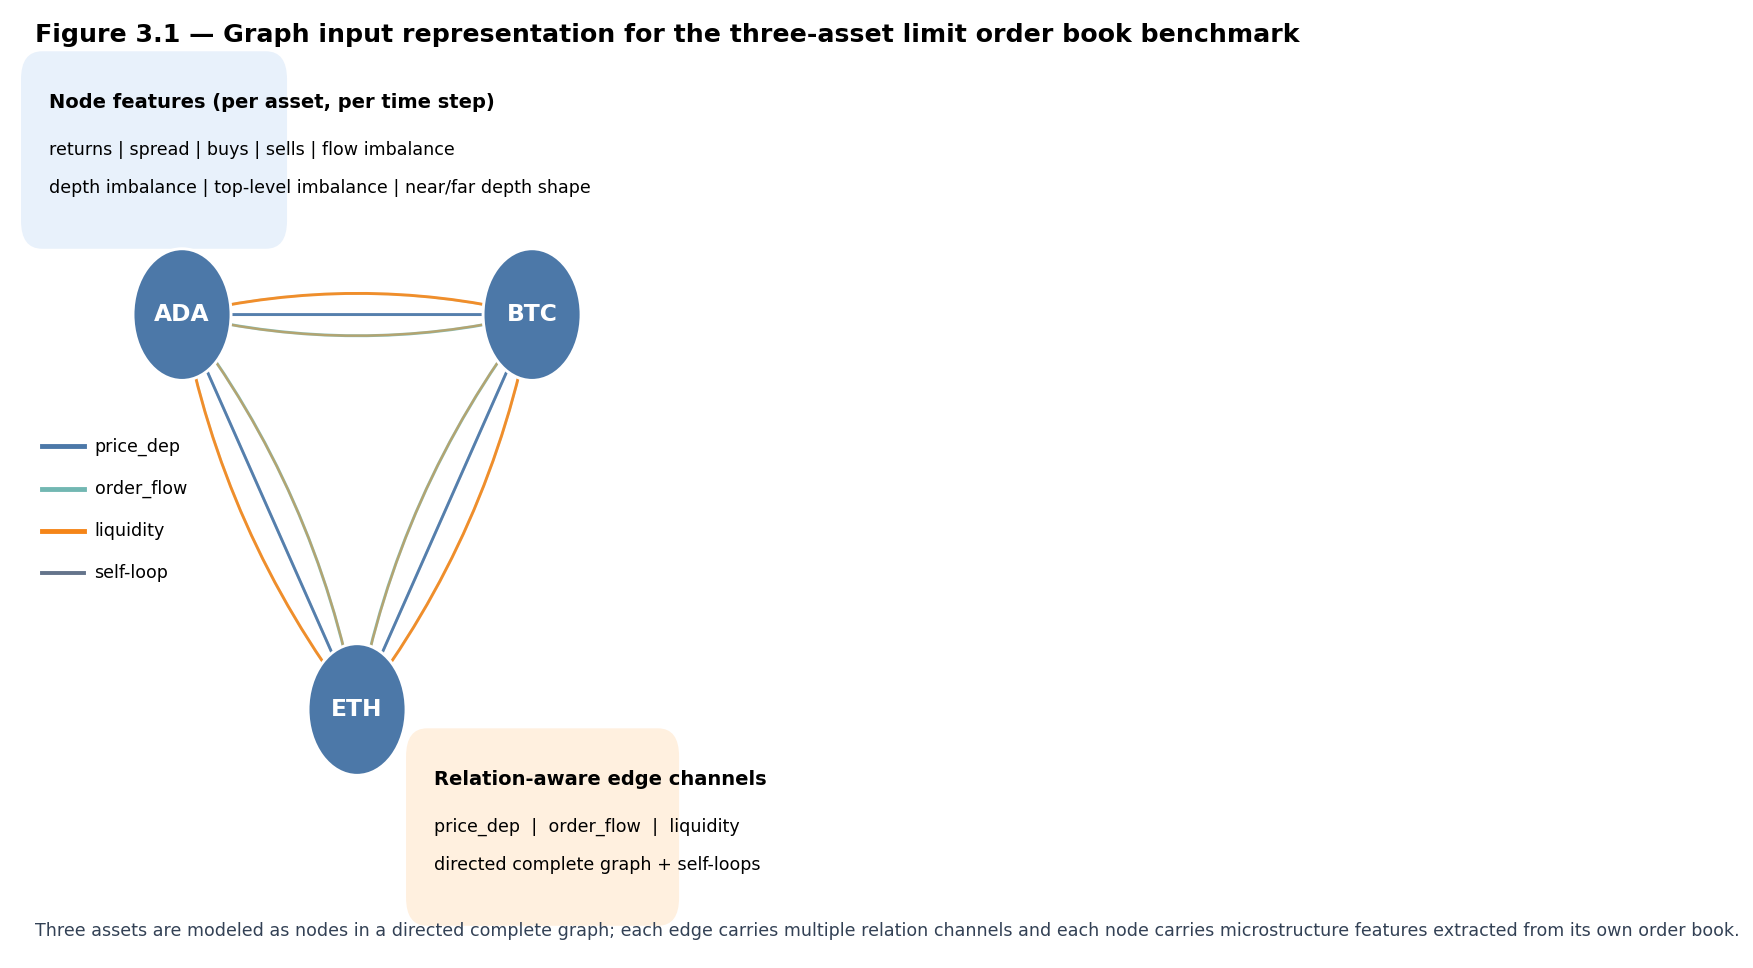

/Users/vitalii/Desktop/Model_Market_Microstructure/GNN_for_LOB/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


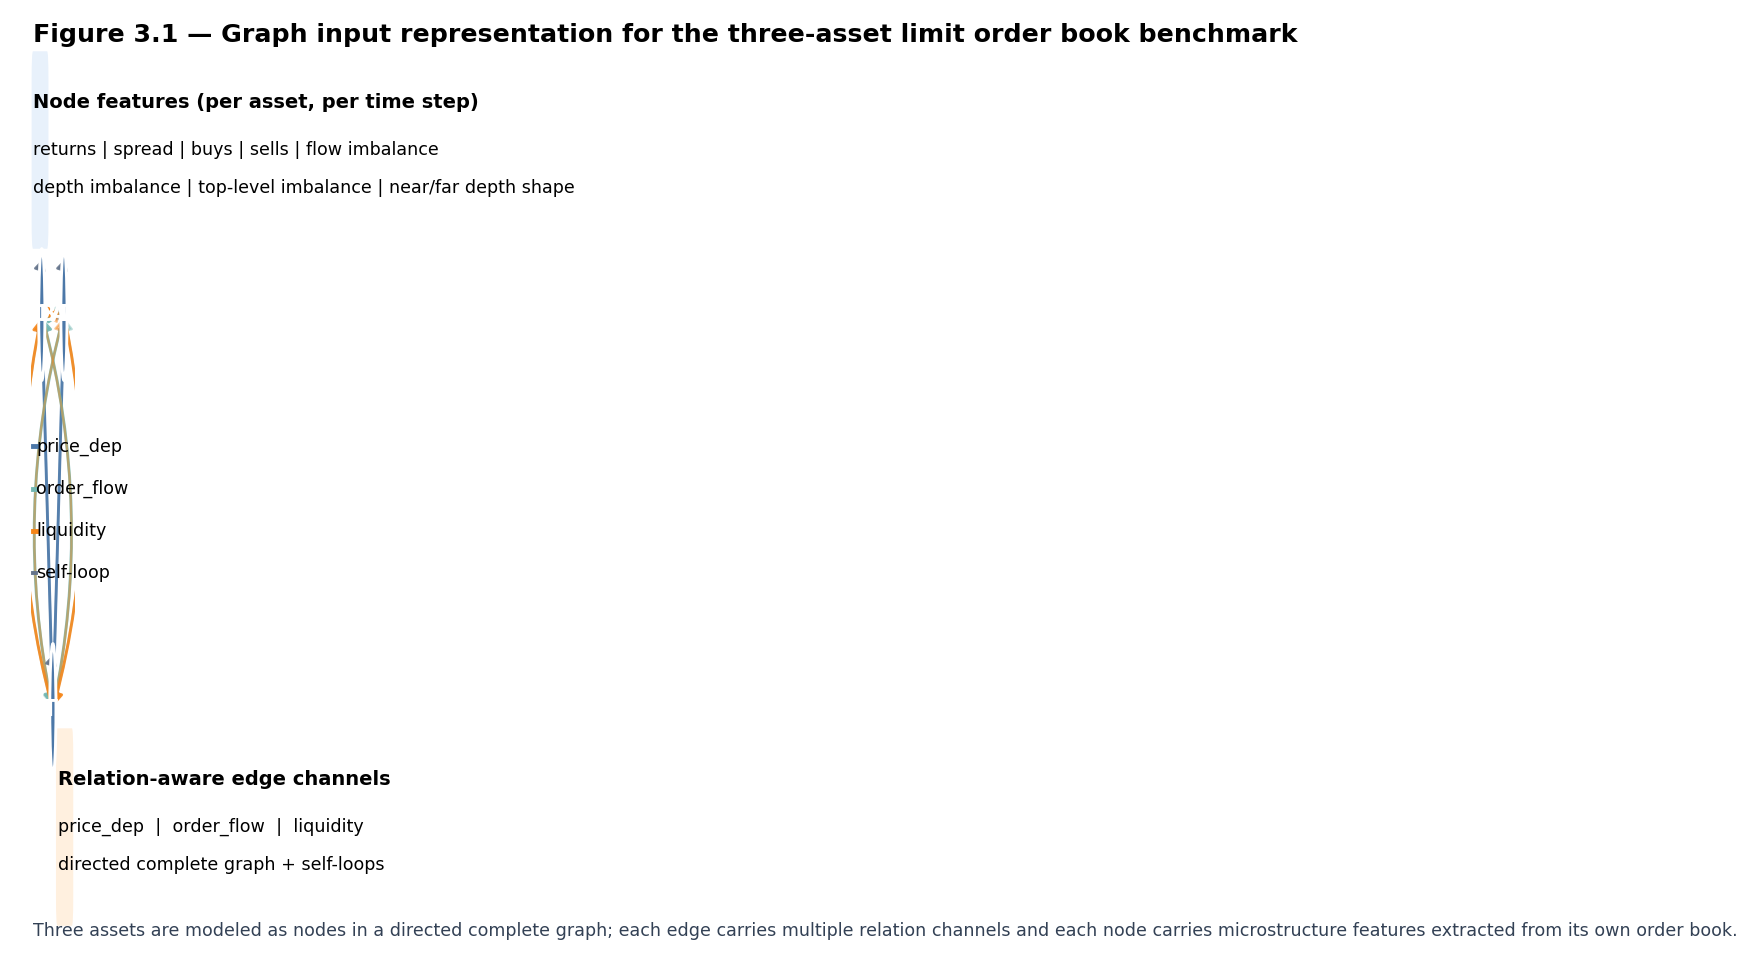

In [75]:
fig, ax = plt.subplots(figsize=(10.8, 6.8), constrained_layout=True)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

feature_box = FancyBboxPatch((0.03, 0.77), 0.34, 0.17, boxstyle="round,pad=0.02,rounding_size=0.03", facecolor="#e8f1fb", edgecolor="none")
ax.add_patch(feature_box)
ax.text(0.05, 0.90, "Node features (per asset, per time step)", fontweight="bold", fontsize=10)
ax.text(0.05, 0.85, "returns | spread | buys | sells | flow imbalance", fontsize=9)
ax.text(0.05, 0.81, "depth imbalance | top-level imbalance | near/far depth shape", fontsize=9)

relation_box = FancyBboxPatch((0.58, 0.05), 0.35, 0.17, boxstyle="round,pad=0.02,rounding_size=0.03", facecolor="#fff0df", edgecolor="none")
ax.add_patch(relation_box)
ax.text(0.60, 0.18, "Relation-aware edge channels", fontweight="bold", fontsize=10)
ax.text(0.60, 0.13, "price_dep  |  order_flow  |  liquidity", fontsize=9)
ax.text(0.60, 0.09, "directed complete graph + self-loops", fontsize=9)

cycle_pairs = [("ADA", "BTC"), ("BTC", "ETH"), ("ETH", "ADA")]
for relation_name, color, rad in [("price_dep", relation_channels["price_dep"], 0.0), ("order_flow", relation_channels["order_flow"], 0.12), ("liquidity", relation_channels["liquidity"], -0.12)]:
    for source_node, target_node in cycle_pairs:
        forward_arrow = plt.matplotlib.patches.FancyArrowPatch(graph_positions[source_node], graph_positions[target_node], connectionstyle=f"arc3,rad={rad}", arrowstyle="-|>", mutation_scale=12, linewidth=1.5, color=color, alpha=0.9)
        backward_arrow = plt.matplotlib.patches.FancyArrowPatch(graph_positions[target_node], graph_positions[source_node], connectionstyle=f"arc3,rad={rad}", arrowstyle="-|>", mutation_scale=12, linewidth=1.2, color=color, alpha=0.45)
        ax.add_patch(forward_arrow)
        ax.add_patch(backward_arrow)

for node_name, (x, y) in graph_positions.items():
    self_loop = plt.matplotlib.patches.FancyArrowPatch((x - 0.035, y + 0.06), (x + 0.035, y + 0.06), connectionstyle="arc3,rad=1.6", arrowstyle="-|>", mutation_scale=12, linewidth=1.3, color="#64748b", alpha=0.9)
    ax.add_patch(self_loop)
    node_circle = plt.Circle((x, y), 0.07, facecolor="#4c78a8", edgecolor="white", linewidth=1.5)
    ax.add_patch(node_circle)
    ax.text(x, y, node_name, color="white", fontsize=12, fontweight="bold", ha="center", va="center")

legend_y = 0.54
for i, (relation_name, color) in enumerate(relation_channels.items()):
    yy = legend_y - i * 0.045
    ax.plot([0.04, 0.10], [yy, yy], color=color, linewidth=2.5)
    ax.text(0.115, yy, relation_name, va="center", fontsize=9)
ax.plot([0.04, 0.10], [legend_y - 0.135, legend_y - 0.135], color="#64748b", linewidth=2)
ax.text(0.115, legend_y - 0.135, "self-loop", va="center", fontsize=9)

ax.text(0.03, 0.97, "Figure 3.1 — Graph input representation for the three-asset limit order book benchmark", fontsize=13, fontweight="bold", ha="left")
ax.text(0.03, 0.02, "Three assets are modeled as nodes in a directed complete graph; each edge carries multiple relation channels and each node carries microstructure features extracted from its own order book.", fontsize=9, color="#334155", ha="left")
fig


In [76]:
fig_3_1_path = save_thesis_figure(
    fig,
    figure_id="3.1",
    filename_stem="fig_3_1_graph_input_representation",
    title="Graph input representation for the three-asset LOB benchmark",
    source_artifacts=['models/base_gnn_pipeline.py', 'models/multigraph_pipeline.py'],
    rendering_method="Python vector, code-grounded",
    main_text_section="Chapter 3",
    validation_checks="Three nodes, ETH target, relation channels, tensor-shape annotations.",
)
fig_3_1_path


/var/folders/fs/1b5sy3xs1_50rf2v8vnv0s9c0000gn/T/ipykernel_14567/3458751140.py:45: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.savefig(png, bbox_inches="tight", dpi=300)
/var/folders/fs/1b5sy3xs1_50rf2v8vnv0s9c0000gn/T/ipykernel_14567/3458751140.py:48: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.savefig(svg, bbox_inches="tight")


PosixPath('/Users/vitalii/Desktop/Model_Market_Microstructure/GNN_for_LOB/paper_artifacts/figures_generated/fig_3_1_graph_input_representation.png')

In [77]:
# Optional future refinement cell:
# use this cell if you later want to increase annotation density or add tensor-shape labels.


## Figure 3.2 — Frequency regimes and final-holdout split design

**Why this format**
- Python is the right choice because the split structure exists in `split_summary.json` and should be reproduced from artifacts, not hand-drawn.

**Metadata**
- Figure type: `executable`
- Evidence source: `artifact-grounded`
- Rendering method: `Python`
- Primary inputs: `final_runs/5min-base-gnn/splits/split_summary.json`, `final_runs/1min-base-gnn-conv/splits/split_summary.json`, `final_runs/1sec-base-gnn-conv/splits/split_summary.json`
- Acceptance check: `5min`/`1min`/`1sec`, pre-holdout vs holdout, adapted 1sec regime, aligned final holdout intervals


**Generation body**
- One horizontal timeline per frequency.
- Show working slice, pre-holdout, final holdout.
- Annotate lookback / horizon / folds.
- Add note that `1sec` is a frequency-adapted stress test.

**Planned future code cells**
1. load split summaries
2. normalize timelines
3. render regime timelines
4. export figure


In [78]:
split_summaries = {freq: load_split_summary(freq) for freq in SPLIT_PATHS}
alignment_df = pd.read_csv(FINAL_HOLDOUT_ALIGNMENT_PATH)

regime_rows = []
for freq in ["5min", "1min", "1sec"]:
    summary = split_summaries[freq]
    spec = REGIME_SPECS[freq]
    artifact_row = alignment_df.loc[alignment_df["run"] == spec["run"]].iloc[0]
    work_start = float(artifact_row["data_slice_start_frac"])
    work_end = float(artifact_row["data_slice_end_frac"])
    work_width = work_end - work_start
    preholdout_end_full_frac = work_start + work_width * (float(artifact_row["preholdout_n"]) / float(artifact_row["n_samples"]))
    holdout_start_full_frac = float(artifact_row["effective_holdout_start_full_frac"])
    holdout_end_full_frac = float(artifact_row["effective_holdout_end_full_frac"])

    regime_rows.append({
        "frequency": freq,
        "run": spec["run"],
        "work_start": work_start,
        "work_end": work_end,
        "preholdout_end_full_frac": preholdout_end_full_frac,
        "holdout_start_full_frac": holdout_start_full_frac,
        "holdout_end_full_frac": holdout_end_full_frac,
        "holdout_frac_of_slice": float(artifact_row["final_holdout_frac"]),
        "lookback": spec["lookback"],
        "horizon": spec["horizon"],
        "task_note": spec["task_note"],
        "cv_folds": int(summary["num_train_folds"]),
        "purge_gap_bars": int(summary["purge_gap_bars"]),
        "holdout_start_utc": artifact_row["holdout_start_utc"],
        "holdout_end_utc": artifact_row["holdout_end_utc"],
        "start_delta_vs_1min_sec": int(artifact_row["start_delta_vs_1min_sec"]),
        "end_delta_vs_1min_sec": int(artifact_row["end_delta_vs_1min_sec"]),
    })

regime_df = pd.DataFrame(regime_rows)
regime_df


,frequency,run,work_start,work_end,preholdout_end_full_frac,holdout_start_full_frac,holdout_end_full_frac,holdout_frac_of_slice,lookback,horizon,task_note,cv_folds,purge_gap_bars,holdout_start_utc,holdout_end_utc,start_delta_vs_1min_sec,end_delta_vs_1min_sec
0,5min,5min-base-gnn,0.0,0.9,0.809300,0.809883,0.899708,0.100,30 min = 6 bars,5 min = 1 bar,same clock-time task as 1min,4,2,2021-04-17T03:25:00+00:00,2021-04-18T05:05:00+00:00,0,-120
1,1min,1min-base-gnn-conv,0.0,0.9,0.809627,0.809977,0.899942,0.100,30 min = 30 bars,5 min = 5 bars,reference clock-time task,4,6,2021-04-17T03:25:00+00:00,2021-04-18T05:07:00+00:00,0,0
2,1sec,1sec-base-gnn-conv,0.5,0.9,0.809883,0.810000,0.899999,0.225,2 min = 120 bars,2 min = 120 bars,adapted high-frequency stress test,2,121,2021-04-17T03:25:34+00:00,2021-04-18T05:10:01+00:00,34,181


In [79]:
regime_colors = {
    "outside": "#e5e7eb",
    "working": "#dbeafe",
    "preholdout": "#4c78a8",
    "purge_gap": "#cbd5e1",
    "holdout": "#f58518",
}


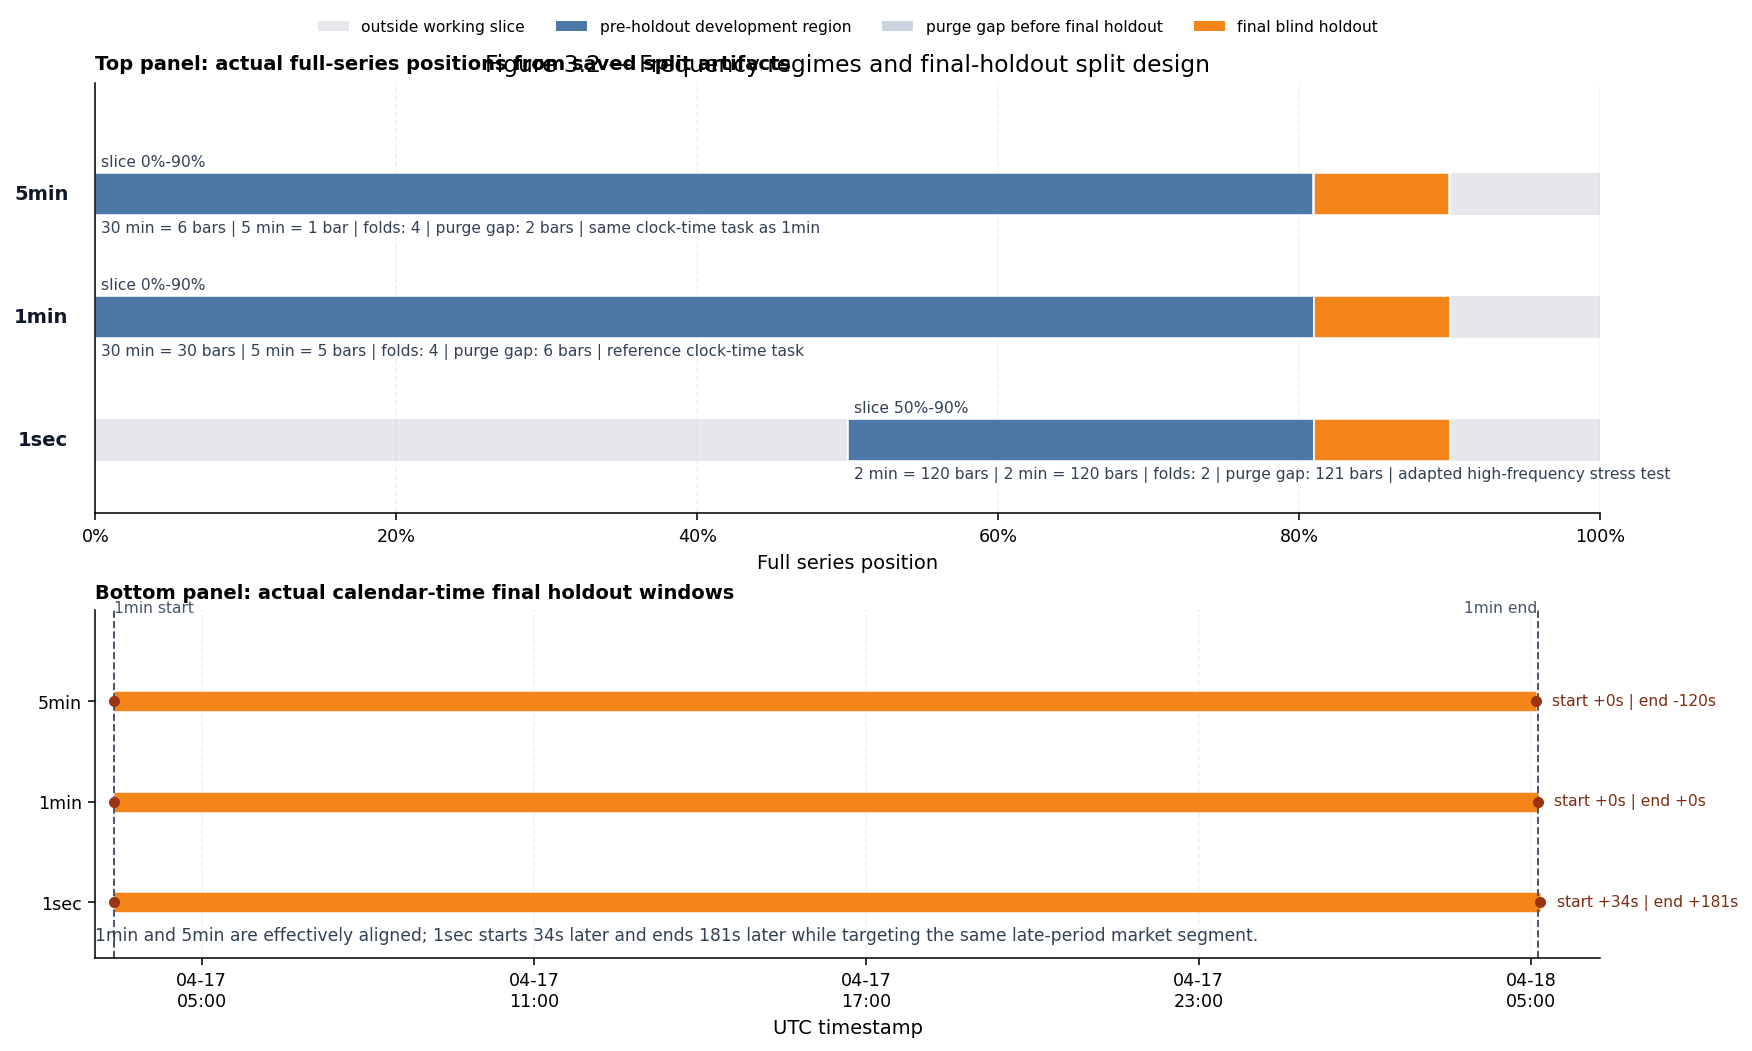

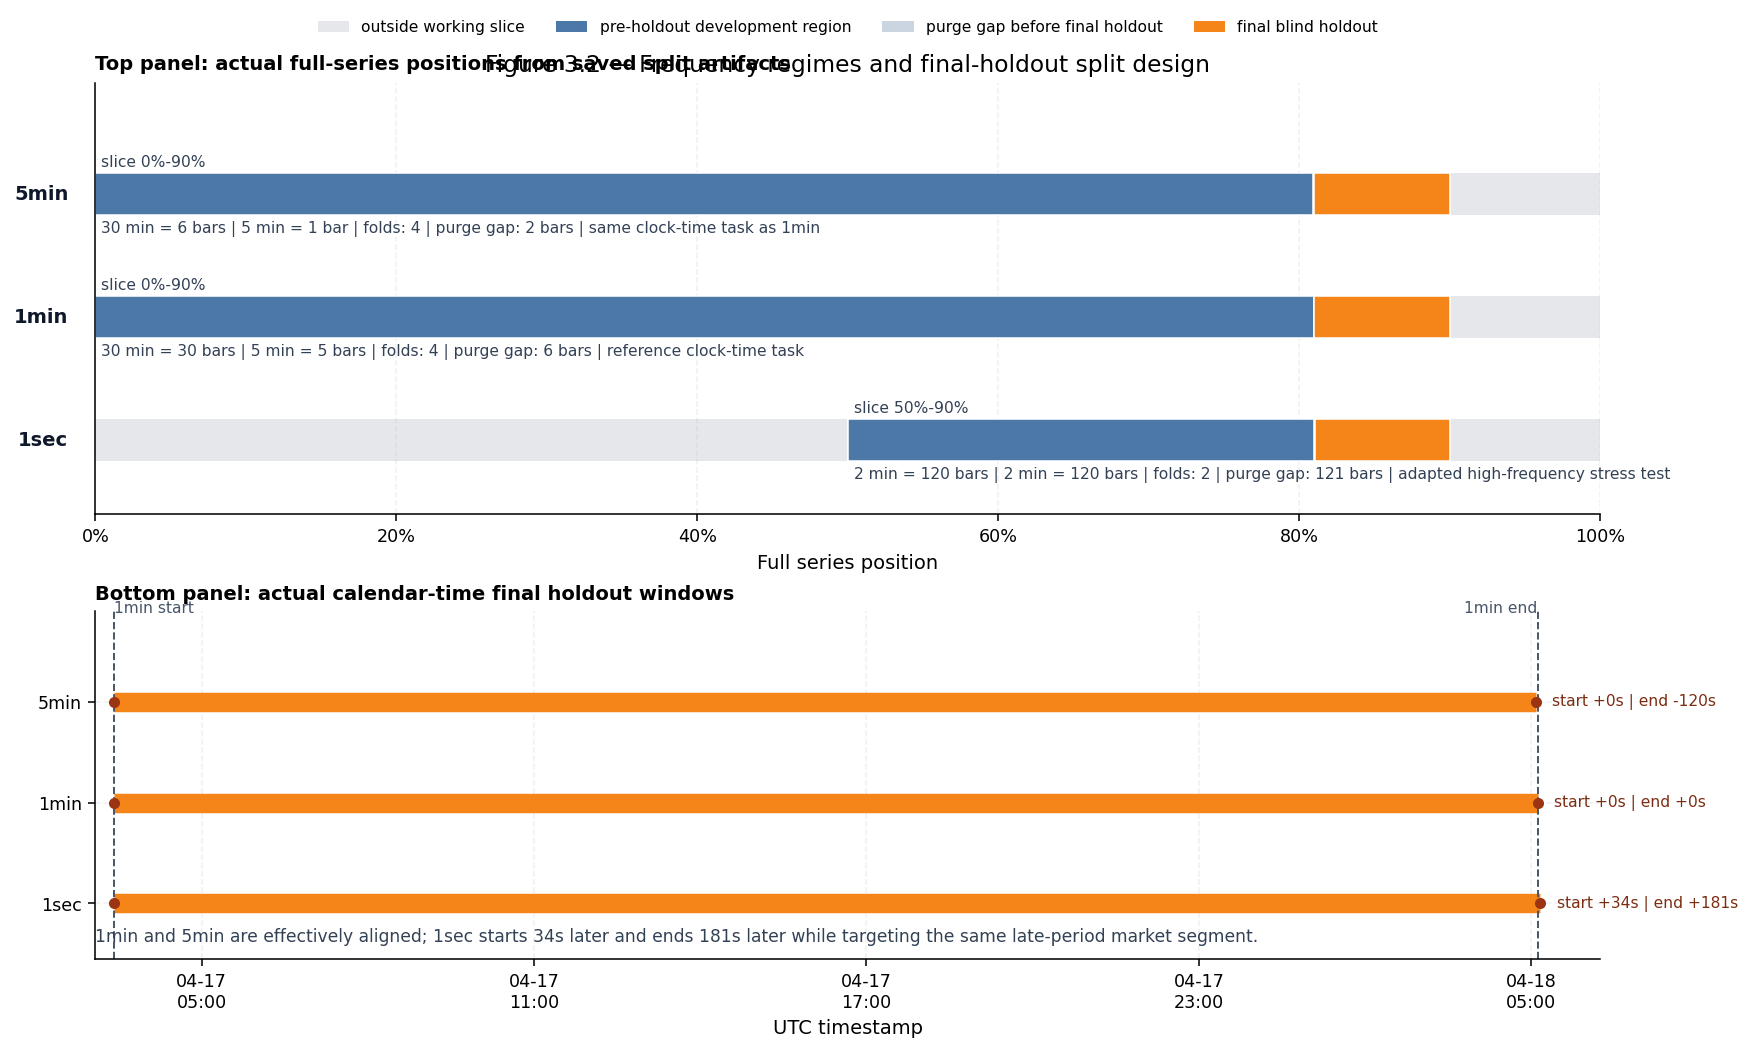

In [80]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12.4, 7.4),
    constrained_layout=True,
    height_ratios=[1.3, 1.05],
)

ax = axes[0]
y_positions = np.arange(len(regime_df))[::-1]
bar_height = 0.34

for y, row in zip(y_positions, regime_df.to_dict("records")):
    ax.add_patch(Rectangle((0.0, y - bar_height / 2), 1.0, bar_height, facecolor=regime_colors["outside"], edgecolor="none", zorder=0))
    ax.add_patch(Rectangle((row["work_start"], y - bar_height / 2), row["work_end"] - row["work_start"], bar_height, facecolor=regime_colors["working"], edgecolor="white", linewidth=0.9, zorder=1))
    ax.add_patch(Rectangle((row["work_start"], y - bar_height / 2), row["preholdout_end_full_frac"] - row["work_start"], bar_height, facecolor=regime_colors["preholdout"], edgecolor="white", linewidth=0.8, zorder=2))
    ax.add_patch(Rectangle((row["preholdout_end_full_frac"], y - bar_height / 2), row["holdout_start_full_frac"] - row["preholdout_end_full_frac"], bar_height, facecolor=regime_colors["purge_gap"], edgecolor="white", linewidth=0.6, hatch="///", zorder=3))
    ax.add_patch(Rectangle((row["holdout_start_full_frac"], y - bar_height / 2), row["holdout_end_full_frac"] - row["holdout_start_full_frac"], bar_height, facecolor=regime_colors["holdout"], edgecolor="white", linewidth=0.8, zorder=4))
    ax.text(-0.018, y, row["frequency"], va="center", ha="right", fontweight="bold", fontsize=10, color="#0f172a")
    ax.text(row["work_start"] + 0.004, y + 0.26, f"slice {row['work_start']:.0%}-{row['work_end']:.0%}", fontsize=8, ha="left", va="center", color="#334155")
    ax.text(row["holdout_start_full_frac"] + 0.004, y, f"holdout\n{row['holdout_frac_of_slice']:.1%} of slice", va="center", ha="left", fontsize=7.8, color="#7c2d12")
    ax.text(row["work_start"] + 0.004, y - 0.28, f"{row['lookback']} | {row['horizon']} | folds: {row['cv_folds']} | purge gap: {row['purge_gap_bars']} bars | {row['task_note']}", fontsize=8, ha="left", va="center", color="#334155")

legend_handles = [
    Rectangle((0, 0), 1, 1, facecolor=regime_colors["outside"], edgecolor="none", label="outside working slice"),
    Rectangle((0, 0), 1, 1, facecolor=regime_colors["preholdout"], edgecolor="none", label="pre-holdout development region"),
    Rectangle((0, 0), 1, 1, facecolor=regime_colors["purge_gap"], edgecolor="none", hatch="///", label="purge gap before final holdout"),
    Rectangle((0, 0), 1, 1, facecolor=regime_colors["holdout"], edgecolor="none", label="final blind holdout"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=4, frameon=False, fontsize=8)
ax.set_xlim(0, 1.0)
ax.set_ylim(-0.6, len(regime_df) - 0.1)
ax.set_yticks([])
ax.set_xticks(np.linspace(0, 1, 6))
ax.set_xticklabels([f"{int(x * 100)}%" for x in np.linspace(0, 1, 6)])
ax.set_xlabel("Full series position")
ax.set_title("Figure 3.2 — Frequency regimes and final-holdout split design")
ax.text(0.0, len(regime_df) - 0.02, "Top panel: actual full-series positions from saved split artifacts", ha="left", va="bottom", fontsize=10, fontweight="bold")

ax2 = axes[1]
mdates = plt.matplotlib.dates
holdout_rows = regime_df.copy()
holdout_rows["holdout_start_ts"] = pd.to_datetime(holdout_rows["holdout_start_utc"], utc=True)
holdout_rows["holdout_end_ts"] = pd.to_datetime(holdout_rows["holdout_end_utc"], utc=True)
reference_row = holdout_rows.loc[holdout_rows["frequency"] == "1min"].iloc[0]
ref_start = reference_row["holdout_start_ts"]
ref_end = reference_row["holdout_end_ts"]

for y, row in zip(y_positions, holdout_rows.to_dict("records")):
    start_ts = pd.Timestamp(row["holdout_start_ts"])
    end_ts = pd.Timestamp(row["holdout_end_ts"])
    ax2.plot([start_ts, end_ts], [y, y], color=regime_colors["holdout"], linewidth=10, solid_capstyle="butt")
    ax2.scatter([start_ts, end_ts], [y, y], s=22, color="#9a3412", zorder=3)
    delta_label = f"start {row['start_delta_vs_1min_sec']:+d}s | end {row['end_delta_vs_1min_sec']:+d}s"
    ax2.text(end_ts + pd.Timedelta(minutes=18), y, delta_label, va="center", ha="left", fontsize=8, color="#7c2d12")

ax2.axvline(ref_start, color="#475569", linestyle="--", linewidth=1.0)
ax2.axvline(ref_end, color="#475569", linestyle="--", linewidth=1.0)
ax2.text(ref_start, len(holdout_rows) - 0.15, "1min start", ha="left", va="bottom", fontsize=8, color="#475569")
ax2.text(ref_end, len(holdout_rows) - 0.15, "1min end", ha="right", va="bottom", fontsize=8, color="#475569")

xmin = holdout_rows["holdout_start_ts"].min() - pd.Timedelta(minutes=20)
xmax = holdout_rows["holdout_end_ts"].max() + pd.Timedelta(minutes=65)
ax2.set_xlim(xmin, xmax)
ax2.set_ylim(-0.55, len(holdout_rows) - 0.1)
ax2.set_yticks(y_positions)
ax2.set_yticklabels(holdout_rows["frequency"])
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=6, tz=holdout_rows["holdout_start_ts"].iloc[0].tz))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M", tz=holdout_rows["holdout_start_ts"].iloc[0].tz))
ax2.set_title("Bottom panel: actual calendar-time final holdout windows", loc="left", fontsize=10, fontweight="bold")
ax2.set_xlabel("UTC timestamp")
ax2.text(mdates.date2num(xmin), -0.42, "1min and 5min are effectively aligned; 1sec starts 34s later and ends 181s later while targeting the same late-period market segment.", ha="left", va="bottom", fontsize=8.8, color="#334155")

fig


In [81]:
fig_3_2_path = save_thesis_figure(
    fig,
    figure_id="3.2",
    filename_stem="fig_3_2_split_design_v2",
    title="Frequency regimes and final-holdout split design",
    source_artifacts=['paper_artifacts/final_holdout_alignment_table.csv', 'final_runs/*/splits/split_summary.json'],
    rendering_method="Python, artifact-grounded",
    main_text_section="Chapter 3",
    validation_checks="Frequency regimes and aligned final-holdout intervals are artifact-grounded.",
)
fig_3_2_path


PosixPath('/Users/vitalii/Desktop/Model_Market_Microstructure/GNN_for_LOB/paper_artifacts/figures_generated/fig_3_2_split_design_v2.png')

## Figure 3.3 — Triple-barrier target construction for the ETH midpoint

**Why this format**
- Hybrid is best because the core path/barrier visualization can be built in Python, but the explanatory annotations need tight manual control.

**Metadata**
- Figure type: `hybrid`
- Evidence source: `mixed`
- Rendering method: `Python-primary`
- Primary inputs: `../Graph_Neural_Network_for_Market_Microstructure/dataset/ETH_1min.csv`, `../Graph_Neural_Network_for_Market_Microstructure/dataset/ETH_5min.csv`, `train_config.yaml`, `co_om_thesis_enhanced.md`
- Acceptance check: target timestamp, upper/lower/vertical barriers, realized exit, realized return, trade relevance, direction label, reproducible timestamp selection rule


**Generation body**
- Select one reproducible example timestamp with a clear barrier hit.
- Plot midpoint path after target time.
- Draw upper/lower/vertical barriers.
- Add labels for realized exit, realized return, trade label, direction label.

**Planned future code cells**
1. load ETH data and benchmark parameters
2. choose representative timestamp
3. render barrier figure
4. export figure
5. manual polish notes


In [82]:
triple_barrier_config = {
    "freq": "1min",
    "lookback_bars": 30,
    "horizon_bars": int(5),
    "upper_barrier_bps": 8.0,
    "lower_barrier_bps": 8.0,
    "vol_lookback_bars": 30,
    "vol_barrier_mult_up": 1.8,
    "vol_barrier_mult_down": 1.8,
    "min_barrier_bps": 4.0,
    "max_barrier_bps": 30.0,
    "trade_label_buffer_bps": 0.5,
    "cost_bps_per_side": 1.0,
    "execution_cost_multiplier": 1.0,
    "use_cost_in_label": True,
}

eth_1min_df = pd.read_csv(REPO_ROOT / "../Graph_Neural_Network_for_Market_Microstructure/dataset/ETH_1min.csv")
eth_1min_df["system_time"] = pd.to_datetime(eth_1min_df["system_time"])
eth_mid = eth_1min_df["midpoint"].to_numpy(dtype=float)
eth_log_mid = np.log(eth_mid + 1e-12)
eth_lr_1bar = np.zeros(len(eth_mid), dtype=float)
eth_lr_1bar[1:] = np.diff(eth_log_mid)


In [83]:
trade_edge_threshold = (
    triple_barrier_config["trade_label_buffer_bps"] * 1e-4
    + (3.0 * triple_barrier_config["cost_bps_per_side"] * 1e-4) * triple_barrier_config["execution_cost_multiplier"]
)

rolling_vol = pd.Series(eth_lr_1bar).rolling(
    window=triple_barrier_config["vol_lookback_bars"],
    min_periods=max(3, triple_barrier_config["vol_lookback_bars"] // 3),
).std().to_numpy(dtype=float)
vol_bps = np.abs(rolling_vol) * 1e4
upper_bps = np.clip(
    vol_bps * triple_barrier_config["vol_barrier_mult_up"],
    triple_barrier_config["min_barrier_bps"],
    triple_barrier_config["max_barrier_bps"],
)
lower_bps = np.clip(
    vol_bps * triple_barrier_config["vol_barrier_mult_down"],
    triple_barrier_config["min_barrier_bps"],
    triple_barrier_config["max_barrier_bps"],
)
upper_bps = np.where(np.isfinite(upper_bps), upper_bps, triple_barrier_config["upper_barrier_bps"])
lower_bps = np.where(np.isfinite(lower_bps), lower_bps, triple_barrier_config["lower_barrier_bps"])


In [84]:
triple_barrier_candidates = []
for t in range(triple_barrier_config["lookback_bars"], len(eth_mid) - triple_barrier_config["horizon_bars"] - 1):
    upper_lr = max(float(upper_bps[t]) * 1e-4, 1e-8)
    lower_lr = max(float(lower_bps[t]) * 1e-4, 1e-8)
    future_path = eth_log_mid[t + 1 : t + triple_barrier_config["horizon_bars"] + 1] - eth_log_mid[t]
    if len(future_path) == 0 or not np.isfinite(future_path).all():
        continue

    upper_hits = np.where(future_path >= upper_lr - 1e-12)[0]
    lower_hits = np.where(future_path <= -lower_lr + 1e-12)[0]
    first_upper = int(upper_hits[0]) + 1 if upper_hits.size else None
    first_lower = int(lower_hits[0]) + 1 if lower_hits.size else None

    if first_upper is not None and (first_lower is None or first_upper <= first_lower):
        exit_type = "upper"
        tte = first_upper
        realized_return = upper_lr
        direction_label = "long"
        trade_label = 1.0 if upper_lr > trade_edge_threshold else 0.0
    elif first_lower is not None and (first_upper is None or first_lower < first_upper):
        exit_type = "lower"
        tte = first_lower
        realized_return = -lower_lr
        direction_label = "short"
        trade_label = 1.0 if lower_lr > trade_edge_threshold else 0.0
    else:
        exit_type = "vertical"
        tte = triple_barrier_config["horizon_bars"]
        realized_return = float(future_path[-1])
        direction_label = "long" if realized_return > 0 else "short"
        trade_label = 0.0

    if trade_label > 0.5 and exit_type in {"upper", "lower"}:
        score = abs(tte - max(2, triple_barrier_config["horizon_bars"] // 2)) + 0.1 * abs(abs(realized_return) - trade_edge_threshold)
        triple_barrier_candidates.append((score, t, exit_type, tte, realized_return, direction_label, upper_lr, lower_lr))

_, target_idx, exit_type, tte, realized_return, direction_label, upper_lr, lower_lr = sorted(triple_barrier_candidates, key=lambda x: x[0])[0]
base_midpoint = eth_mid[target_idx]
path_prices = eth_mid[target_idx : target_idx + triple_barrier_config["horizon_bars"] + 1]
time_axis = np.arange(0, triple_barrier_config["horizon_bars"] + 1)
upper_price = base_midpoint * np.exp(upper_lr)
lower_price = base_midpoint * np.exp(-lower_lr)
exit_price = upper_price if exit_type == "upper" else lower_price if exit_type == "lower" else path_prices[-1]
eth_1min_df.loc[[target_idx], ["system_time", "midpoint"]]


,system_time,midpoint
3476,2021-04-09 21:43:00.015407+00:00,2079.045


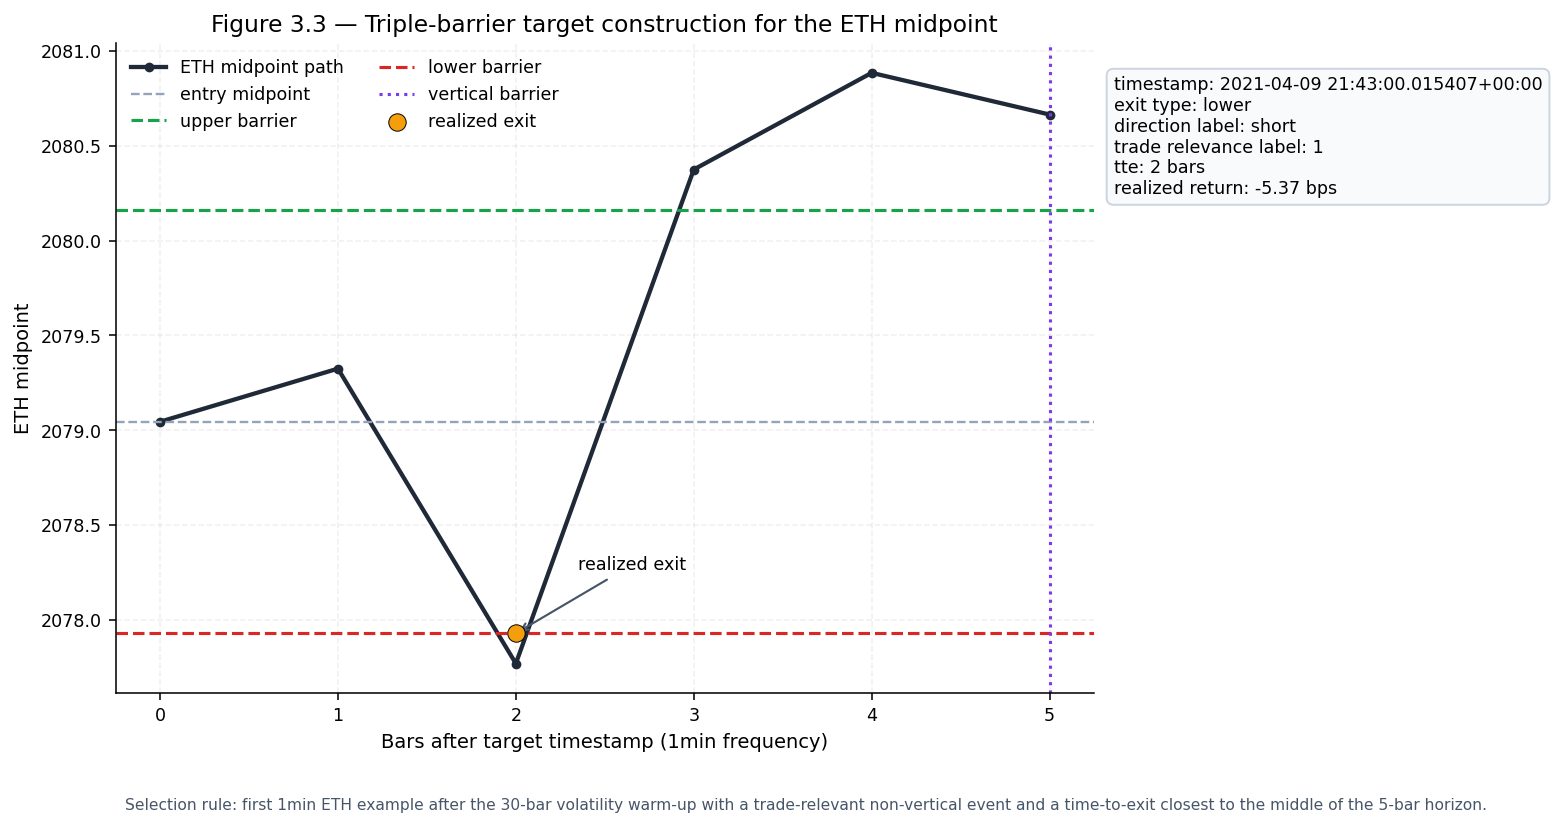

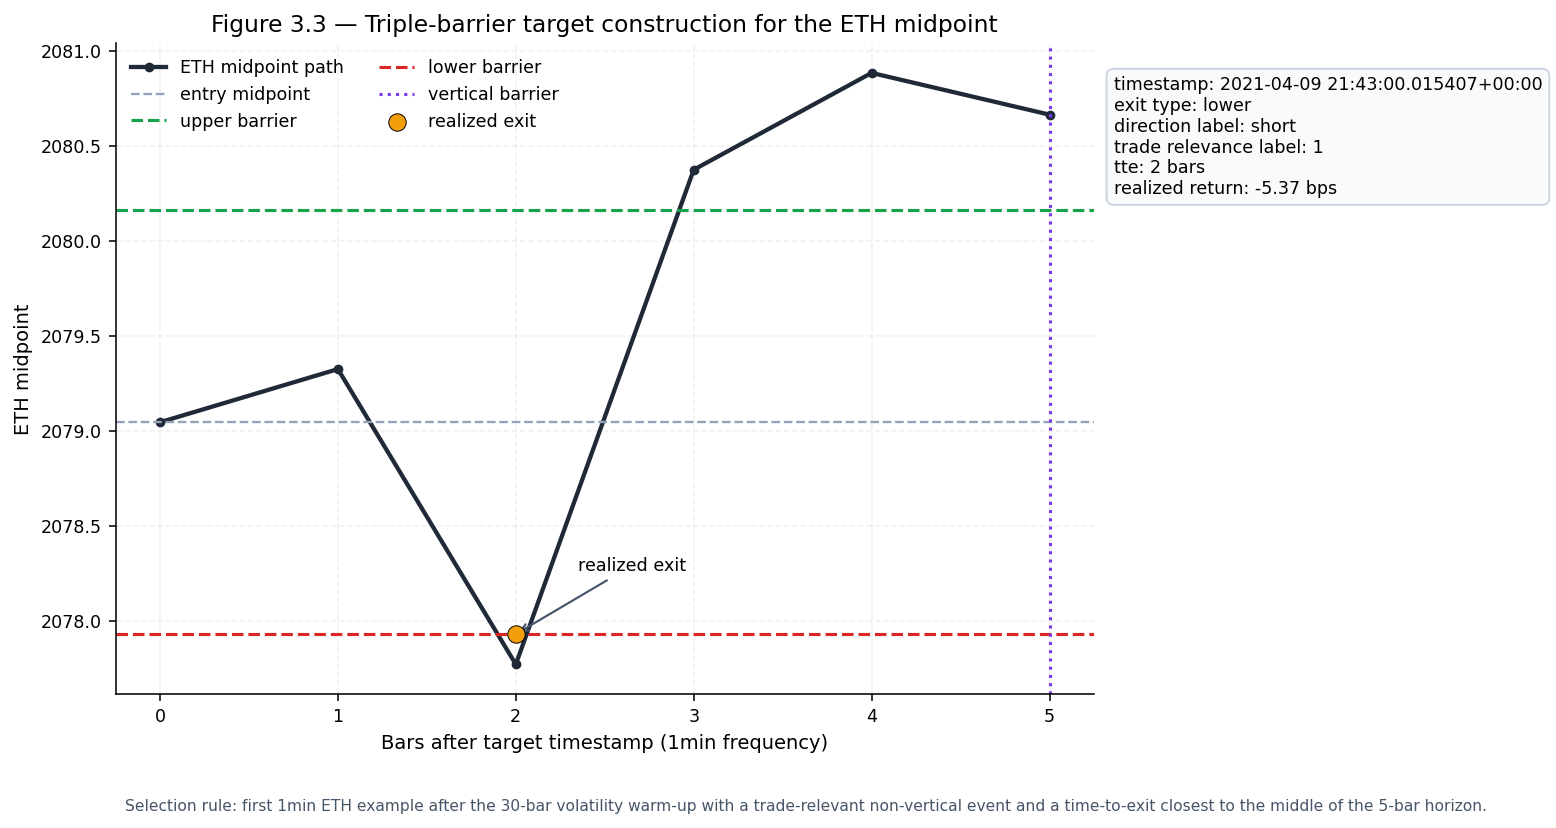

In [85]:
fig, ax = plt.subplots(figsize=(11, 5.8), constrained_layout=True)
ax.plot(time_axis, path_prices, color="#1f2937", linewidth=2.2, marker="o", markersize=4, label="ETH midpoint path")
ax.axhline(base_midpoint, color="#94a3b8", linewidth=1.2, linestyle="--", label="entry midpoint")
ax.axhline(upper_price, color="#16a34a", linewidth=1.6, linestyle="--", label="upper barrier")
ax.axhline(lower_price, color="#dc2626", linewidth=1.6, linestyle="--", label="lower barrier")
ax.axvline(triple_barrier_config["horizon_bars"], color="#7c3aed", linewidth=1.6, linestyle=":", label="vertical barrier")
ax.scatter([tte], [exit_price], color="#f59e0b", s=80, zorder=5, edgecolor="black", linewidth=0.5, label="realized exit")
ax.annotate("realized exit", xy=(tte, exit_price), xytext=(tte + 0.35, exit_price + (upper_price - lower_price) * 0.15), arrowprops=dict(arrowstyle="->", lw=1.1, color="#475569"), fontsize=9)
ax.set_title("Figure 3.3 — Triple-barrier target construction for the ETH midpoint")
ax.set_xlabel("Bars after target timestamp (1min frequency)")
ax.set_ylabel("ETH midpoint")
ax.legend(loc="upper left", frameon=False, ncol=2)

info_text = (
    f"timestamp: {eth_1min_df.loc[target_idx, 'system_time']}\n"
    f"exit type: {exit_type}\n"
    f"direction label: {direction_label}\n"
    f"trade relevance label: 1\n"
    f"tte: {tte} bars\n"
    f"realized return: {realized_return * 1e4:.2f} bps"
)
ax.text(1.02, 0.95, info_text, transform=ax.transAxes, va="top", fontsize=9, bbox=dict(boxstyle="round,pad=0.4", facecolor="#f8fafc", edgecolor="#cbd5e1"))
ax.text(0.01, -0.18, "Selection rule: first 1min ETH example after the 30-bar volatility warm-up with a trade-relevant non-vertical event and a time-to-exit closest to the middle of the 5-bar horizon.", transform=ax.transAxes, fontsize=8, color="#475569")
fig


In [86]:
fig_3_3_path = save_thesis_figure(
    fig,
    figure_id="3.3",
    filename_stem="fig_3_3_triple_barrier_eth_midpoint",
    title="Triple-barrier target construction for the ETH midpoint",
    source_artifacts=['../Graph_Neural_Network_for_Market_Microstructure/dataset/ETH_1min.csv', 'final_runs/1min-base-gnn-conv/resolved_config.yaml'],
    rendering_method="Python-primary hybrid",
    main_text_section="Chapter 3",
    validation_checks="Upper/lower/vertical barriers and realized event exit are visible.",
)
fig_3_3_path


PosixPath('/Users/vitalii/Desktop/Model_Market_Microstructure/GNN_for_LOB/paper_artifacts/figures_generated/fig_3_3_triple_barrier_eth_midpoint.png')

## Figure 3.4 — Common entry-model backtest and post-cost PnL calculation

**Why this format**
- Hybrid fits best because the figure is a conceptual evaluation pipeline with formulas, not a raw empirical plot.

**Metadata**
- Figure type: `hybrid`
- Evidence source: `mixed`
- Rendering method: `Prompt-first hybrid`
- Primary inputs: `co_om_thesis_enhanced.md`, `train_config.yaml`
- Acceptance check: trade activation, direction choice, realized event exit, gross→net PnL with cost proxy


**Generation body — final image prompt**

```text
Create a clean academic flowchart for a quantitative finance thesis.

Title: "Common entry-model backtest and post-cost PnL calculation"

Flow structure:
1. model outputs with trade head and direction head
2. decision block
3. event-based holding block
4. gross PnL block
5. cost adjustment block
6. final net PnL output block

Semantic constraint:
This is a controlled benchmark backtest illustration, not a full execution simulator.
```


In [87]:
backtest_pipeline_blocks = [
    {"title": "Model outputs", "body": "trade head score\ndirection head score", "color": THESIS_COLORS["light_blue"]},
    {"title": "Entry gate", "body": "open only if\ntrade score ≥ threshold", "color": THESIS_COLORS["light_teal"]},
    {"title": "Side choice", "body": "long if direction up\nshort if direction down", "color": THESIS_COLORS["light_teal"]},
    {"title": "Realized event exit", "body": "upper / lower / vertical\nnon-overlapping hold", "color": THESIS_COLORS["light_slate"]},
    {"title": "Gross PnL", "body": "side × realized return", "color": THESIS_COLORS["light_blue"]},
    {"title": "Cost adjustment", "body": "subtract round-trip\ntransaction-cost proxy", "color": THESIS_COLORS["light_orange"]},
    {"title": "Net PnL", "body": "post-cost final-holdout\nbenchmark output", "color": THESIS_COLORS["light_teal"]},
]

backtest_pipeline_blocks


[{'title': 'Model outputs',
  'body': 'trade head score\ndirection head score',
  'color': '#e8f1fb'},
 {'title': 'Entry gate',
  'body': 'open only if\ntrade score ≥ threshold',
  'color': '#e5f4f1'},
 {'title': 'Side choice',
  'body': 'long if direction up\nshort if direction down',
  'color': '#e5f4f1'},
 {'title': 'Realized event exit',
  'body': 'upper / lower / vertical\nnon-overlapping hold',
  'color': '#f1f5f9'},
 {'title': 'Gross PnL', 'body': 'side × realized return', 'color': '#e8f1fb'},
 {'title': 'Cost adjustment',
  'body': 'subtract round-trip\ntransaction-cost proxy',
  'color': '#fff0df'},
 {'title': 'Net PnL',
  'body': 'post-cost final-holdout\nbenchmark output',
  'color': '#e5f4f1'}]

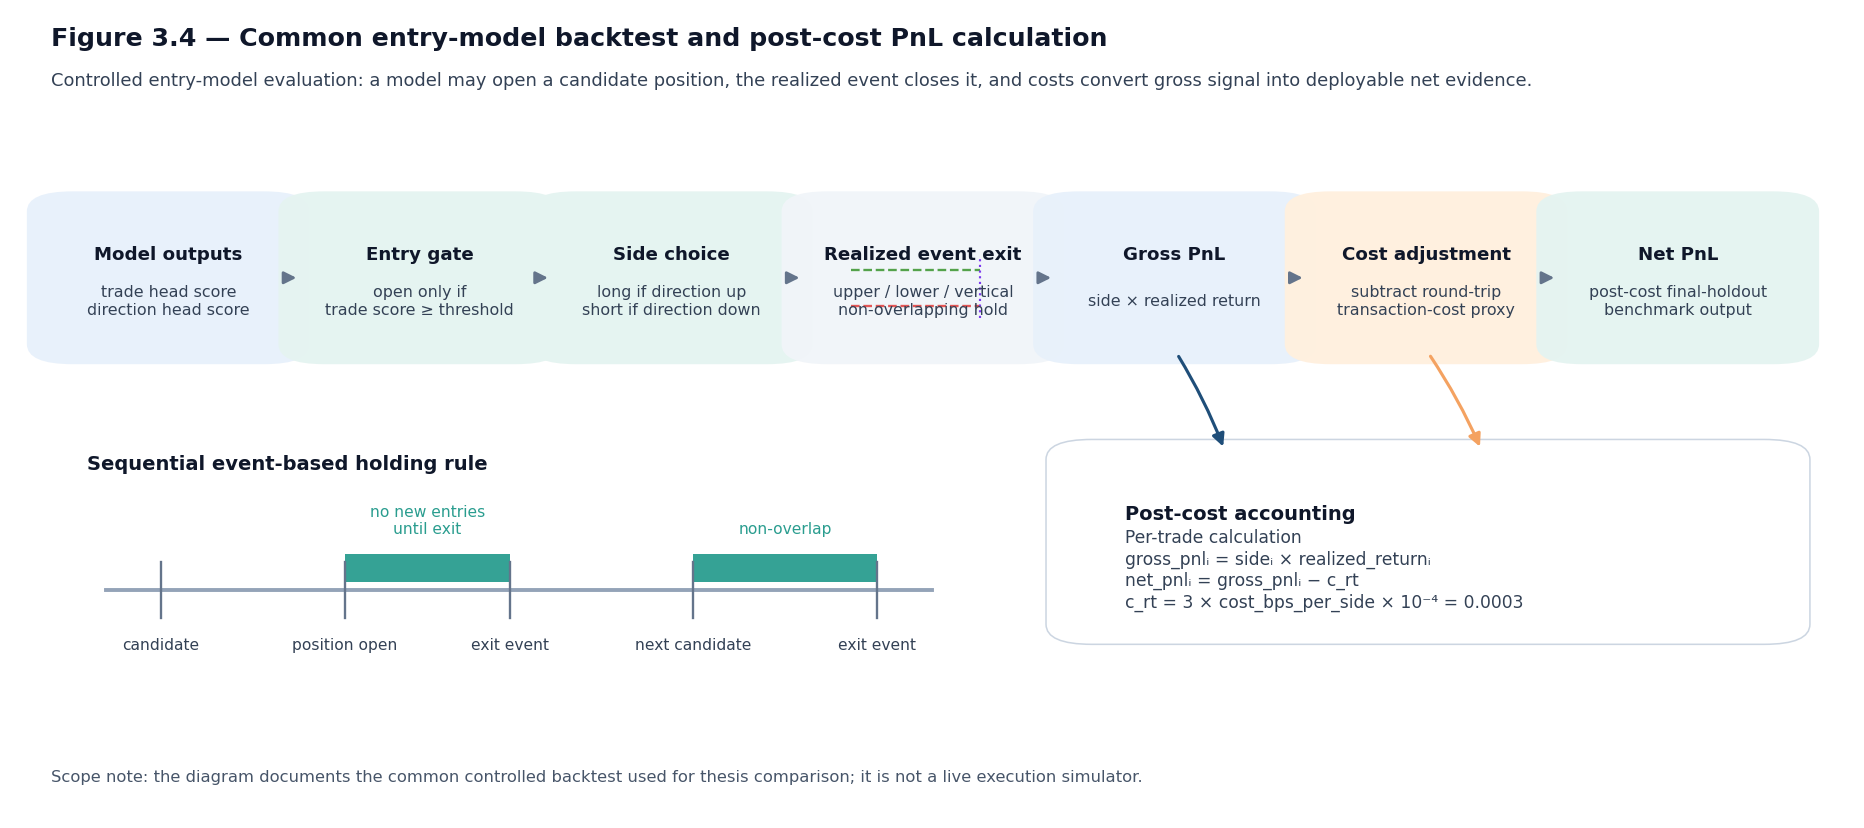

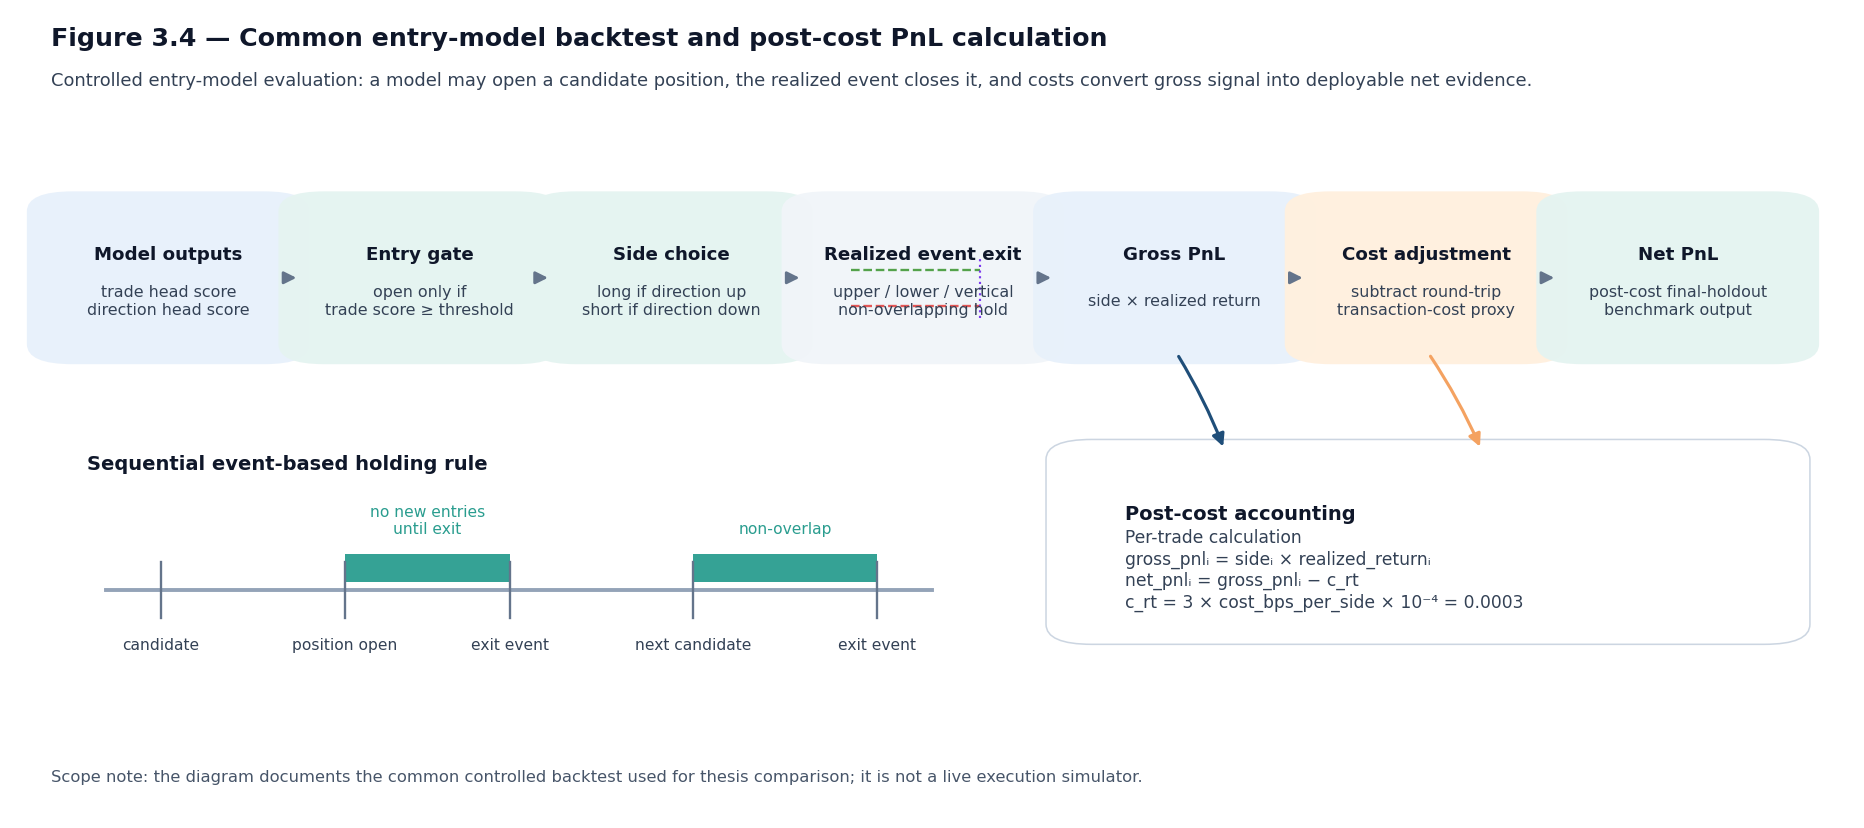

In [88]:
fig, ax = plt.subplots(figsize=(13.2, 5.8), constrained_layout=True)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(0.02, 0.96, "Figure 3.4 — Common entry-model backtest and post-cost PnL calculation", fontsize=13, fontweight="bold", ha="left", color=THESIS_COLORS["ink"])
ax.text(
    0.02,
    0.91,
    "Controlled entry-model evaluation: a model may open a candidate position, the realized event closes it, and costs convert gross signal into deployable net evidence.",
    fontsize=9.2,
    color="#334155",
    ha="left",
)

x0, y0, w, h, gap = 0.025, 0.58, 0.118, 0.18, 0.019
centers = []
for i, block in enumerate(backtest_pipeline_blocks):
    x = x0 + i * (w + gap)
    thesis_box(ax, (x, y0), w, h, block["title"], block["body"], facecolor=block["color"], title_size=9.4, fontsize=8.2)
    centers.append((x + w / 2, y0 + h / 2))
    if i > 0:
        thesis_arrow(ax, (x - gap + 0.002, y0 + h / 2), (x - 0.004, y0 + h / 2), lw=1.45)

formula_text = (
    "Per-trade calculation\n"
    "gross_pnlᵢ = sideᵢ × realized_returnᵢ\n"
    "net_pnlᵢ = gross_pnlᵢ − c_rt\n"
    "c_rt = 3 × cost_bps_per_side × 10⁻⁴ = 0.0003"
)
thesis_box(
    ax,
    (0.58, 0.23),
    0.38,
    0.22,
    "Post-cost accounting",
    formula_text,
    facecolor="#ffffff",
    edgecolor="#cbd5e1",
    align="left",
    title_size=10,
    fontsize=8.8,
)
thesis_arrow(ax, (centers[4][0], y0), (0.66, 0.45), color=THESIS_COLORS["navy"], rad=-0.05)
thesis_arrow(ax, (centers[5][0], y0), (0.80, 0.45), color=THESIS_COLORS["orange"], rad=-0.05)

ax.text(0.04, 0.43, "Sequential event-based holding rule", fontsize=10, fontweight="bold", ha="left", color=THESIS_COLORS["ink"])
ax.plot([0.05, 0.50], [0.28, 0.28], color="#94a3b8", linewidth=2)
events = [0.08, 0.18, 0.27, 0.37, 0.47]
labels = ["candidate", "position open", "exit event", "next candidate", "exit event"]
for x, label in zip(events, labels):
    ax.plot([x, x], [0.245, 0.315], color=THESIS_COLORS["slate"], linewidth=1.2)
    ax.text(x, 0.22, label, ha="center", va="top", fontsize=8, color="#334155")
ax.add_patch(Rectangle((0.18, 0.29), 0.09, 0.035, facecolor=THESIS_COLORS["teal"], edgecolor="none", alpha=0.95))
ax.add_patch(Rectangle((0.37, 0.29), 0.10, 0.035, facecolor=THESIS_COLORS["teal"], edgecolor="none", alpha=0.95))
ax.text(0.225, 0.35, "no new entries\nuntil exit", ha="center", fontsize=8, color=THESIS_COLORS["teal"])
ax.text(0.42, 0.35, "non-overlap", ha="center", fontsize=8, color=THESIS_COLORS["teal"])

mini_x, mini_y = x0 + 3 * (w + gap) + 0.02, y0 + 0.04
ax.plot([mini_x, mini_x + 0.07], [mini_y + 0.06, mini_y + 0.06], color=THESIS_COLORS["green"], lw=1.2, linestyle="--")
ax.plot([mini_x, mini_x + 0.07], [mini_y + 0.015, mini_y + 0.015], color=THESIS_COLORS["red"], lw=1.2, linestyle="--")
ax.plot([mini_x + 0.07, mini_x + 0.07], [mini_y, mini_y + 0.075], color=THESIS_COLORS["purple"], lw=1.1, linestyle=":")

ax.text(
    0.02,
    0.04,
    "Scope note: the diagram documents the common controlled backtest used for thesis comparison; it is not a live execution simulator.",
    fontsize=8.4,
    color="#475569",
    ha="left",
)
fig


In [89]:
fig_3_4_path = save_thesis_figure(
    fig,
    figure_id="3.4",
    filename_stem="fig_3_4_entry_backtest_post_cost_pnl",
    title="Common entry-model backtest and post-cost PnL calculation",
    source_artifacts=['train.py', 'final_runs/*/final_report.csv'],
    rendering_method="Python vector",
    main_text_section="Chapter 3",
    validation_checks="Common entry policy, realized event exit, and shared cost proxy are shown.",
)
fig_3_4_path


PosixPath('/Users/vitalii/Desktop/Model_Market_Microstructure/GNN_for_LOB/paper_artifacts/figures_generated/fig_3_4_entry_backtest_post_cost_pnl.png')

## Figure 3.5 — Purged walk-forward validation and deployment-oriented model states

**Why this format**
- Python is the strongest choice because both chronology and model-state comparison can be anchored to split artifacts and reported states.

**Metadata**
- Figure type: `executable`
- Evidence source: `artifact-grounded`
- Rendering method: `Python`
- Primary inputs: split summaries for `5min`, `1min`, `1sec`, plus thesis semantics
- Acceptance check: train/purge/validation/purge/test, chronological order, separate final holdout, visible `best_CV`, `last_CV`, `final_refit`


**Generation body**
- Draw fold chronology explicitly.
- Add a second annotation layer showing how each model state is obtained.
- Keep it distinct from Figure 3.2 by focusing on fold mechanics.

**Planned future code cells**
1. load split summaries and state semantics
2. build fold chronology representation
3. render validation/model-state diagram
4. export figure


In [90]:
walkforward_summary = load_split_summary("1min")
preholdout = walkforward_summary["preholdout"]
holdout = walkforward_summary["holdout"]
cv_folds = walkforward_summary["cv_folds"]
last_fold = cv_folds[-1]

full_total = preholdout["n_samples"] + holdout["n_samples"]
preholdout_fraction = preholdout["n_samples"] / full_total
holdout_fraction = holdout["n_samples"] / full_total


In [91]:
train_n = last_fold["train"]["n_samples"]
validation_n = last_fold["val"]["n_samples"]
test_n = last_fold["test"]["n_samples"]
purge_gap = walkforward_summary["purge_gap_bars"]
fold_total = train_n + validation_n + test_n + 2 * purge_gap

fold_segments = [
    ("train", train_n / fold_total, "#4c78a8"),
    ("purge", purge_gap / fold_total, "#cbd5e1"),
    ("validation", validation_n / fold_total, "#72b7b2"),
    ("purge", purge_gap / fold_total, "#cbd5e1"),
    ("test", test_n / fold_total, "#54a24b"),
]


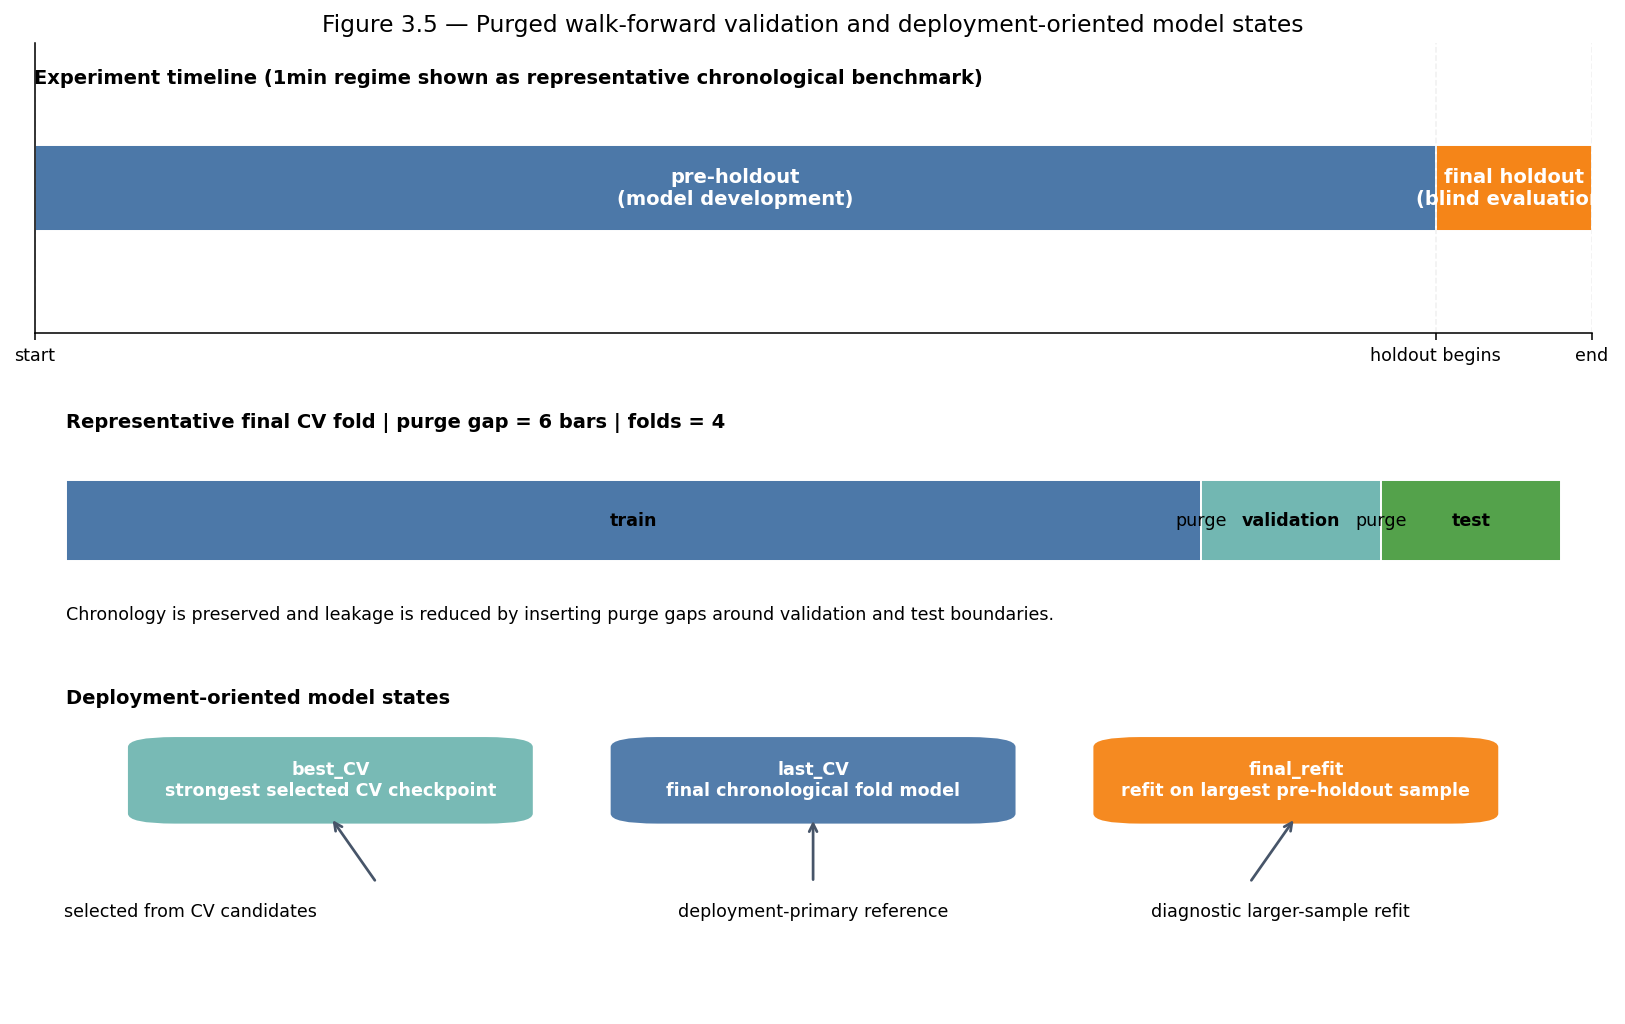

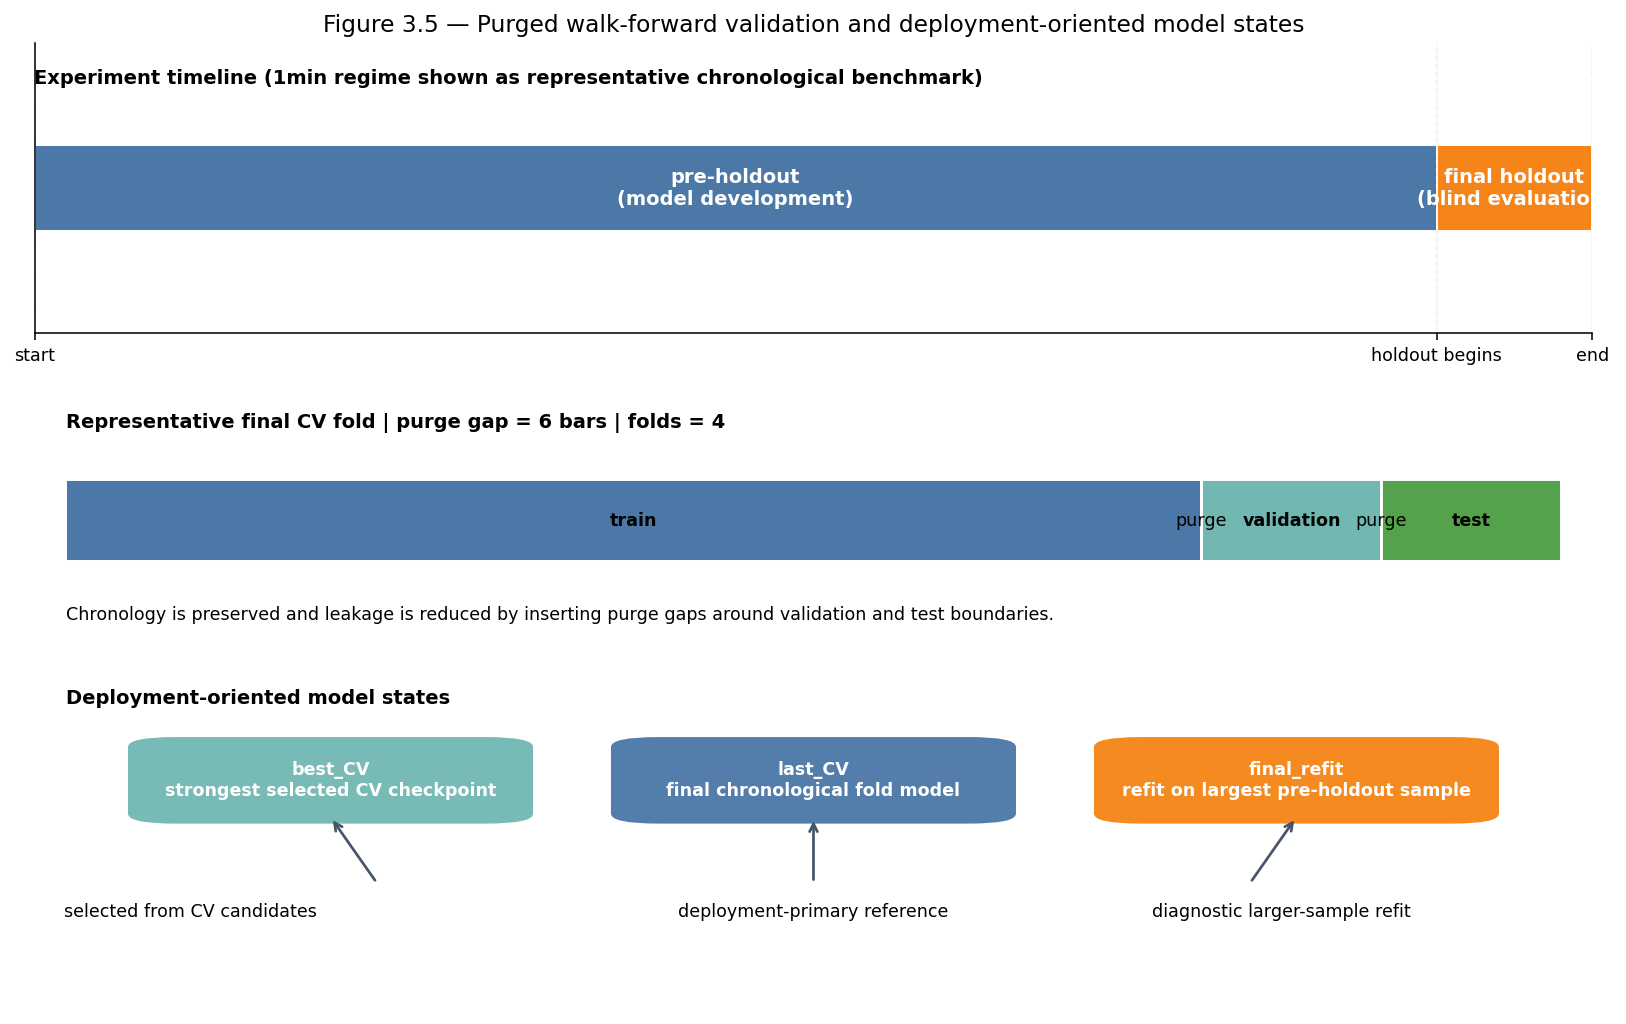

In [92]:
fig = plt.figure(figsize=(11.5, 7.2), constrained_layout=True)
grid = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1.15])
ax1 = fig.add_subplot(grid[0])
ax2 = fig.add_subplot(grid[1])
ax3 = fig.add_subplot(grid[2])

# top panel: global experiment timeline
ax1.add_patch(Rectangle((0, 0.35), preholdout_fraction, 0.3, facecolor="#4c78a8", edgecolor="white"))
ax1.add_patch(Rectangle((preholdout_fraction, 0.35), holdout_fraction, 0.3, facecolor="#f58518", edgecolor="white"))
ax1.text(preholdout_fraction / 2, 0.5, "pre-holdout\n(model development)", ha="center", va="center", color="white", fontweight="bold")
ax1.text(preholdout_fraction + holdout_fraction / 2, 0.5, "final holdout\n(blind evaluation)", ha="center", va="center", color="white", fontweight="bold")
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_yticks([])
ax1.set_xticks([0, preholdout_fraction, 1.0])
ax1.set_xticklabels(["start", "holdout begins", "end"])
ax1.set_title("Figure 3.5 — Purged walk-forward validation and deployment-oriented model states")
ax1.text(0.0, 0.86, "Experiment timeline (1min regime shown as representative chronological benchmark)", fontsize=10, fontweight="bold", ha="left")

# middle panel: representative final CV fold
ax2.axis("off")
current_x = 0.02
for label, width, color in fold_segments:
    scaled_width = width * 0.96
    ax2.add_patch(Rectangle((current_x, 0.36), scaled_width, 0.28, facecolor=color, edgecolor="white"))
    ax2.text(current_x + scaled_width / 2, 0.5, label, ha="center", va="center", fontsize=9, fontweight="bold" if label in {"train", "validation", "test"} else None)
    current_x += scaled_width
ax2.text(0.02, 0.82, f"Representative final CV fold | purge gap = {purge_gap} bars | folds = {walkforward_summary['num_train_folds']}", fontsize=10, fontweight="bold")
ax2.text(0.02, 0.16, "Chronology is preserved and leakage is reduced by inserting purge gaps around validation and test boundaries.", fontsize=9)

# bottom panel: model states
ax3.axis("off")
state_boxes = {
    "best_CV": (0.08, 0.58, 0.22, 0.22, "#72b7b2", "best_CV\nstrongest selected CV checkpoint"),
    "last_CV": (0.39, 0.58, 0.22, 0.22, "#4c78a8", "last_CV\nfinal chronological fold model"),
    "final_refit": (0.70, 0.58, 0.22, 0.22, "#f58518", "final_refit\nrefit on largest pre-holdout sample"),
}
for x, y, w, h, color, label in state_boxes.values():
    patch = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.03", facecolor=color, edgecolor="none", alpha=0.96)
    ax3.add_patch(patch)
    ax3.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=9, color="white", fontweight="bold")

ax3.annotate("", xy=(0.19, 0.58), xytext=(0.22, 0.38), arrowprops=dict(arrowstyle="->", lw=1.4, color="#475569"))
ax3.annotate("", xy=(0.50, 0.58), xytext=(0.50, 0.38), arrowprops=dict(arrowstyle="->", lw=1.4, color="#475569"))
ax3.annotate("", xy=(0.81, 0.58), xytext=(0.78, 0.38), arrowprops=dict(arrowstyle="->", lw=1.4, color="#475569"))
ax3.text(0.10, 0.28, "selected from CV candidates", ha="center", fontsize=9)
ax3.text(0.50, 0.28, "deployment-primary reference", ha="center", fontsize=9)
ax3.text(0.80, 0.28, "diagnostic larger-sample refit", ha="center", fontsize=9)
ax3.text(0.02, 0.92, "Deployment-oriented model states", fontsize=10, fontweight="bold")

fig


In [93]:
fig_3_5_path = save_thesis_figure(
    fig,
    figure_id="3.5",
    filename_stem="fig_3_5_walkforward_model_states",
    title="Purged walk-forward validation and deployment-oriented model states",
    source_artifacts=['final_runs/*/splits/split_summary.json'],
    rendering_method="Python, artifact-grounded",
    main_text_section="Chapter 3",
    validation_checks="Chronological folds, purges, final holdout, and model states are shown.",
)
fig_3_5_path


PosixPath('/Users/vitalii/Desktop/Model_Market_Microstructure/GNN_for_LOB/paper_artifacts/figures_generated/fig_3_5_walkforward_model_states.png')

## Figure 3.6 — Metric hierarchy for deployment-oriented interpretation

**Why this format**
- ASCII is enough because this is a hierarchy of interpretation, not a measured plot.

**Metadata**
- Figure type: `conceptual`
- Evidence source: `thesis-only`
- Rendering method: `ASCII`
- Primary inputs: `co_om_thesis_enhanced.md`, metric names from `final_runs/*/final_report.csv`
- Acceptance check: AUC metrics as diagnostics, `gross_pnl_sum` as signal extraction, `n_trades` as turnover evidence, `pnl_sum` as primary economic outcome


**Generation body — final ASCII**

```text
                     DEPLOYMENT-ORIENTED METRIC HIERARCHY

                 ┌──────────────────────────────────────┐
                 │ Ranking diagnostics                  │
                 │  - dir_auc                           │
                 │  - trade_auc                         │
                 └──────────────────────────────────────┘
                                   │
                                   ▼
                 ┌──────────────────────────────────────┐
                 │ Pre-cost signal extraction           │
                 │  - gross_pnl_sum                     │
                 └──────────────────────────────────────┘
                                   │
                    ┌──────────────┴──────────────┐
                    ▼                             ▼
     ┌──────────────────────────────┐   ┌──────────────────────────────┐
     │ Turnover evidence            │   │ Selectivity / activity check │
     │  - n_trades                  │   │  - is the result supported   │
     │  - trade rate (optional)     │   │    by meaningful trading?    │
     └──────────────────────────────┘   └──────────────────────────────┘
                    │                             │
                    └──────────────┬──────────────┘
                                   ▼
                 ┌──────────────────────────────────────┐
                 │ Primary deployment outcome           │
                 │  - pnl_sum (post-cost net PnL)       │
                 └──────────────────────────────────────┘
```


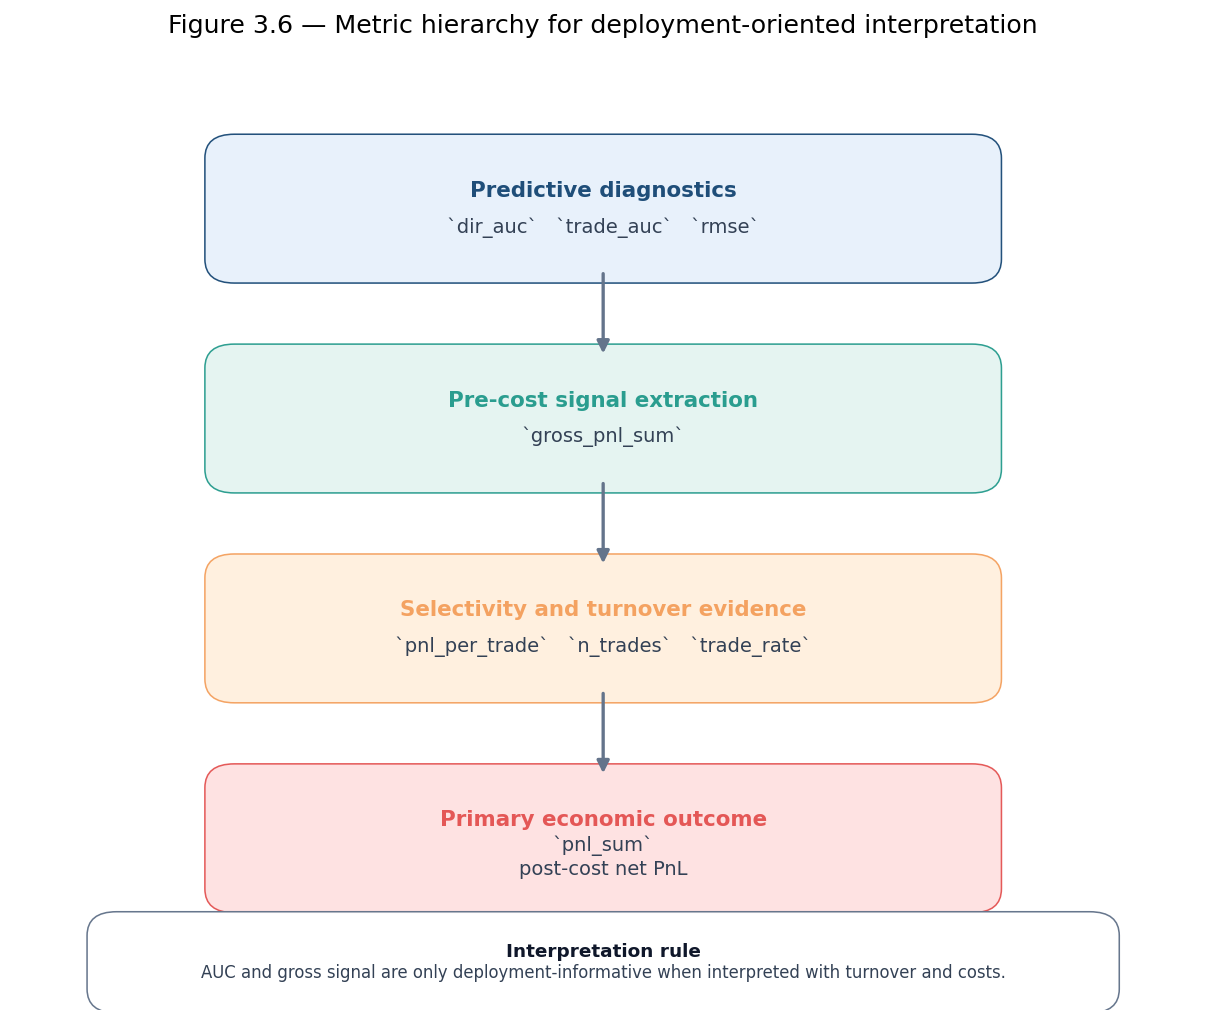

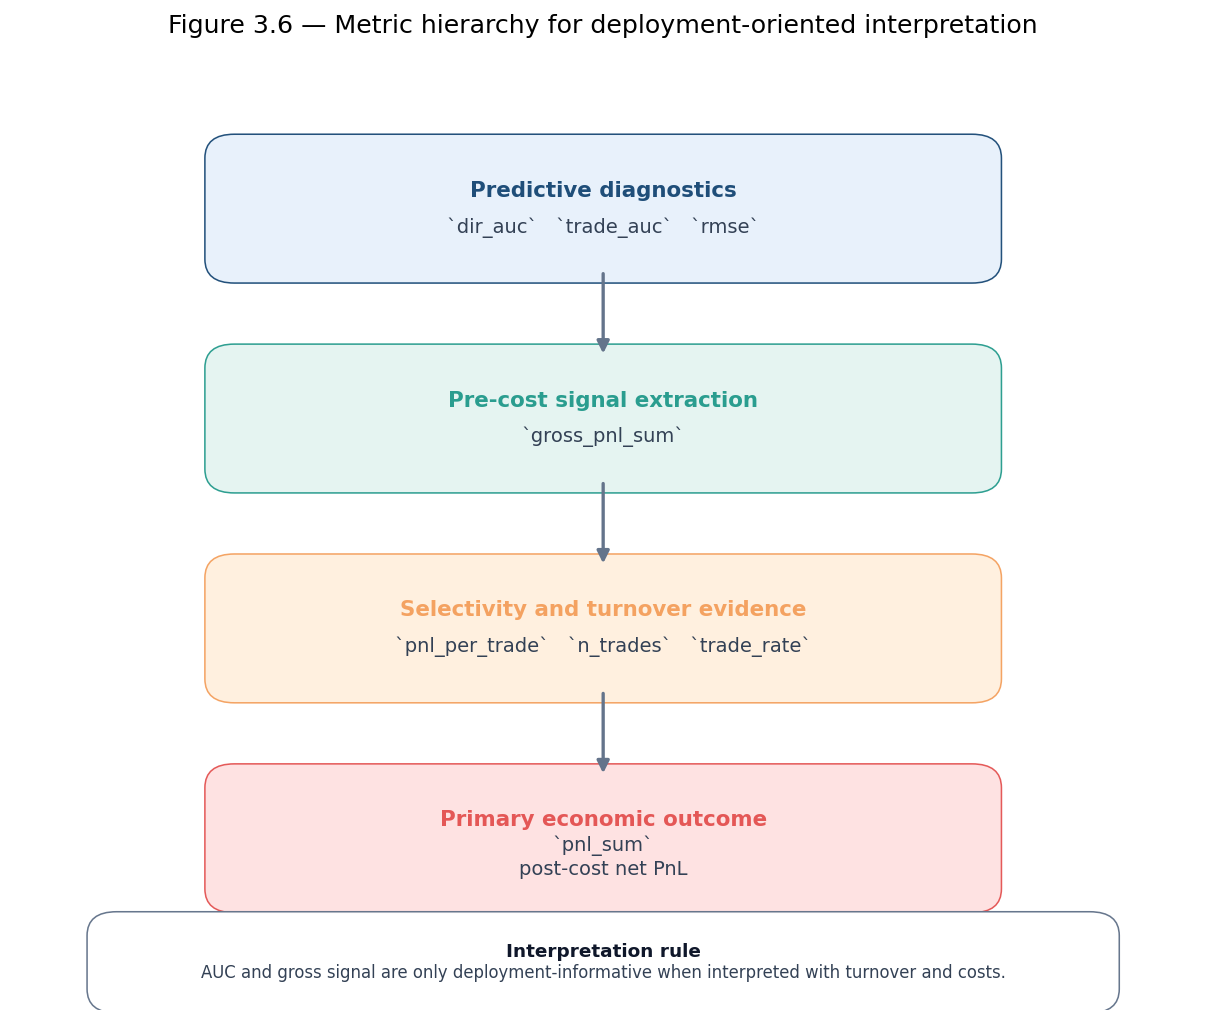

In [94]:
fig, ax = plt.subplots(figsize=(8.5, 7.2), constrained_layout=True)
ax.set_axis_off()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

levels = [
    ("Predictive diagnostics", "`dir_auc`   `trade_auc`   `rmse`", THESIS_COLORS["light_blue"], THESIS_COLORS["navy"]),
    ("Pre-cost signal extraction", "`gross_pnl_sum`", THESIS_COLORS["light_teal"], THESIS_COLORS["teal"]),
    ("Selectivity and turnover evidence", "`pnl_per_trade`   `n_trades`   `trade_rate`", THESIS_COLORS["light_orange"], THESIS_COLORS["orange"]),
    ("Primary economic outcome", "`pnl_sum`\npost-cost net PnL", "#fee2e2", THESIS_COLORS["red"]),
]
y_positions = [0.78, 0.56, 0.34, 0.12]
for (title, body, face, edge), y in zip(levels, y_positions):
    thesis_box(ax, (0.18, y), 0.64, 0.12, title, body, facecolor=face, edgecolor=edge, title_color=edge, fontsize=10, title_size=11)

for y0, y1 in zip(y_positions[:-1], y_positions[1:]):
    thesis_arrow(ax, (0.5, y0), (0.5, y1 + 0.12), color=THESIS_COLORS["slate"], lw=1.7)

thesis_box(
    ax,
    (0.08, 0.015),
    0.84,
    0.07,
    "Interpretation rule",
    "AUC and gross signal are only deployment-informative when interpreted with turnover and costs.",
    facecolor="white",
    edgecolor=THESIS_COLORS["slate"],
    title_color=THESIS_COLORS["ink"],
    fontsize=8.5,
    title_size=9.5,
)
ax.set_title("Figure 3.6 — Metric hierarchy for deployment-oriented interpretation", fontsize=13, pad=12)
fig


In [95]:
fig_3_6_path = save_thesis_figure(
    fig,
    figure_id="3.6",
    filename_stem="fig_3_6_metric_hierarchy",
    title="Metric hierarchy for deployment-oriented interpretation",
    source_artifacts=["paper_artifacts/good_Paper_draft.md", "final_runs/*/final_report.csv"],
    rendering_method="Python vector",
    main_text_section="Chapter 3",
    validation_checks="Includes dir_auc, trade_auc, rmse, gross_pnl_sum, pnl_per_trade, n_trades, trade_rate, and final pnl_sum.",
)
fig_3_6_path


PosixPath('/Users/vitalii/Desktop/Model_Market_Microstructure/GNN_for_LOB/paper_artifacts/figures_generated/fig_3_6_metric_hierarchy.png')

## Figure 4.1 — Architecture comparison of `base_gnn`, `multigraph`, and `memorygraph`

**Why this format**
- Hybrid is best because the figure is conceptual but must stay faithful to actual architectural differences visible in the code.

**Metadata**
- Figure type: `hybrid`
- Evidence source: `code-grounded`
- Rendering method: `Prompt-first hybrid`
- Primary inputs: `models/base_gnn_pipeline.py`, `models/multigraph_pipeline.py`, `models/memorygraph_pipeline.py`, `co_om_thesis_enhanced.md`
- Acceptance check: early relation fusion vs relation-specific pathways vs recurrent node-edge memory, shared output heads


**Generation body — final image prompt**

```text
Create a publication-quality academic architecture comparison diagram for a master's thesis.

Title: "Architecture comparison of base_gnn, multigraph, and memorygraph"

Show three aligned columns:
- base_gnn: early relation fusion
- multigraph: relation-specific graph pathways before learned fusion
- memorygraph: recurrent node and edge memory states with graph interaction inside the loop

Shared bottom section:
- common output heads for trade relevance, direction, return, exit-related outputs
```


In [96]:
architecture_columns = {
    "base_gnn": {
        "color": THESIS_COLORS["navy"],
        "accent": THESIS_COLORS["light_blue"],
        "steps": [
            ("Shared temporal encoders", "node + relation edge\nsequence encoders"),
            ("Early relation fusion", "relation channels combined\nbefore graph propagation"),
            ("Single graph stream", "adaptive/prior adjacency\nConv or MPNN block"),
            ("Target readout + trunk", "ETH node/global context\ncausal temporal trunk"),
        ],
        "note": "early relation fusion",
    },
    "multigraph": {
        "color": THESIS_COLORS["teal"],
        "accent": THESIS_COLORS["light_teal"],
        "steps": [
            ("Shared temporal encoders", "node + relation edge\nsequence encoders"),
            ("Relation-specific pathways", "one graph block per\nrelation channel"),
            ("Late relation fusion", "learned attention over\nrelation outputs"),
            ("Target readout + trunk", "same downstream\nprediction interface"),
        ],
        "note": "late fusion after parallel graph paths",
    },
    "memorygraph": {
        "color": THESIS_COLORS["orange"],
        "accent": THESIS_COLORS["light_orange"],
        "steps": [
            ("Step projectors", "per-time-step node\nand edge projections"),
            ("Node + edge memory", "state carried across\ntime steps"),
            ("Graph-in-memory loop", "Conv or MPNN on\nstate-enriched graph"),
            ("Target readout", "same prediction heads\nafter recurrent loop"),
        ],
        "note": "stateful recurrent memory updates",
    },
}

architecture_columns


{'base_gnn': {'color': '#1f4e79',
  'accent': '#e8f1fb',
  'steps': [('Shared temporal encoders',
    'node + relation edge\nsequence encoders'),
   ('Early relation fusion',
    'relation channels combined\nbefore graph propagation'),
   ('Single graph stream', 'adaptive/prior adjacency\nConv or MPNN block'),
   ('Target readout + trunk',
    'ETH node/global context\ncausal temporal trunk')],
  'note': 'early relation fusion'},
 'multigraph': {'color': '#2a9d8f',
  'accent': '#e5f4f1',
  'steps': [('Shared temporal encoders',
    'node + relation edge\nsequence encoders'),
   ('Relation-specific pathways', 'one graph block per\nrelation channel'),
   ('Late relation fusion', 'learned attention over\nrelation outputs'),
   ('Target readout + trunk', 'same downstream\nprediction interface')],
  'note': 'late fusion after parallel graph paths'},
 'memorygraph': {'color': '#f4a261',
  'accent': '#fff0df',
  'steps': [('Step projectors', 'per-time-step node\nand edge projections'),
   ('N

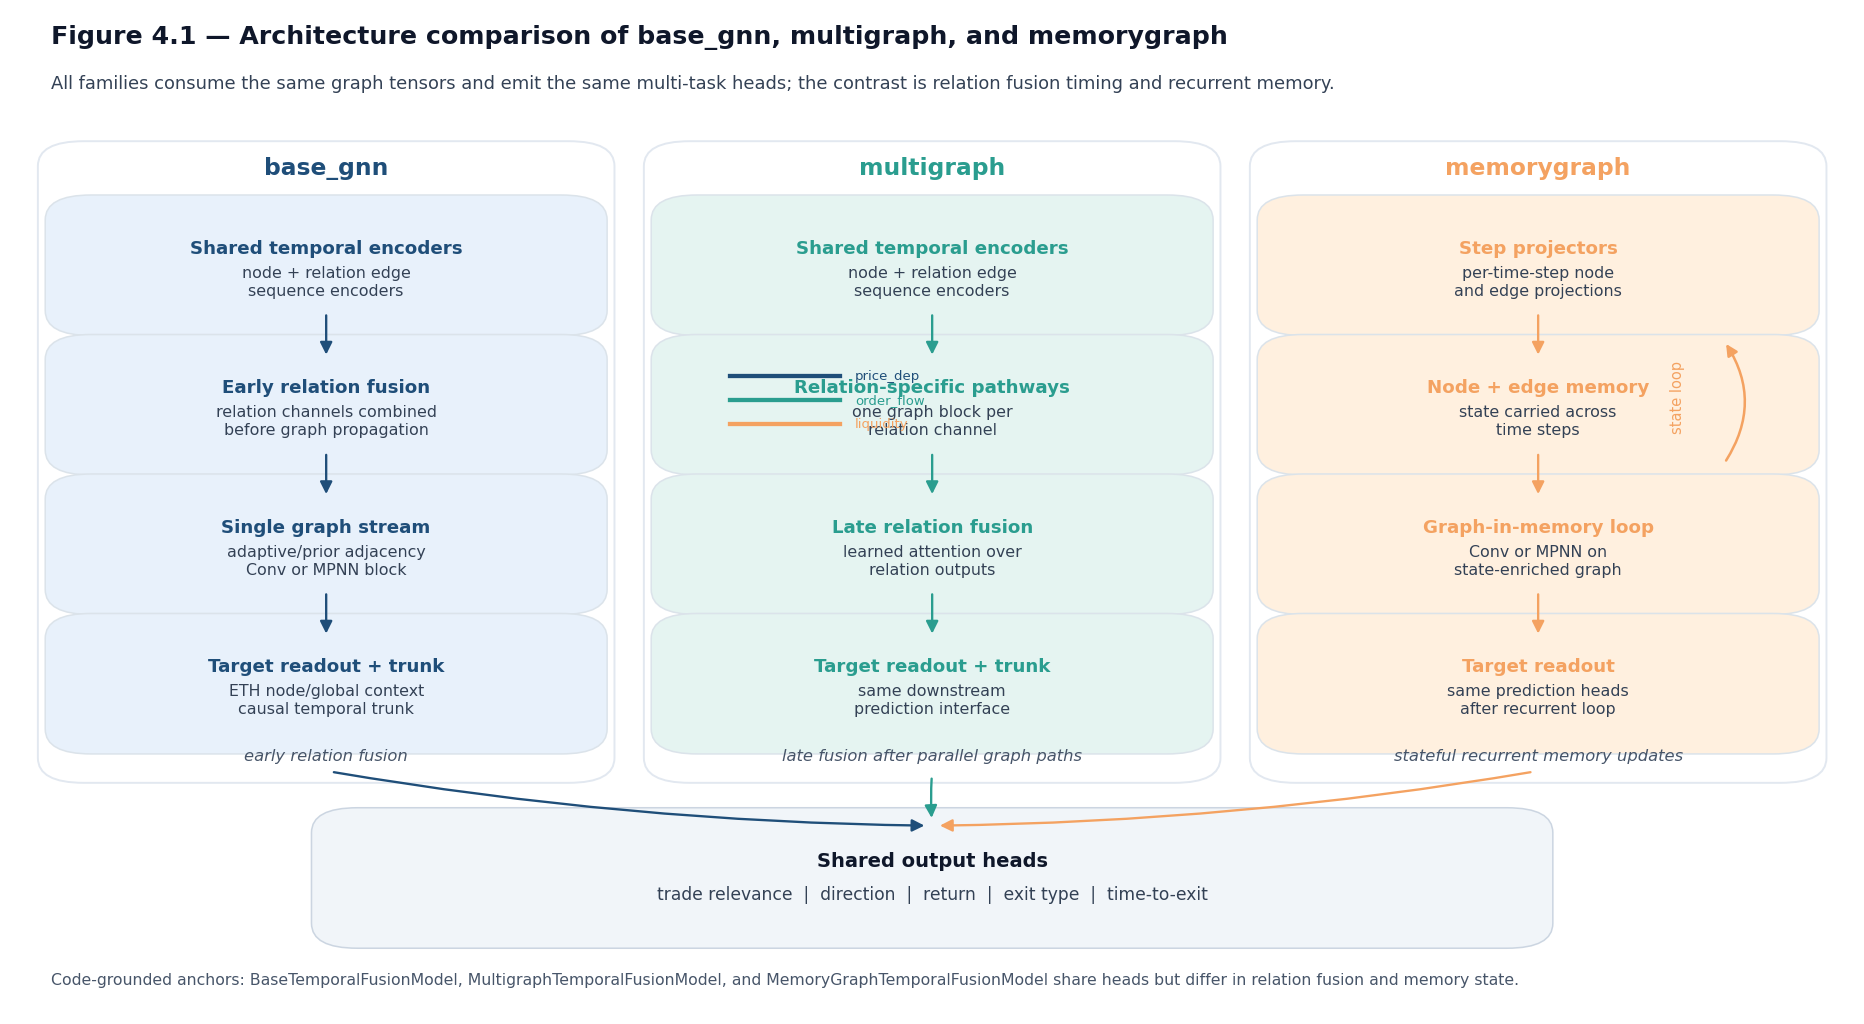

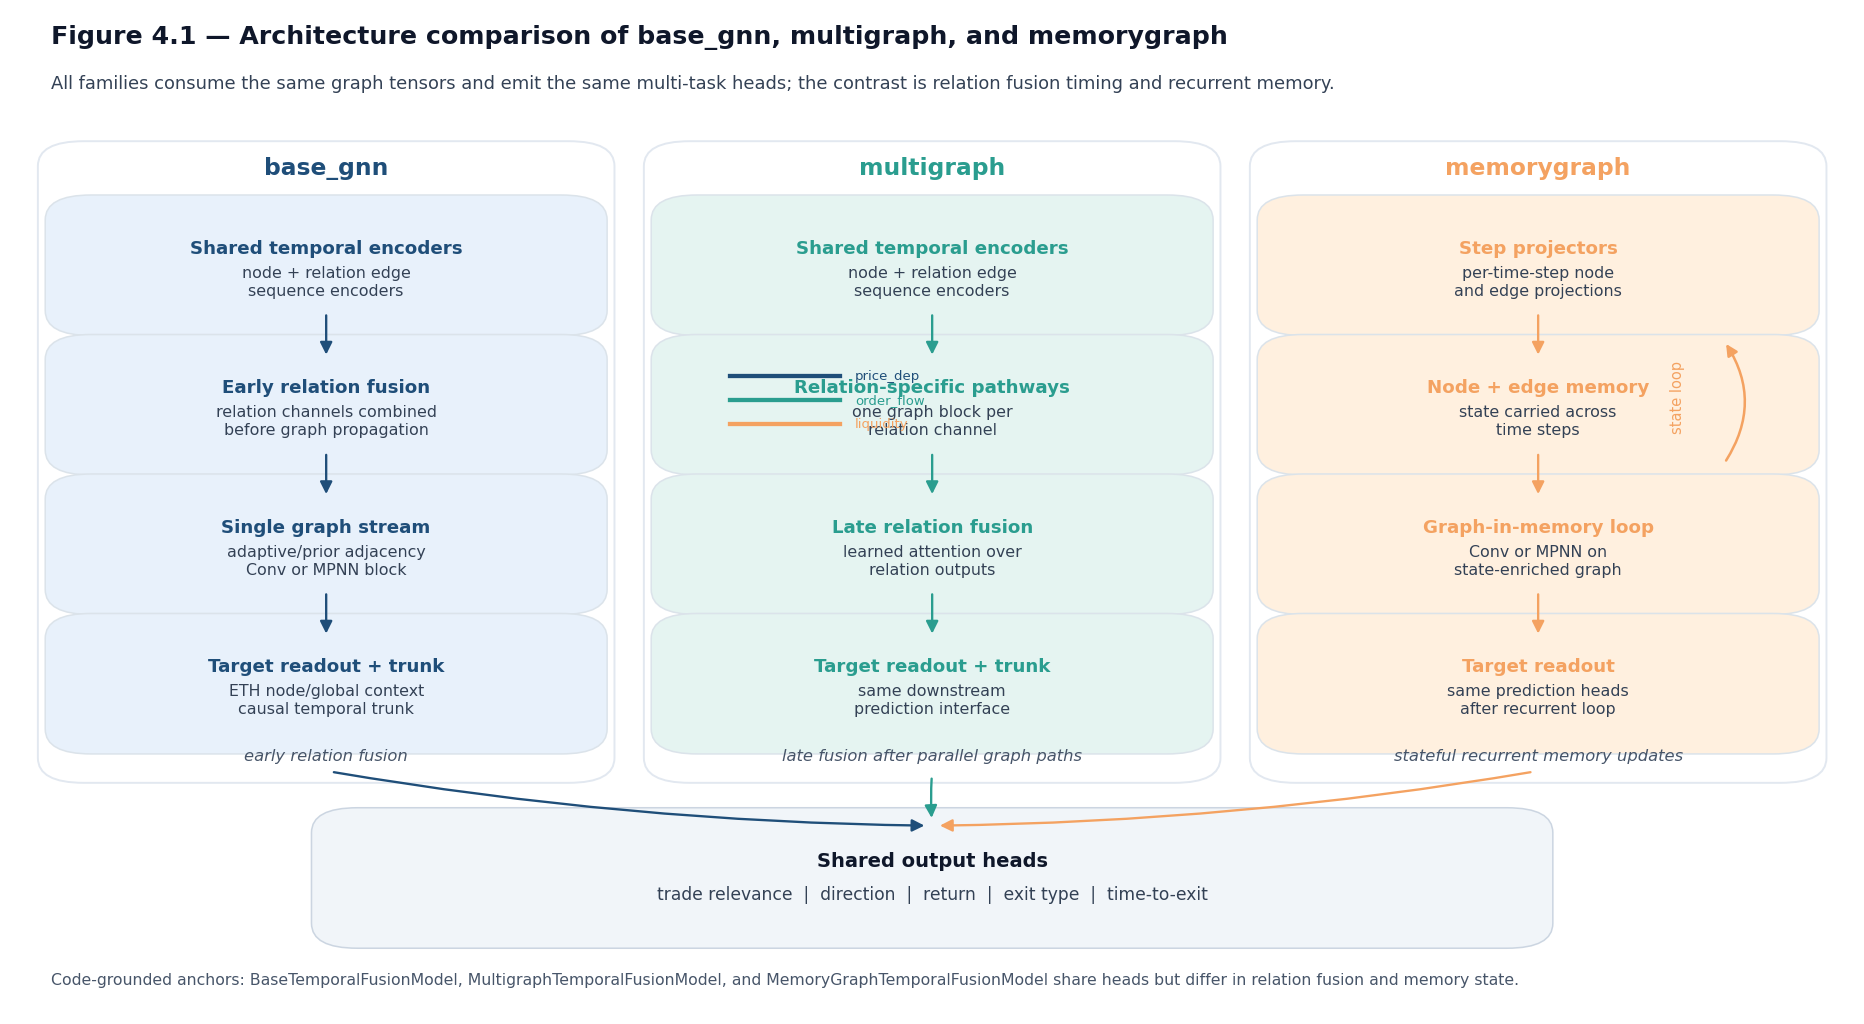

In [97]:
fig, ax = plt.subplots(figsize=(13.2, 7.2), constrained_layout=True)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(0.02, 0.97, "Figure 4.1 — Architecture comparison of base_gnn, multigraph, and memorygraph", fontsize=13, fontweight="bold", ha="left", color=THESIS_COLORS["ink"])
ax.text(
    0.02,
    0.925,
    "All families consume the same graph tensors and emit the same multi-task heads; the contrast is relation fusion timing and recurrent memory.",
    fontsize=9.2,
    color="#334155",
    ha="left",
)

col_x = [0.035, 0.365, 0.695]
col_w = 0.27
y_top = 0.80
step_h = 0.105
step_gap = 0.035
for (family, spec), x in zip(architecture_columns.items(), col_x):
    ax.add_patch(
        FancyBboxPatch(
            (x - 0.01, 0.24),
            col_w + 0.02,
            0.62,
            boxstyle="round,pad=0.012,rounding_size=0.025",
            facecolor="#ffffff",
            edgecolor="#e2e8f0",
            linewidth=1.0,
        )
    )
    ax.text(x + col_w / 2, 0.845, family, ha="center", va="center", fontsize=12, fontweight="bold", color=spec["color"])
    prev_center = None
    for j, (title, body) in enumerate(spec["steps"]):
        y = y_top - j * (step_h + step_gap) - step_h
        thesis_box(ax, (x, y), col_w, step_h, title, body, facecolor=spec["accent"], edgecolor="#dbe3ea", title_color=spec["color"], title_size=9.4, fontsize=8.2)
        center = (x + col_w / 2, y + step_h / 2)
        if prev_center:
            thesis_arrow(ax, (prev_center[0], prev_center[1] - step_h / 2 + 0.01), (center[0], center[1] + step_h / 2 - 0.01), color=spec["color"], lw=1.2)
        prev_center = center
    ax.text(x + col_w / 2, 0.255, spec["note"], ha="center", va="center", fontsize=8.4, color="#475569", style="italic")

lane_x0 = col_x[1] + 0.025
lane_y = 0.80 - 1 * (step_h + step_gap) - step_h + 0.025
for k, (rel, color) in enumerate(RELATION_COLORS.items()):
    yy = lane_y + 0.056 - k * 0.024
    ax.plot([lane_x0, lane_x0 + 0.06], [yy, yy], color=color, lw=2.2)
    ax.text(lane_x0 + 0.068, yy, rel, va="center", fontsize=6.8, color=color)

mx = col_x[2] + col_w - 0.035
thesis_arrow(ax, (mx, 0.545), (mx, 0.675), color=THESIS_COLORS["orange"], lw=1.3, rad=0.35, mutation_scale=12)
ax.text(mx - 0.02, 0.615, "state loop", ha="right", va="center", fontsize=7.5, color=THESIS_COLORS["orange"], rotation=90)

head_y = 0.08
thesis_box(
    ax,
    (0.18, head_y),
    0.64,
    0.105,
    "Shared output heads",
    "trade relevance  |  direction  |  return  |  exit type  |  time-to-exit",
    facecolor=THESIS_COLORS["light_slate"],
    edgecolor="#cbd5e1",
    title_size=10,
    fontsize=8.8,
)
for x, spec in zip(col_x, architecture_columns.values()):
    thesis_arrow(ax, (x + col_w / 2, 0.24), (0.50, head_y + 0.105), color=spec["color"], lw=1.2, rad=0.04 if x < 0.5 else -0.04)

ax.text(
    0.02,
    0.025,
    "Code-grounded anchors: BaseTemporalFusionModel, MultigraphTemporalFusionModel, and MemoryGraphTemporalFusionModel share heads but differ in relation fusion and memory state.",
    fontsize=8.1,
    color="#475569",
    ha="left",
)
fig


In [98]:
fig_4_1_path = save_thesis_figure(
    fig,
    figure_id="4.1",
    filename_stem="fig_4_1_architecture_comparison",
    title="Architecture comparison of base_gnn, multigraph, and memorygraph",
    source_artifacts=['models/base_gnn_pipeline.py', 'models/multigraph_pipeline.py', 'models/memorygraph_pipeline.py'],
    rendering_method="Python vector, code-grounded",
    main_text_section="Chapter 4",
    validation_checks="All families share output heads; Conv/MPNN shown as operator choices.",
)
fig_4_1_path


PosixPath('/Users/vitalii/Desktop/Model_Market_Microstructure/GNN_for_LOB/paper_artifacts/figures_generated/fig_4_1_architecture_comparison.png')

## Figure 4.2 — Recurrent node and edge memory update in `memorygraph`

**Why this format**
- Hybrid is necessary because the underlying mechanism is code-grounded but visually too complex for a purely auto-laid-out plot.

**Metadata**
- Figure type: `hybrid`
- Evidence source: `code-grounded`
- Rendering method: `Prompt-first hybrid`
- Primary inputs: `models/memorygraph_pipeline.py`, `co_om_thesis_enhanced.md`
- Acceptance check: edge memory from current edge/node states, node update from relation-specific edge context, recurrent loop visible


**Generation body — final image prompt**

```text
Create a clean academic recurrent-mechanism diagram for a graph neural network thesis.

Title: "Recurrent node and edge memory update in memorygraph"

Show:
1. inputs to edge memory update
2. edge memory update block
3. relation-specific edge context aggregation
4. node memory update block
5. updated node and edge states
6. explicit recurrent loop across time steps
```


In [99]:
memory_update_steps = [
    {"stage": "Current step inputs", "body": "node state h_t\nedge state e_t\nprevious memories", "color": THESIS_COLORS["light_slate"]},
    {"stage": "Edge memory update", "body": "GRUCell(e_t, h_src, h_dst,\nh_src − h_dst, h_src × h_dst)", "color": THESIS_COLORS["light_orange"]},
    {"stage": "State-enriched graph operator", "body": "relation graph block\nConv or MPNN messages", "color": THESIS_COLORS["light_blue"]},
    {"stage": "Node memory update", "body": "GRUCell(fused node state,\nrelation edge context)", "color": THESIS_COLORS["light_teal"]},
    {"stage": "Output for step t", "body": "enriched node state\nnew node/edge memories", "color": THESIS_COLORS["light_slate"]},
]

memory_update_steps


[{'stage': 'Current step inputs',
  'body': 'node state h_t\nedge state e_t\nprevious memories',
  'color': '#f1f5f9'},
 {'stage': 'Edge memory update',
  'body': 'GRUCell(e_t, h_src, h_dst,\nh_src − h_dst, h_src × h_dst)',
  'color': '#fff0df'},
 {'stage': 'State-enriched graph operator',
  'body': 'relation graph block\nConv or MPNN messages',
  'color': '#e8f1fb'},
 {'stage': 'Node memory update',
  'body': 'GRUCell(fused node state,\nrelation edge context)',
  'color': '#e5f4f1'},
 {'stage': 'Output for step t',
  'body': 'enriched node state\nnew node/edge memories',
  'color': '#f1f5f9'}]

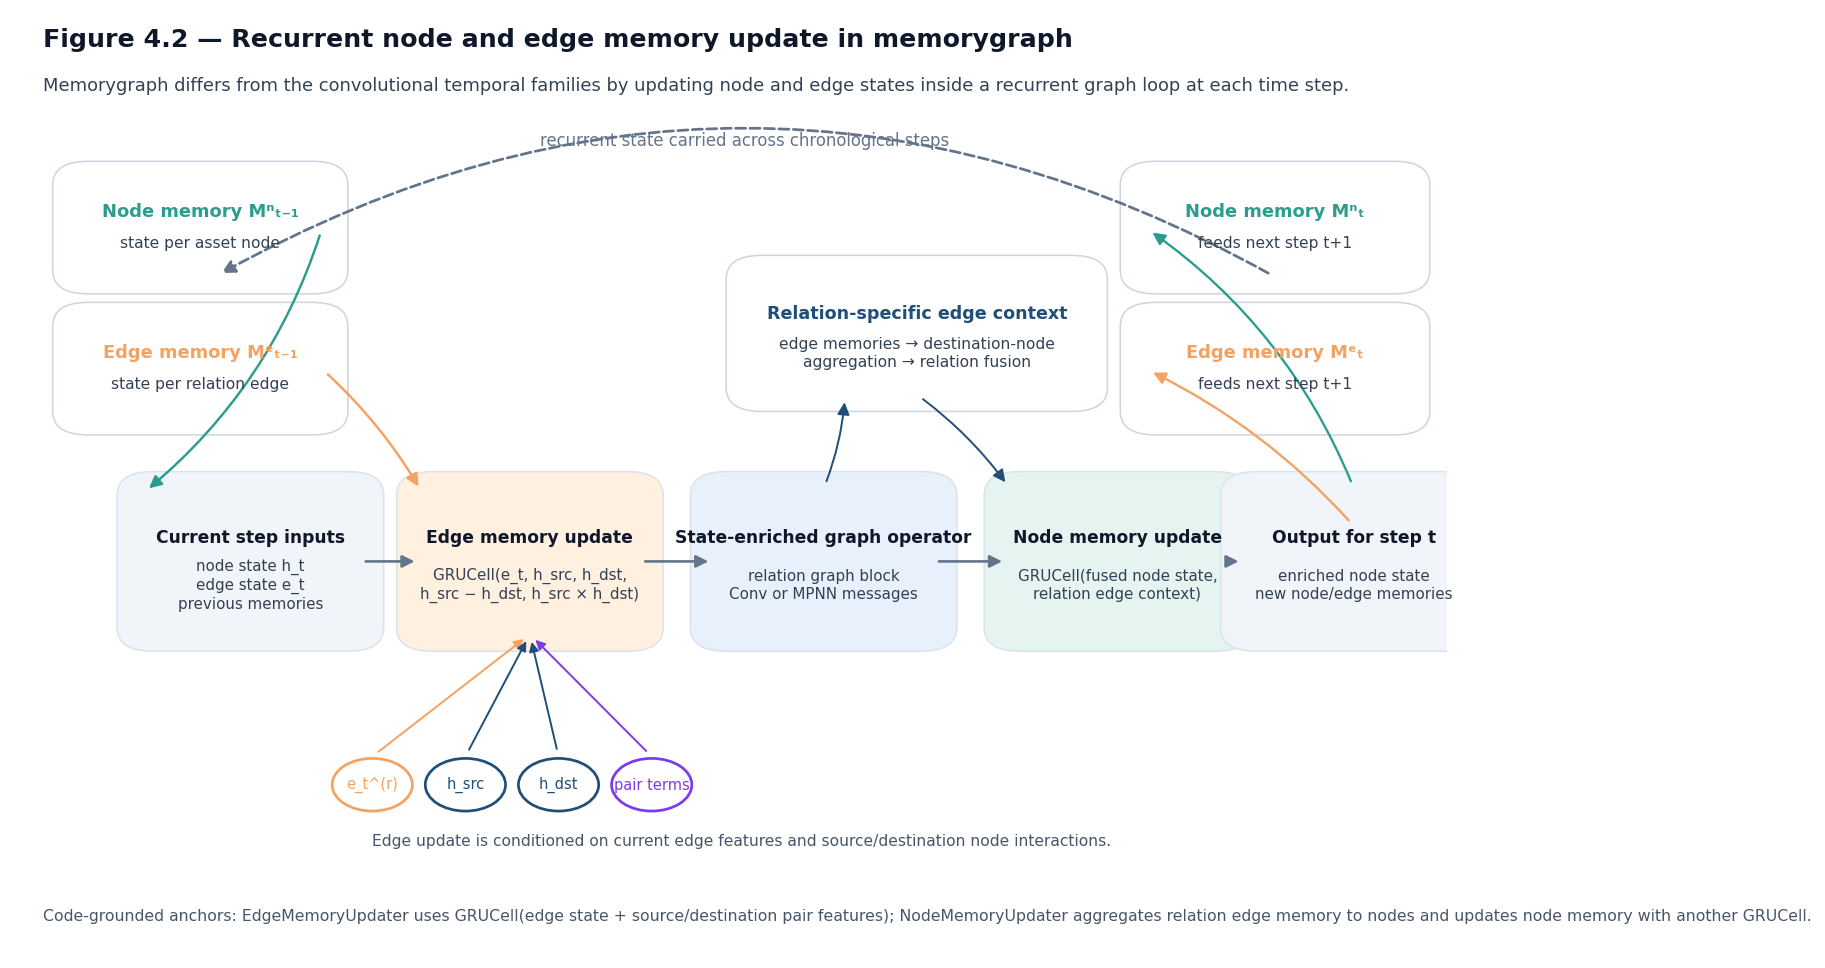

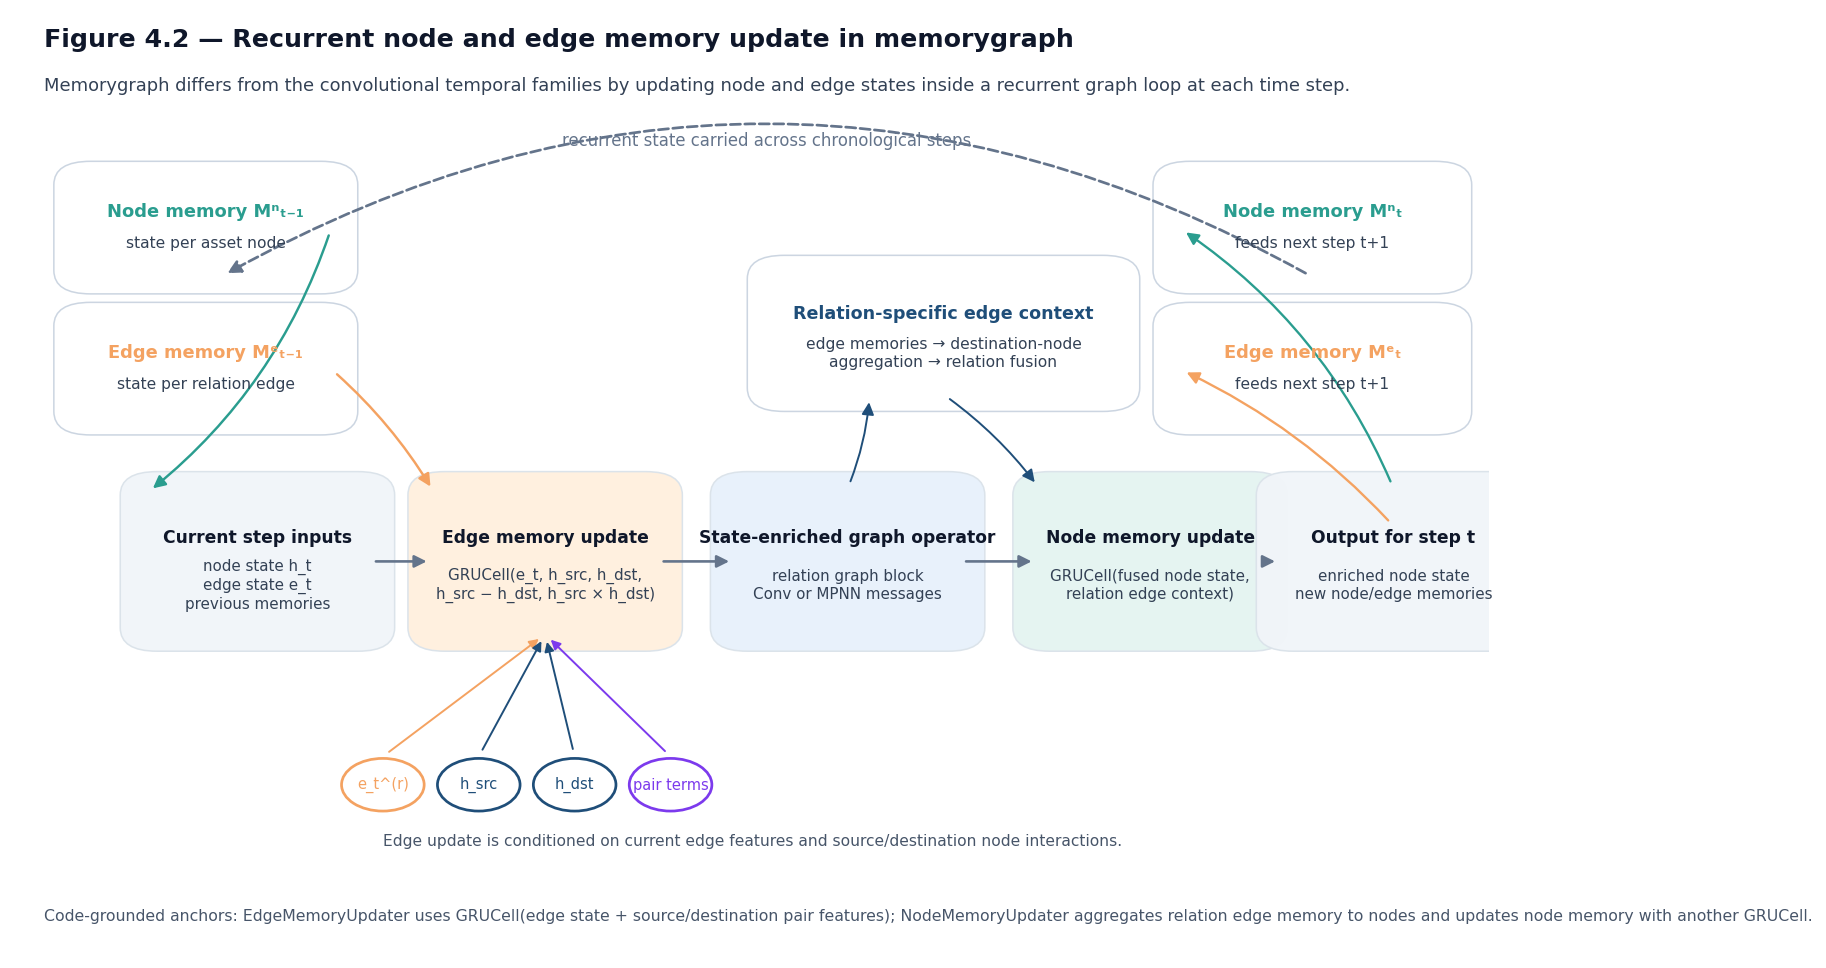

In [100]:
fig, ax = plt.subplots(figsize=(13.0, 6.8), constrained_layout=True)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(0.02, 0.965, "Figure 4.2 — Recurrent node and edge memory update in memorygraph", fontsize=13, fontweight="bold", ha="left", color=THESIS_COLORS["ink"])
ax.text(
    0.02,
    0.918,
    "Memorygraph differs from the convolutional temporal families by updating node and edge states inside a recurrent graph loop at each time step.",
    fontsize=9.2,
    color="#334155",
    ha="left",
)

thesis_box(ax, (0.045, 0.72), 0.17, 0.105, "Node memory Mⁿₜ₋₁", "state per asset node", facecolor="#ffffff", edgecolor="#cbd5e1", title_color=THESIS_COLORS["teal"], fontsize=8.0, title_size=9.2)
thesis_box(ax, (0.045, 0.57), 0.17, 0.105, "Edge memory Mᵉₜ₋₁", "state per relation edge", facecolor="#ffffff", edgecolor="#cbd5e1", title_color=THESIS_COLORS["orange"], fontsize=8.0, title_size=9.2)

x_positions = [0.09, 0.285, 0.49, 0.695, 0.86]
y = 0.34
w = 0.15
h = 0.155
for i, step in enumerate(memory_update_steps):
    x = x_positions[i]
    thesis_box(ax, (x, y), w, h, step["stage"], step["body"], facecolor=step["color"], edgecolor="#dbe3ea", title_size=8.8, fontsize=7.8)
    if i > 0:
        thesis_arrow(ax, (x_positions[i - 1] + w, y + h / 2), (x, y + h / 2), color=THESIS_COLORS["slate"], lw=1.35)

input_y = 0.18
inputs = [
    ("e_t^(r)", 0.25, THESIS_COLORS["orange"]),
    ("h_src", 0.315, THESIS_COLORS["navy"]),
    ("h_dst", 0.38, THESIS_COLORS["navy"]),
    ("pair terms", 0.445, THESIS_COLORS["purple"]),
]
for label, x, color in inputs:
    ax.add_patch(Circle((x, input_y), 0.028, facecolor="#ffffff", edgecolor=color, linewidth=1.4))
    ax.text(x, input_y, label, ha="center", va="center", fontsize=7.5, color=color)
    thesis_arrow(ax, (x, input_y + 0.03), (0.285 + w / 2, y), color=color, lw=1.0, mutation_scale=10)
ax.text(0.25, 0.115, "Edge update is conditioned on current edge features and source/destination node interactions.", fontsize=8.0, color="#475569", ha="left")

thesis_arrow(ax, (0.215, 0.772), (0.09, 0.49), color=THESIS_COLORS["teal"], lw=1.25, rad=-0.15)
thesis_arrow(ax, (0.215, 0.622), (0.285, 0.49), color=THESIS_COLORS["orange"], lw=1.25, rad=-0.08)

thesis_box(ax, (0.79, 0.72), 0.18, 0.105, "Node memory Mⁿₜ", "feeds next step t+1", facecolor="#ffffff", edgecolor="#cbd5e1", title_color=THESIS_COLORS["teal"], fontsize=8.0, title_size=9.2)
thesis_box(ax, (0.79, 0.57), 0.18, 0.105, "Edge memory Mᵉₜ", "feeds next step t+1", facecolor="#ffffff", edgecolor="#cbd5e1", title_color=THESIS_COLORS["orange"], fontsize=8.0, title_size=9.2)
thesis_arrow(ax, (0.86 + w / 2, 0.495), (0.79, 0.772), color=THESIS_COLORS["teal"], lw=1.2, rad=0.15)
thesis_arrow(ax, (0.86 + w / 2, 0.455), (0.79, 0.622), color=THESIS_COLORS["orange"], lw=1.2, rad=0.10)
thesis_arrow(ax, (0.88, 0.72), (0.14, 0.72), color=THESIS_COLORS["slate"], lw=1.4, rad=0.28, linestyle="--", mutation_scale=14)
ax.text(0.51, 0.86, "recurrent state carried across chronological steps", ha="center", fontsize=8.5, color=THESIS_COLORS["slate"])

thesis_box(ax, (0.515, 0.595), 0.23, 0.13, "Relation-specific edge context", "edge memories → destination-node\naggregation → relation fusion", facecolor="#ffffff", edgecolor="#cbd5e1", title_color=THESIS_COLORS["navy"], fontsize=8.0, title_size=9.0)
thesis_arrow(ax, (0.565, 0.495), (0.58, 0.595), color=THESIS_COLORS["navy"], lw=1.0, rad=0.08)
thesis_arrow(ax, (0.63, 0.595), (0.695, 0.495), color=THESIS_COLORS["navy"], lw=1.0, rad=-0.08)

ax.text(
    0.02,
    0.035,
    "Code-grounded anchors: EdgeMemoryUpdater uses GRUCell(edge state + source/destination pair features); NodeMemoryUpdater aggregates relation edge memory to nodes and updates node memory with another GRUCell.",
    fontsize=8.1,
    color="#475569",
    ha="left",
)
fig


In [101]:
fig_4_2_path = save_thesis_figure(
    fig,
    figure_id="4.2",
    filename_stem="fig_4_2_memorygraph_recurrent_memory_update",
    title="Recurrent node and edge memory update in memorygraph",
    source_artifacts=['models/memorygraph_pipeline.py'],
    rendering_method="Python vector, code-grounded",
    main_text_section="Chapter 4",
    validation_checks="Edge memory precedes node memory; recurrent loop and relation context shown.",
)
fig_4_2_path


PosixPath('/Users/vitalii/Desktop/Model_Market_Microstructure/GNN_for_LOB/paper_artifacts/figures_generated/fig_4_2_memorygraph_recurrent_memory_update.png')

## Figure 5.1 — Benchmark overview by frequency, graph family, and operator

**Why this format**
- Python is mandatory because this figure is a direct visual summary of benchmark results and should be generated from the result tables.

**Metadata**
- Figure type: `executable`
- Evidence source: `artifact-grounded`
- Rendering method: `Python`
- Primary inputs: `final_runs/*/final_report.csv`, optionally `*_final_summary.csv`
- Acceptance check: all 18 primary `last_CV` model-frequency configurations, grouped by frequency and family/operator, metric=`pnl_sum`, caution note about no significance testing


**Generation body**
- Extract `last_cv` rows only.
- Normalize labels into 18 comparable benchmark entries.
- Use grouped bar chart or heatmap.
- Add note: no uncertainty intervals / no formal dominance testing.

**Planned future code cells**
1. load benchmark summaries
2. normalize benchmark labels
3. render results overview
4. export figure


In [102]:
benchmark_df = load_benchmark_metrics(model_state="last_cv")
benchmark_df[["frequency", "model_label", "pnl_sum", "gross_pnl_sum", "n_trades", "trade_rate", "pnl_per_trade", "cost_drag"]]


,frequency,model_label,pnl_sum,gross_pnl_sum,n_trades,trade_rate,pnl_per_trade,cost_drag
0,5min,base-gnn-conv,0.020356,0.028156,26,0.084142,0.000783,0.0078
1,5min,base-gnn-mpnn,0.006915,0.014415,25,0.080906,0.000277,0.0075
2,5min,multi-gnn-conv,0.001958,0.012758,36,0.116505,0.000054,0.0108
3,5min,multi-gnn-mpnn,-0.009359,0.002941,41,0.132686,-0.000228,0.0123
4,5min,memory-gnn-conv,0.004359,0.009459,17,0.055016,0.000256,0.0051
5,5min,memory-gnn-mpnn,-0.037363,-0.012463,83,0.268608,-0.000450,0.0249
6,1min,base-gnn-conv,0.020094,0.059694,132,0.085548,0.000152,0.0396
7,1min,base-gnn-mpnn,-0.078539,-0.024239,181,0.117304,-0.000434,0.0543
8,1min,multi-gnn-conv,-0.007833,0.025767,112,0.072586,-0.000070,0.0336
9,1min,multi-gnn-mpnn,-0.035771,-0.003371,108,0.069994,-0.000331,0.0324


In [103]:
benchmark_panels = {
    freq: benchmark_df[benchmark_df["frequency"] == freq].sort_values("order").reset_index(drop=True)
    for freq in FREQUENCY_ORDER
}


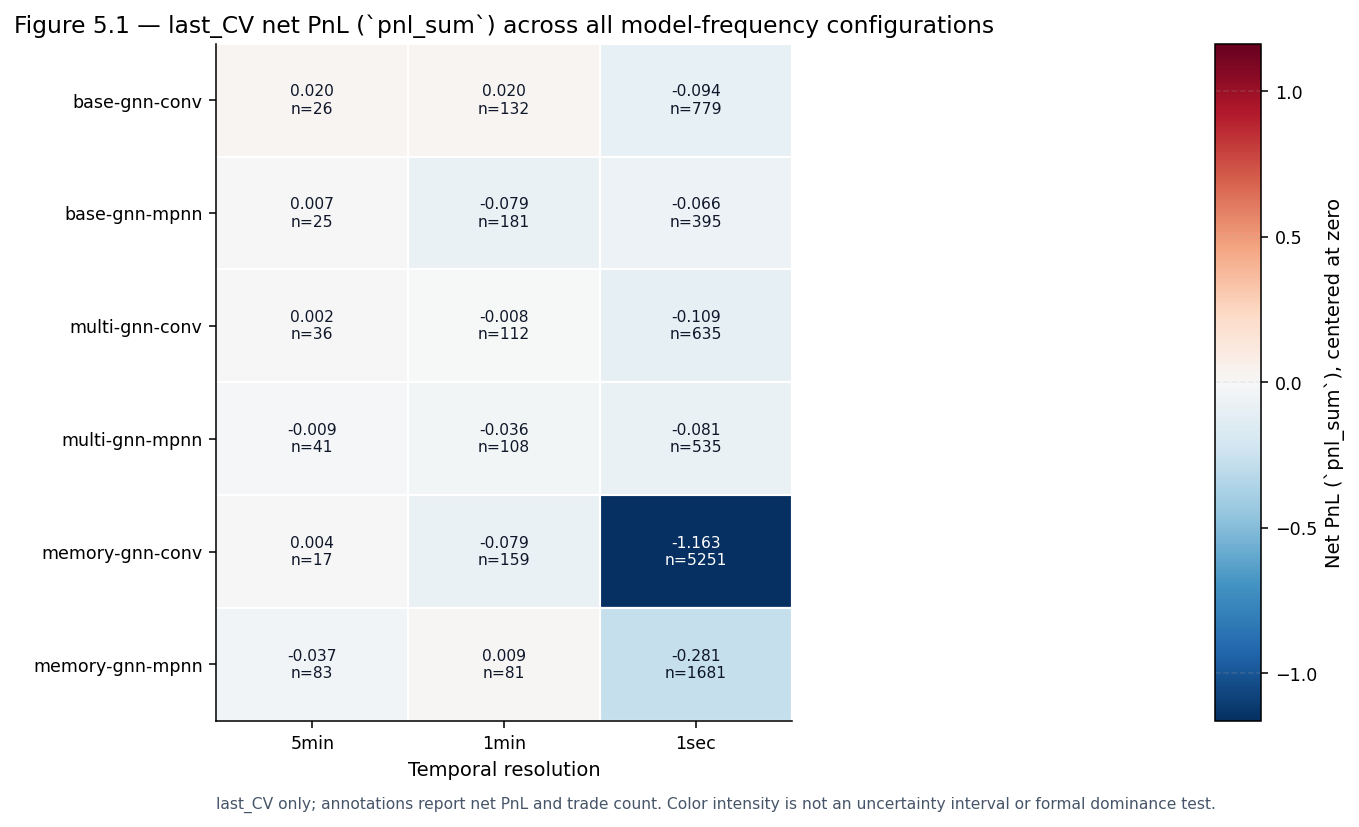

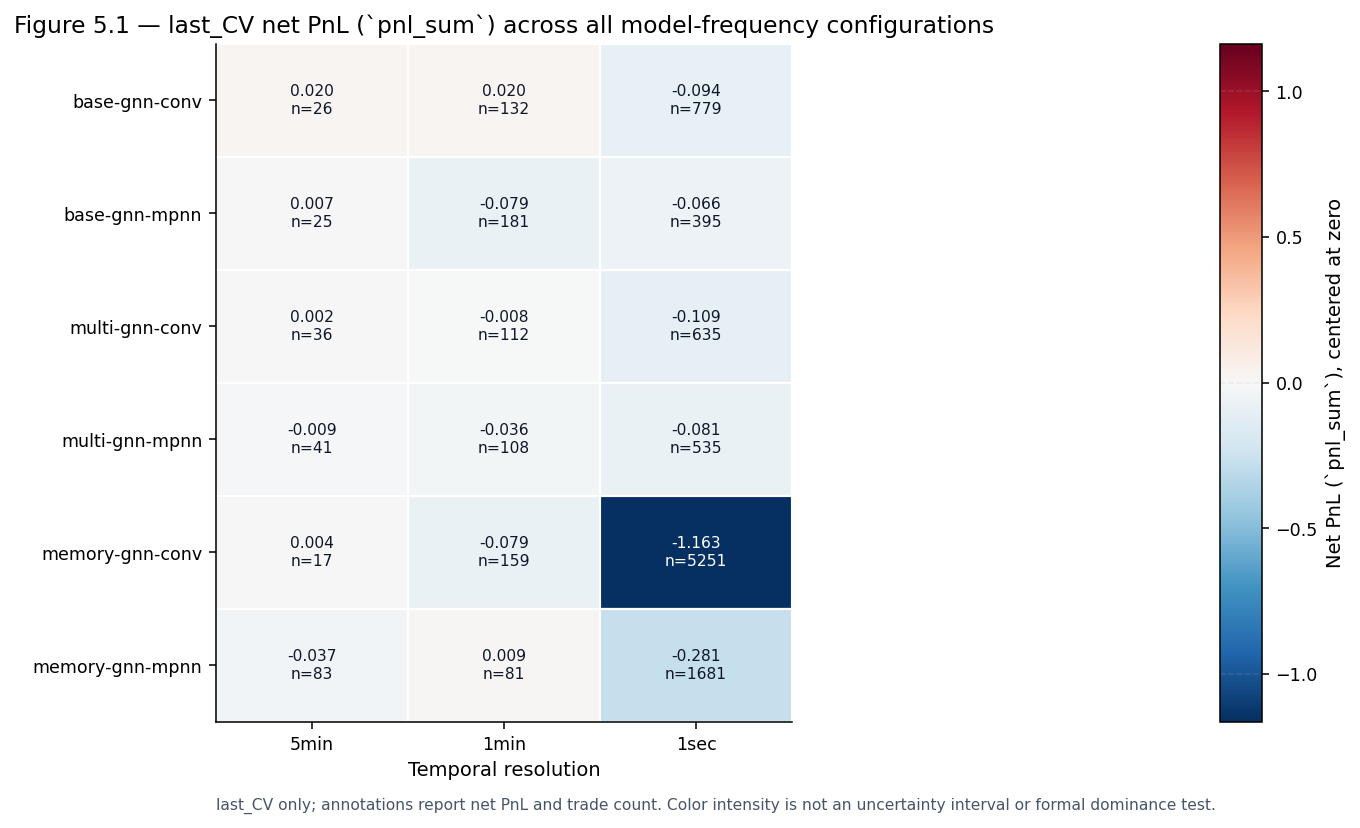

In [104]:
heat = benchmark_df.pivot(index="model_label", columns="frequency", values="pnl_sum").loc[BENCHMARK_ORDER, FREQUENCY_ORDER]
trade_counts = benchmark_df.pivot(index="model_label", columns="frequency", values="n_trades").loc[BENCHMARK_ORDER, FREQUENCY_ORDER]
vmax = float(np.nanmax(np.abs(heat.to_numpy())))
norm = mpl.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

# Use an explicit mesh instead of imshow so saved vector/raster outputs preserve
# the intended rectangular cells rather than drifting toward square blocks.
fig = plt.figure(figsize=(9.4, 5.8), constrained_layout=True)
gs = fig.add_gridspec(1, 2, width_ratios=[18, 1])
ax = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])

x_edges = np.arange(len(FREQUENCY_ORDER) + 1)
y_edges = np.arange(len(BENCHMARK_ORDER) + 1)
mesh = ax.pcolormesh(
    x_edges,
    y_edges,
    heat.to_numpy(),
    cmap="RdBu_r",
    norm=norm,
    shading="flat",
    edgecolors="#ffffff",
    linewidth=1.1,
    antialiased=True,
)

ax.set_xlim(0, len(FREQUENCY_ORDER))
ax.set_ylim(len(BENCHMARK_ORDER), 0)
ax.set_xticks(np.arange(len(FREQUENCY_ORDER)) + 0.5)
ax.set_xticklabels(FREQUENCY_ORDER)
ax.set_yticks(np.arange(len(BENCHMARK_ORDER)) + 0.5)
ax.set_yticklabels(BENCHMARK_ORDER)
ax.set_xlabel("Temporal resolution")
ax.set_title("Figure 5.1 — last_CV net PnL (`pnl_sum`) across all model-frequency configurations")
ax.grid(False)

# Force a stable rectangular cell geometry in saved output.
ax.set_box_aspect(len(BENCHMARK_ORDER) / (len(FREQUENCY_ORDER) * 1.7))

for i, model in enumerate(BENCHMARK_ORDER):
    for j, freq in enumerate(FREQUENCY_ORDER):
        value = float(heat.loc[model, freq])
        trades = int(trade_counts.loc[model, freq])
        color = "white" if abs(value) > 0.55 * vmax else THESIS_COLORS["ink"]
        ax.text(j + 0.5, i + 0.5, f"{value:.3f}\nn={trades}", ha="center", va="center", fontsize=8, color=color)

cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("Net PnL (`pnl_sum`), centered at zero")
ax.text(
    0.0,
    -0.13,
    "last_CV only; annotations report net PnL and trade count. Color intensity is not an uncertainty interval or formal dominance test.",
    transform=ax.transAxes,
    fontsize=8,
    color="#475569",
)
fig


In [105]:
fig_5_1_path = save_thesis_figure(
    fig,
    figure_id="5.1",
    filename_stem="fig_5_1_benchmark_overview",
    title="Benchmark overview by frequency, graph family, and operator",
    source_artifacts=['final_runs/*/final_report.csv'],
    rendering_method="Python, artifact-grounded",
    main_text_section="Chapter 5",
    validation_checks="All 18 last_CV rows shown; diverging scale centered at zero; no significance claim.",
)
fig_5_1_path


PosixPath('/Users/vitalii/Desktop/Model_Market_Microstructure/GNN_for_LOB/paper_artifacts/figures_generated/fig_5_1_benchmark_overview.png')

## Figure 5.2 / 5.3 — Representative final-holdout trading paths

**Why this format**
- Python is mandatory because these figures reconstruct realized trade-exit PnL paths from final-holdout trade logs and align them with market clock time.

**Metadata**
- Figure type: `executable`
- Evidence source: `artifact-grounded`
- Rendering method: `Python`
- Primary inputs: selected `*_final_holdout_last_cv_trade_log.csv` files and `ETH_1min.csv`
- Acceptance check: representative 5min, 1min, and 1sec net-best paths; gross and net variants; ETH midpoint context; full-holdout totals match Table 5.1 before display-window clipping


In [106]:
import matplotlib.dates as mdates

# Figure 5.2/5.3 alignment policy:
# - PnL paths are computed from each model's full final-holdout trade log.
# - The cross-frequency figures display the strict common clock-time intersection
#   from 2021-04-17 03:25:34 UTC through 2021-04-18 05:05:00 UTC, derived from
#   `paper_artifacts/final_holdout_alignment_table.md`.
# - Legends report full-holdout totals; endpoint labels report displayed-window totals
#   when strict clipping excludes a tail trade.
# - ETH midpoint is read from the 1min source as a common market-context reference;
#   the very large 1sec source is intentionally avoided for these overview figures.

REPRESENTATIVE_TRADE_PATH_SPECS = [
    {
        "frequency": "5min",
        "model_label": "base-gnn-conv",
        "display_label": "5min base-gnn-conv",
        "family": "base-gnn",
        "color": FAMILY_COLORS["base-gnn"],
        "trade_log": REPO_ROOT / "final_runs/5min-base-gnn/adaptive_conv/adaptive_conv_final_holdout_last_cv_trade_log.csv",
        "holdout_start": pd.Timestamp("2021-04-17T03:25:00Z"),
        "holdout_end": pd.Timestamp("2021-04-18T05:05:00Z"),
        "expected_gross": 0.0281563144235406,
        "expected_net": 0.0203563144235406,
    },
    {
        "frequency": "1min",
        "model_label": "base-gnn-conv",
        "display_label": "1min base-gnn-conv",
        "family": "base-gnn",
        "color": THESIS_COLORS["teal"],
        "trade_log": REPO_ROOT / "final_runs/1min-base-gnn-conv/adaptive_conv/adaptive_conv_final_holdout_last_cv_trade_log.csv",
        "holdout_start": pd.Timestamp("2021-04-17T03:25:00Z"),
        "holdout_end": pd.Timestamp("2021-04-18T05:07:00Z"),
        "expected_gross": 0.0596942877309629,
        "expected_net": 0.0200942877309629,
    },
    {
        "frequency": "1sec",
        "model_label": "base-gnn-mpnn",
        "display_label": "1sec base-gnn-mpnn",
        "family": "base-gnn",
        "color": THESIS_COLORS["purple"],
        "trade_log": REPO_ROOT / "final_runs/1sec-base-gnn-mpnn/adaptive_mpnn/adaptive_mpnn_final_holdout_last_cv_trade_log.csv",
        "holdout_start": pd.Timestamp("2021-04-17T03:25:34Z"),
        "holdout_end": pd.Timestamp("2021-04-18T05:10:01Z"),
        "expected_gross": 0.0526793222416017,
        "expected_net": -0.0658206777583982,
    },
]

ONE_SEC_COST_DRAG_SPECS = [
    {
        "frequency": "1sec",
        "model_label": "memory-gnn-conv",
        "display_label": "1sec memory-gnn-conv",
        "family": "memory-gnn",
        "color": FAMILY_COLORS["memory-gnn"],
        "trade_log": REPO_ROOT / "final_runs/1sec-memory-gnn-conv/conv/conv_final_holdout_last_cv_trade_log.csv",
        "holdout_start": pd.Timestamp("2021-04-17T03:25:34Z"),
        "holdout_end": pd.Timestamp("2021-04-18T05:10:02Z"),
        "expected_gross": 0.4120322243152259,
        "expected_net": -1.163267775684774,
    },
    {
        "frequency": "1sec",
        "model_label": "base-gnn-mpnn",
        "display_label": "1sec base-gnn-mpnn",
        "family": "base-gnn",
        "color": THESIS_COLORS["purple"],
        "trade_log": REPO_ROOT / "final_runs/1sec-base-gnn-mpnn/adaptive_mpnn/adaptive_mpnn_final_holdout_last_cv_trade_log.csv",
        "holdout_start": pd.Timestamp("2021-04-17T03:25:34Z"),
        "holdout_end": pd.Timestamp("2021-04-18T05:10:01Z"),
        "expected_gross": 0.0526793222416017,
        "expected_net": -0.0658206777583982,
    },
]

ETH_PRICE_PATHS = {
    "5min": REPO_ROOT / "../Graph_Neural_Network_for_Market_Microstructure/dataset/ETH_5min.csv",
    "1min": REPO_ROOT / "../Graph_Neural_Network_for_Market_Microstructure/dataset/ETH_1min.csv",
    "1sec": REPO_ROOT / "../Graph_Neural_Network_for_Market_Microstructure/dataset/ETH_1sec.csv",
}

TRADE_COST = 0.0003
CROSS_FREQUENCY_DISPLAY_START = pd.Timestamp("2021-04-17T03:25:34Z")
CROSS_FREQUENCY_DISPLAY_END = pd.Timestamp("2021-04-18T05:05:00Z")
ONE_SEC_DISPLAY_START = pd.Timestamp("2021-04-17T03:25:34Z")
ONE_SEC_DISPLAY_END = pd.Timestamp("2021-04-18T05:10:02Z")  # includes the final memory-gnn-conv exit observed in the trade log

REQUIRED_TRADE_COLUMNS = {"entry_timestamp", "exit_timestamp", "gross_pnl", "net_pnl"}


def _read_trade_log(spec):
    path = spec["trade_log"]
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    missing = REQUIRED_TRADE_COLUMNS.difference(df.columns)
    if missing:
        raise ValueError(f"{path} missing required columns: {sorted(missing)}")
    df = df.copy()
    df["entry_timestamp"] = pd.to_datetime(df["entry_timestamp"], utc=True)
    df["exit_timestamp"] = pd.to_datetime(df["exit_timestamp"], utc=True)
    return df.sort_values("exit_timestamp").reset_index(drop=True)


def load_trade_path(spec, metric):
    if metric not in {"gross_pnl", "net_pnl"}:
        raise ValueError("metric must be 'gross_pnl' or 'net_pnl'")
    trades = _read_trade_log(spec)
    path = trades[["exit_timestamp", metric]].rename(columns={"exit_timestamp": "timestamp", metric: "pnl"})
    path[f"cum_{metric}"] = path["pnl"].cumsum()
    anchor = pd.DataFrame({"timestamp": [spec["holdout_start"]], "pnl": [0.0], f"cum_{metric}": [0.0]})
    path = pd.concat([anchor, path], ignore_index=True).sort_values("timestamp", kind="mergesort").reset_index(drop=True)
    full_total = float(trades[metric].sum())
    path["display_label"] = spec["display_label"]
    path["frequency"] = spec["frequency"]
    path["model_label"] = spec["model_label"]
    return path, full_total, int(len(trades))


def load_dual_metric_trade_path(spec):
    trades = _read_trade_log(spec)
    path = trades[["exit_timestamp", "gross_pnl", "net_pnl"]].rename(columns={"exit_timestamp": "timestamp"})
    path["cum_gross_pnl"] = path["gross_pnl"].cumsum()
    path["cum_net_pnl"] = path["net_pnl"].cumsum()
    path["cum_cost_drag"] = path["cum_gross_pnl"] - path["cum_net_pnl"]
    anchor = pd.DataFrame({
        "timestamp": [spec["holdout_start"]],
        "gross_pnl": [0.0],
        "net_pnl": [0.0],
        "cum_gross_pnl": [0.0],
        "cum_net_pnl": [0.0],
        "cum_cost_drag": [0.0],
    })
    path = pd.concat([anchor, path], ignore_index=True).sort_values("timestamp", kind="mergesort").reset_index(drop=True)
    gross_total = float(trades["gross_pnl"].sum())
    net_total = float(trades["net_pnl"].sum())
    final_cost_drag = gross_total - net_total
    if not np.isclose(final_cost_drag, len(trades) * TRADE_COST, atol=1e-9):
        raise AssertionError(f"Cost drag mismatch for {spec['display_label']}: {final_cost_drag} vs {len(trades) * TRADE_COST}")
    return path, gross_total, net_total, int(len(trades)), final_cost_drag


def path_on_window(path, value_col, start, end):
    path = path.sort_values("timestamp")
    prior_start = path[path["timestamp"] <= start]
    prior_end = path[path["timestamp"] <= end]
    start_value = float(prior_start[value_col].iloc[-1]) if len(prior_start) else 0.0
    end_value = float(prior_end[value_col].iloc[-1]) if len(prior_end) else start_value
    clipped = path[(path["timestamp"] >= start) & (path["timestamp"] <= end)][["timestamp", value_col]].copy()
    boundary = pd.DataFrame({"timestamp": [start, end], value_col: [start_value, end_value]})
    clipped = pd.concat([boundary, clipped], ignore_index=True).sort_values("timestamp", kind="mergesort")
    clipped = clipped.drop_duplicates(subset=["timestamp"], keep="last").reset_index(drop=True)
    return clipped, start_value, end_value


def load_eth_midpoint_reference(start=CROSS_FREQUENCY_DISPLAY_START, end=CROSS_FREQUENCY_DISPLAY_END, frequency="1min"):
    path = ETH_PRICE_PATHS[frequency]
    if not path.exists():
        raise FileNotFoundError(path)
    eth = pd.read_csv(path, usecols=["system_time", "midpoint"])
    missing = {"system_time", "midpoint"}.difference(eth.columns)
    if missing:
        raise ValueError(f"{path} missing required columns: {sorted(missing)}")
    eth["system_time"] = pd.to_datetime(eth["system_time"], utc=True)
    eth = eth[(eth["system_time"] >= start) & (eth["system_time"] <= end)].copy()
    eth = eth.sort_values("system_time").reset_index(drop=True)
    if eth.empty:
        raise ValueError(f"No ETH midpoint rows in {path} for {start} to {end}")
    eth["midpoint_index"] = eth["midpoint"] / eth["midpoint"].iloc[0] * 100.0
    return eth


def annotate_endpoint(ax, x, y, text, color, dy=0.0):
    ax.annotate(
        text,
        xy=(x, y),
        xytext=(6, dy),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
        color=color,
        bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": color, "alpha": 0.78, "lw": 0.6},
    )

def align_secondary_axis_value(ax_left, ax_right, left_value=0.0, right_value=100.0, right_data=None):
    """Align a right-axis reference value with a left-axis reference value.

    Used for Figures 5.2/5.3 so ETH midpoint index 100 sits exactly on the
    same horizontal gridline as cumulative PnL 0.00.
    """
    left_min, left_max = ax_left.get_ylim()
    if not (left_min < left_value < left_max):
        margin = max((left_max - left_min) * 0.05, 1e-6)
        left_min = min(left_min, left_value - margin)
        left_max = max(left_max, left_value + margin)
        ax_left.set_ylim(left_min, left_max)
    frac = (left_value - left_min) / (left_max - left_min)
    frac = min(max(float(frac), 1e-6), 1.0 - 1e-6)

    if right_data is None:
        right_min, right_max = ax_right.get_ylim()
    else:
        values = pd.Series(right_data).dropna().astype(float)
        right_min, right_max = float(values.min()), float(values.max())
    lower_span = (right_value - right_min) / frac if right_min < right_value else 0.0
    upper_span = (right_max - right_value) / (1.0 - frac) if right_max > right_value else 0.0
    total_span = max(lower_span, upper_span, 1e-6)
    ax_right.set_ylim(right_value - frac * total_span, right_value + (1.0 - frac) * total_span)



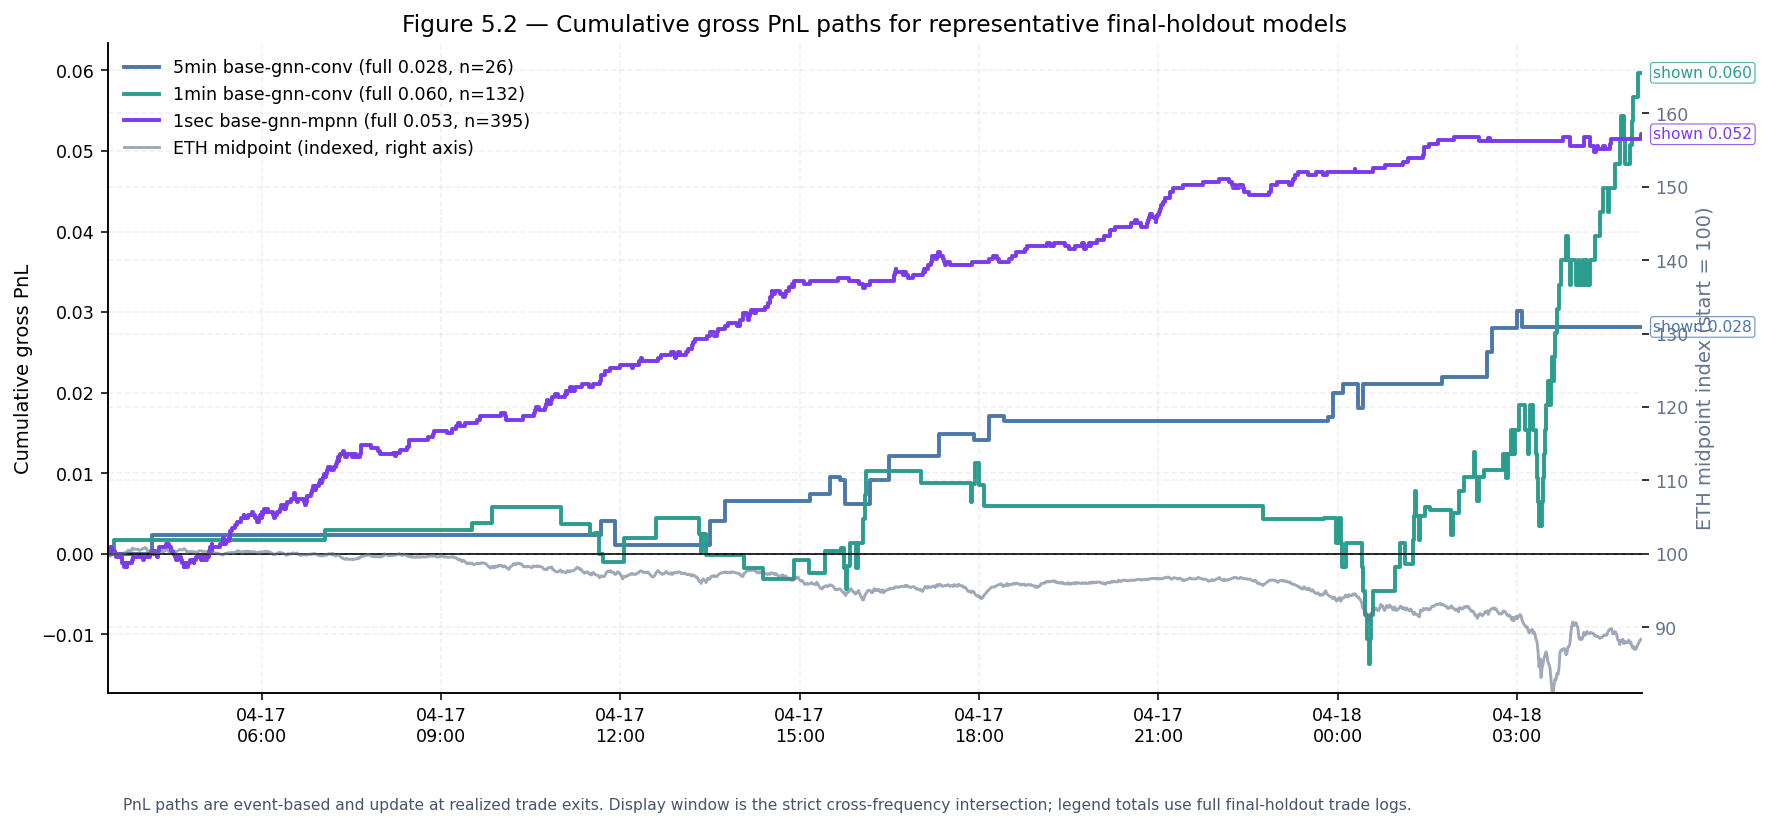

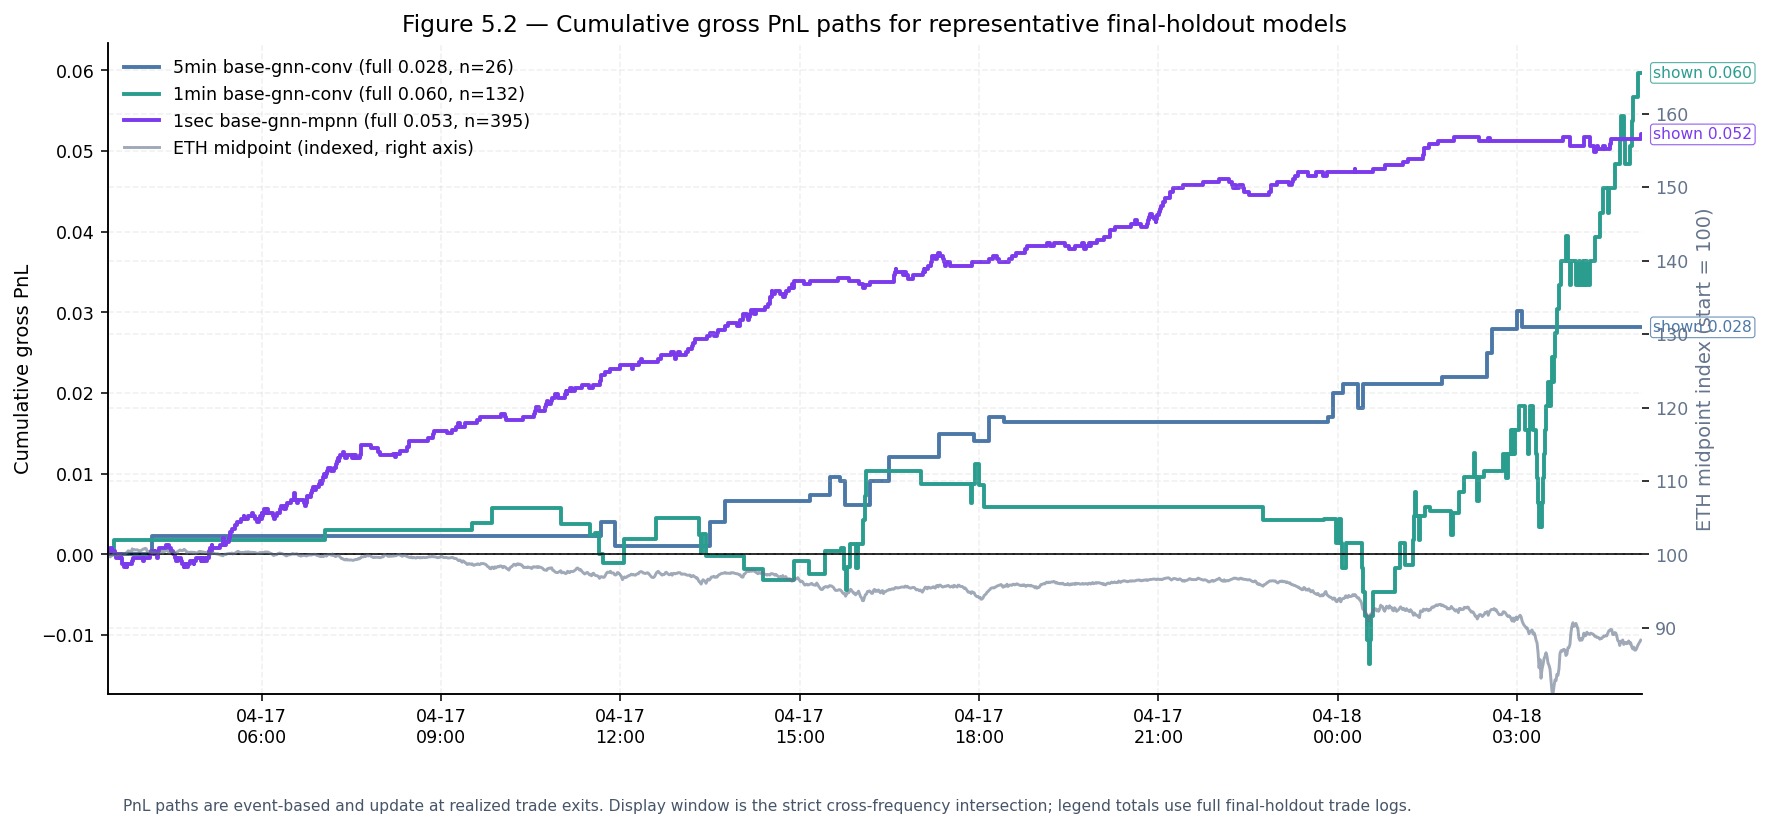

In [107]:
eth_reference = load_eth_midpoint_reference()
trade_path_cache = {}
for spec in REPRESENTATIVE_TRADE_PATH_SPECS:
    for metric in ["gross_pnl", "net_pnl"]:
        trade_path_cache[(spec["display_label"], metric)] = load_trade_path(spec, metric)

fig, ax = plt.subplots(figsize=(12.5, 5.8), constrained_layout=True)
ax2 = ax.twinx()

for spec in REPRESENTATIVE_TRADE_PATH_SPECS:
    path, full_total, n_trades = trade_path_cache[(spec["display_label"], "gross_pnl")]
    clipped, _, shown_end = path_on_window(path, "cum_gross_pnl", CROSS_FREQUENCY_DISPLAY_START, CROSS_FREQUENCY_DISPLAY_END)
    label = f"{spec['display_label']} (full {full_total:.3f}, n={n_trades})"
    ax.step(clipped["timestamp"], clipped["cum_gross_pnl"], where="post", linewidth=2.0, color=spec["color"], label=label)
    annotate_endpoint(ax, clipped["timestamp"].iloc[-1], shown_end, f"shown {shown_end:.3f}", spec["color"])

ax2.plot(
    eth_reference["system_time"],
    eth_reference["midpoint_index"],
    color=THESIS_COLORS["slate"],
    linewidth=1.5,
    alpha=0.62,
    label="ETH midpoint (indexed, right axis)",
)
ax.axhline(0, color="black", linewidth=0.9)
ax.set_xlim(CROSS_FREQUENCY_DISPLAY_START, CROSS_FREQUENCY_DISPLAY_END)
ax.set_ylabel("Cumulative gross PnL")
ax2.set_ylabel("ETH midpoint index (start = 100)", color=THESIS_COLORS["slate"])
ax2.tick_params(axis="y", labelcolor=THESIS_COLORS["slate"])
align_secondary_axis_value(ax, ax2, left_value=0.0, right_value=100.0, right_data=eth_reference["midpoint_index"])
ax.set_title("Figure 5.2 — Cumulative gross PnL paths for representative final-holdout models")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
handles_1, labels_1 = ax.get_legend_handles_labels()
handles_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(handles_1 + handles_2, labels_1 + labels_2, loc="upper left", frameon=False)
ax.text(
    0.01,
    -0.18,
    "PnL paths are event-based and update at realized trade exits. Display window is the strict cross-frequency intersection; legend totals use full final-holdout trade logs.",
    transform=ax.transAxes,
    fontsize=8,
    color="#475569",
)
fig


In [108]:
fig_5_2_path = save_thesis_figure(
    fig,
    figure_id="5.2",
    filename_stem="fig_5_2_trade_paths_gross_pnl",
    title="Cumulative gross PnL paths for representative final-holdout models",
    source_artifacts=['*_final_holdout_last_cv_trade_log.csv', '../Graph_Neural_Network_for_Market_Microstructure/dataset/ETH_1min.csv'],
    rendering_method="Python, artifact-grounded",
    main_text_section="Chapter 5",
    validation_checks="Path totals validated against expected artifact values; event-exit path note included.",
)
fig_5_2_path


PosixPath('/Users/vitalii/Desktop/Model_Market_Microstructure/GNN_for_LOB/paper_artifacts/figures_generated/fig_5_2_trade_paths_gross_pnl.png')

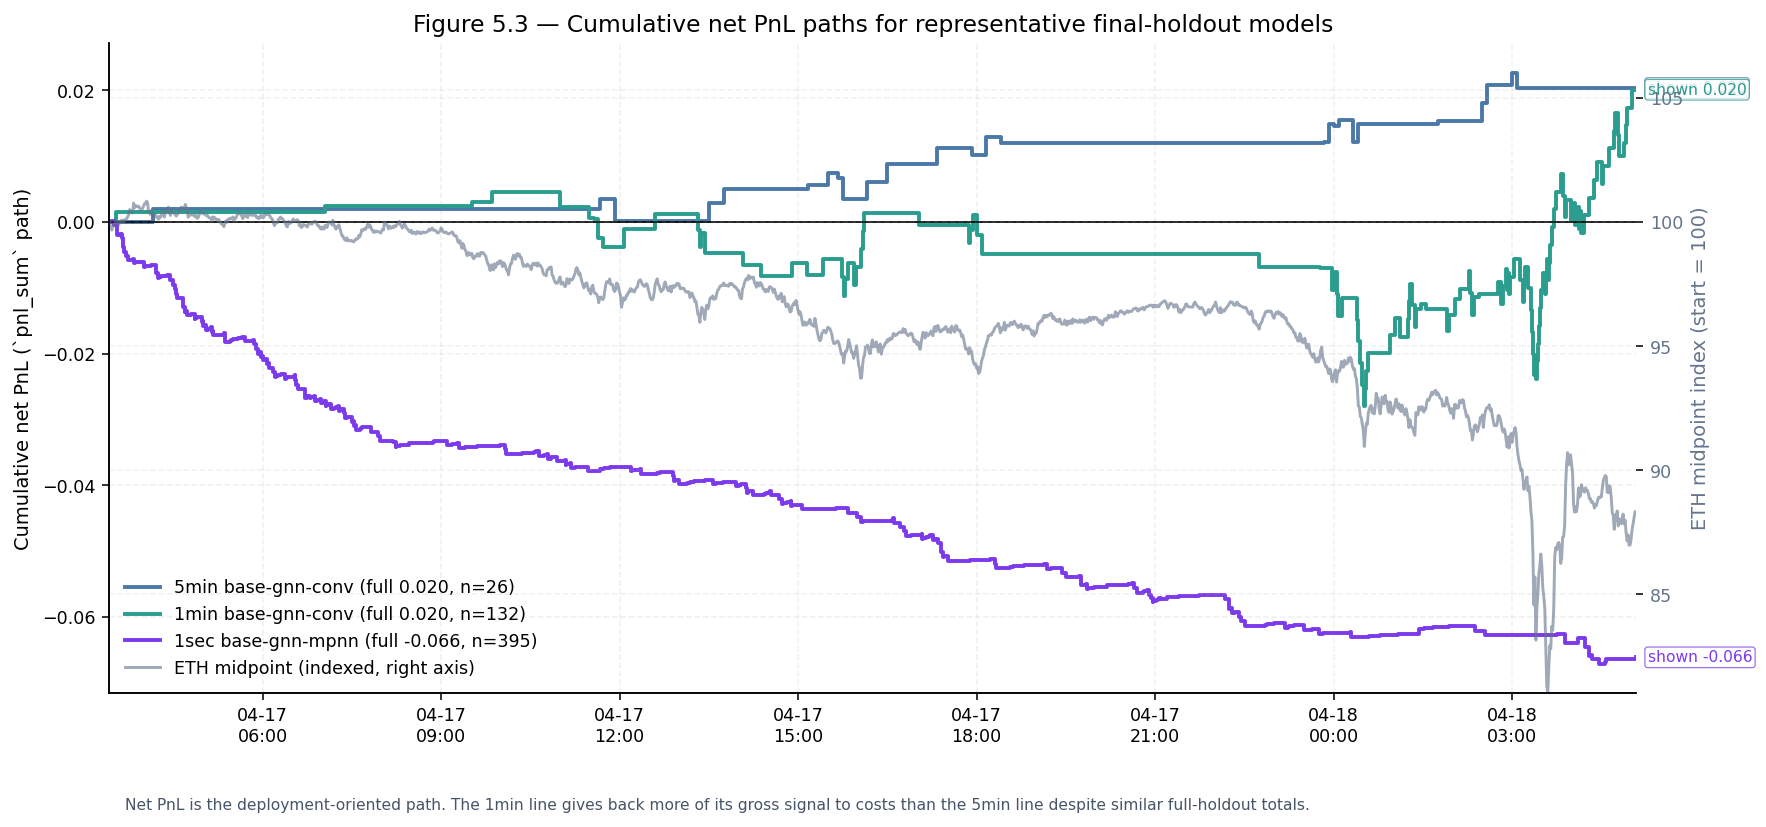

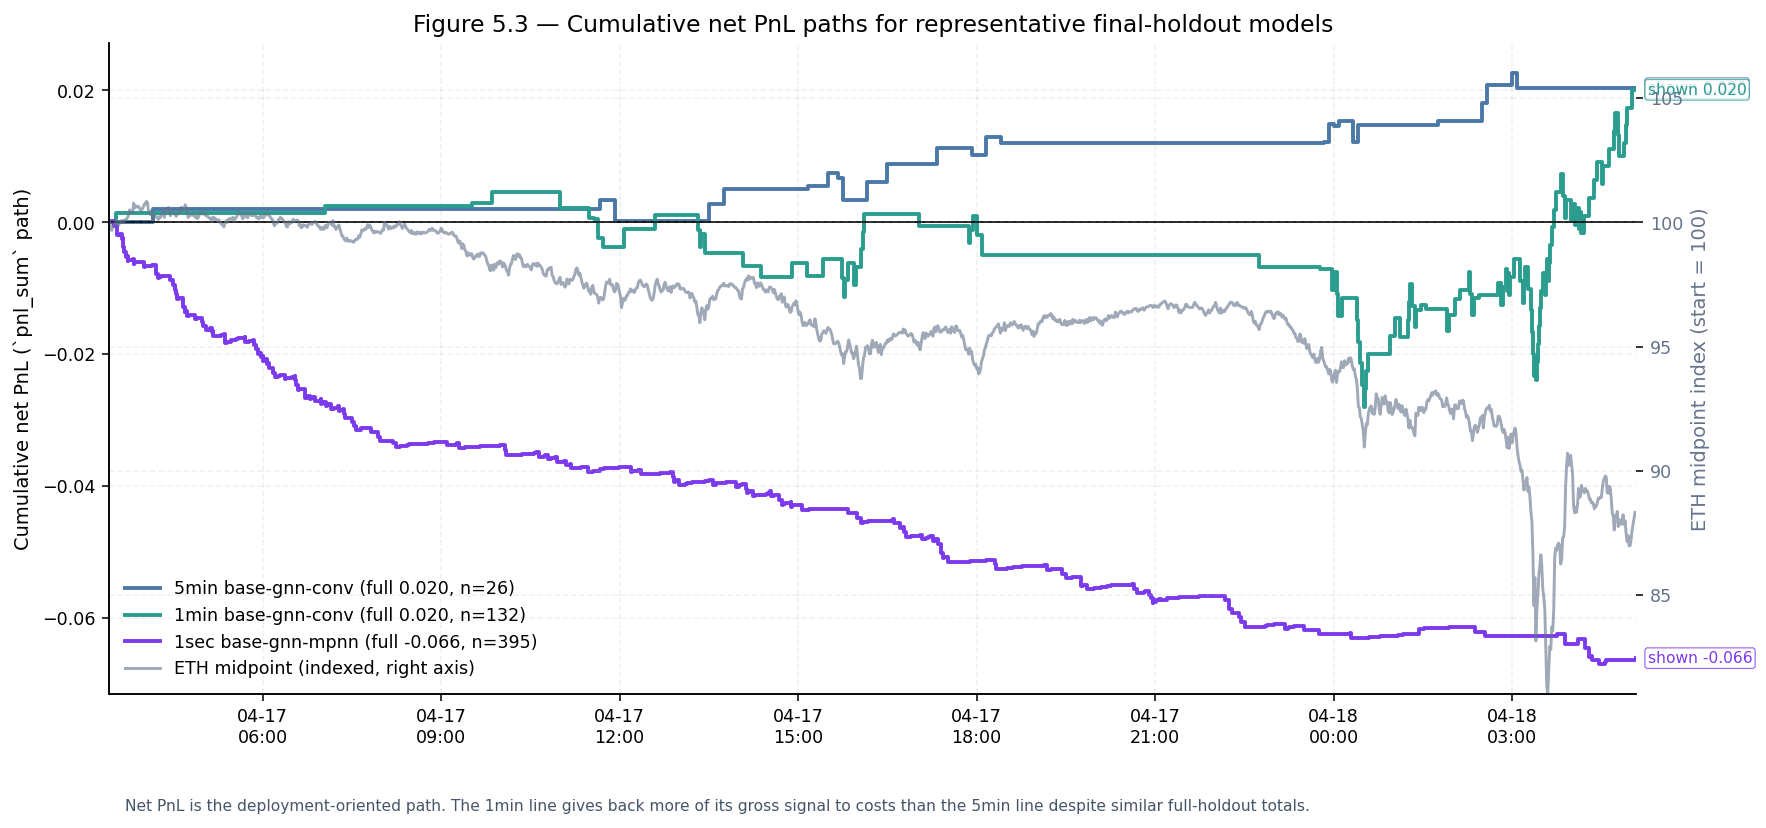

In [109]:
fig, ax = plt.subplots(figsize=(12.5, 5.8), constrained_layout=True)
ax2 = ax.twinx()

for spec in REPRESENTATIVE_TRADE_PATH_SPECS:
    path, full_total, n_trades = trade_path_cache[(spec["display_label"], "net_pnl")]
    clipped, _, shown_end = path_on_window(path, "cum_net_pnl", CROSS_FREQUENCY_DISPLAY_START, CROSS_FREQUENCY_DISPLAY_END)
    label = f"{spec['display_label']} (full {full_total:.3f}, n={n_trades})"
    ax.step(clipped["timestamp"], clipped["cum_net_pnl"], where="post", linewidth=2.0, color=spec["color"], label=label)
    annotate_endpoint(ax, clipped["timestamp"].iloc[-1], shown_end, f"shown {shown_end:.3f}", spec["color"])

ax2.plot(
    eth_reference["system_time"],
    eth_reference["midpoint_index"],
    color=THESIS_COLORS["slate"],
    linewidth=1.5,
    alpha=0.62,
    label="ETH midpoint (indexed, right axis)",
)
ax.axhline(0, color="black", linewidth=0.9)
ax.set_xlim(CROSS_FREQUENCY_DISPLAY_START, CROSS_FREQUENCY_DISPLAY_END)
ax.set_ylabel("Cumulative net PnL (`pnl_sum` path)")
ax2.set_ylabel("ETH midpoint index (start = 100)", color=THESIS_COLORS["slate"])
ax2.tick_params(axis="y", labelcolor=THESIS_COLORS["slate"])
align_secondary_axis_value(ax, ax2, left_value=0.0, right_value=100.0, right_data=eth_reference["midpoint_index"])
ax.set_title("Figure 5.3 — Cumulative net PnL paths for representative final-holdout models")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
handles_1, labels_1 = ax.get_legend_handles_labels()
handles_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(handles_1 + handles_2, labels_1 + labels_2, loc="lower left", frameon=False)
ax.text(
    0.01,
    -0.18,
    "Net PnL is the deployment-oriented path. The 1min line gives back more of its gross signal to costs than the 5min line despite similar full-holdout totals.",
    transform=ax.transAxes,
    fontsize=8,
    color="#475569",
)
fig


In [110]:
fig_5_3_path = save_thesis_figure(
    fig,
    figure_id="5.3",
    filename_stem="fig_5_3_trade_paths_net_pnl",
    title="Cumulative net PnL paths for representative final-holdout models",
    source_artifacts=['*_final_holdout_last_cv_trade_log.csv', '../Graph_Neural_Network_for_Market_Microstructure/dataset/ETH_1min.csv'],
    rendering_method="Python, artifact-grounded",
    main_text_section="Chapter 5",
    validation_checks="Net totals validated against expected artifact values; cost interpretation note included.",
)
fig_5_3_path


PosixPath('/Users/vitalii/Desktop/Model_Market_Microstructure/GNN_for_LOB/paper_artifacts/figures_generated/fig_5_3_trade_paths_net_pnl.png')

## Figure 5.4 — Gross versus net PnL at `1sec`

**Why this format**
- Python is best because the figure is a direct comparison of reported metrics and trade counts.

**Metadata**
- Figure type: `executable`
- Evidence source: `artifact-grounded`
- Rendering method: `Python`
- Primary inputs: `final_runs/1sec-*/final_report.csv`
- Acceptance check: six 1sec models, `gross_pnl_sum` and `pnl_sum`, `n_trades`, clear `memory-gnn-conv` cost-drag story


**Generation body**
- Build paired bars for gross vs net PnL.
- Annotate or encode `n_trades`.
- Add note explaining cost burden dominance under extreme turnover.

**Planned future code cells**
1. load 1sec summaries
2. prepare gross/net/trade-count table
3. render comparison chart
4. export figure


In [111]:
one_sec_df = benchmark_df[benchmark_df["frequency"] == "1sec"].copy().sort_values("order").reset_index(drop=True)
one_sec_df["x_label"] = one_sec_df["model_label"].map({
    "base-gnn-conv": "Base\nConv",
    "base-gnn-mpnn": "Base\nMPNN",
    "multi-gnn-conv": "Multi\nConv",
    "multi-gnn-mpnn": "Multi\nMPNN",
    "memory-gnn-conv": "Memory\nConv",
    "memory-gnn-mpnn": "Memory\nMPNN",
})
one_sec_df["cost_drag"] = one_sec_df["gross_pnl_sum"] - one_sec_df["pnl_sum"]
one_sec_df["implied_cost_drag"] = one_sec_df["n_trades"] * TRADE_COST
assert np.allclose(one_sec_df["cost_drag"], one_sec_df["implied_cost_drag"], atol=1e-8)
one_sec_df[["model_label", "gross_pnl_sum", "pnl_sum", "cost_drag", "n_trades", "trade_rate"]]


,model_label,gross_pnl_sum,pnl_sum,cost_drag,n_trades,trade_rate
0,base-gnn-conv,0.139515,-0.094185,0.2337,779,0.008406
1,base-gnn-mpnn,0.052679,-0.065821,0.1185,395,0.004263
2,multi-gnn-conv,0.081710,-0.108790,0.1905,635,0.006852
3,multi-gnn-mpnn,0.079777,-0.080723,0.1605,535,0.005773
4,memory-gnn-conv,0.412032,-1.163268,1.5753,5251,0.056665
5,memory-gnn-mpnn,0.223788,-0.280512,0.5043,1681,0.018140


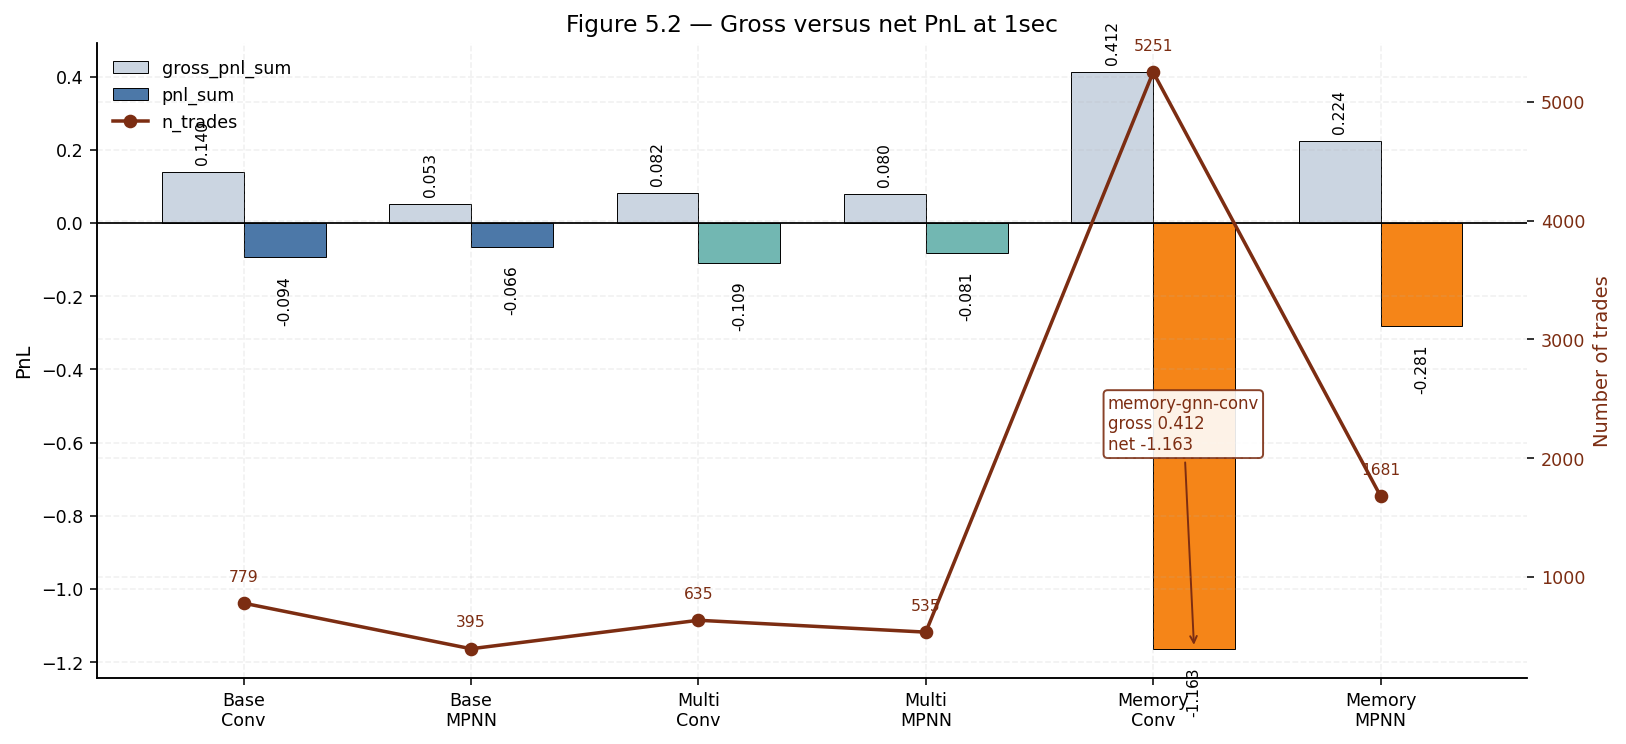

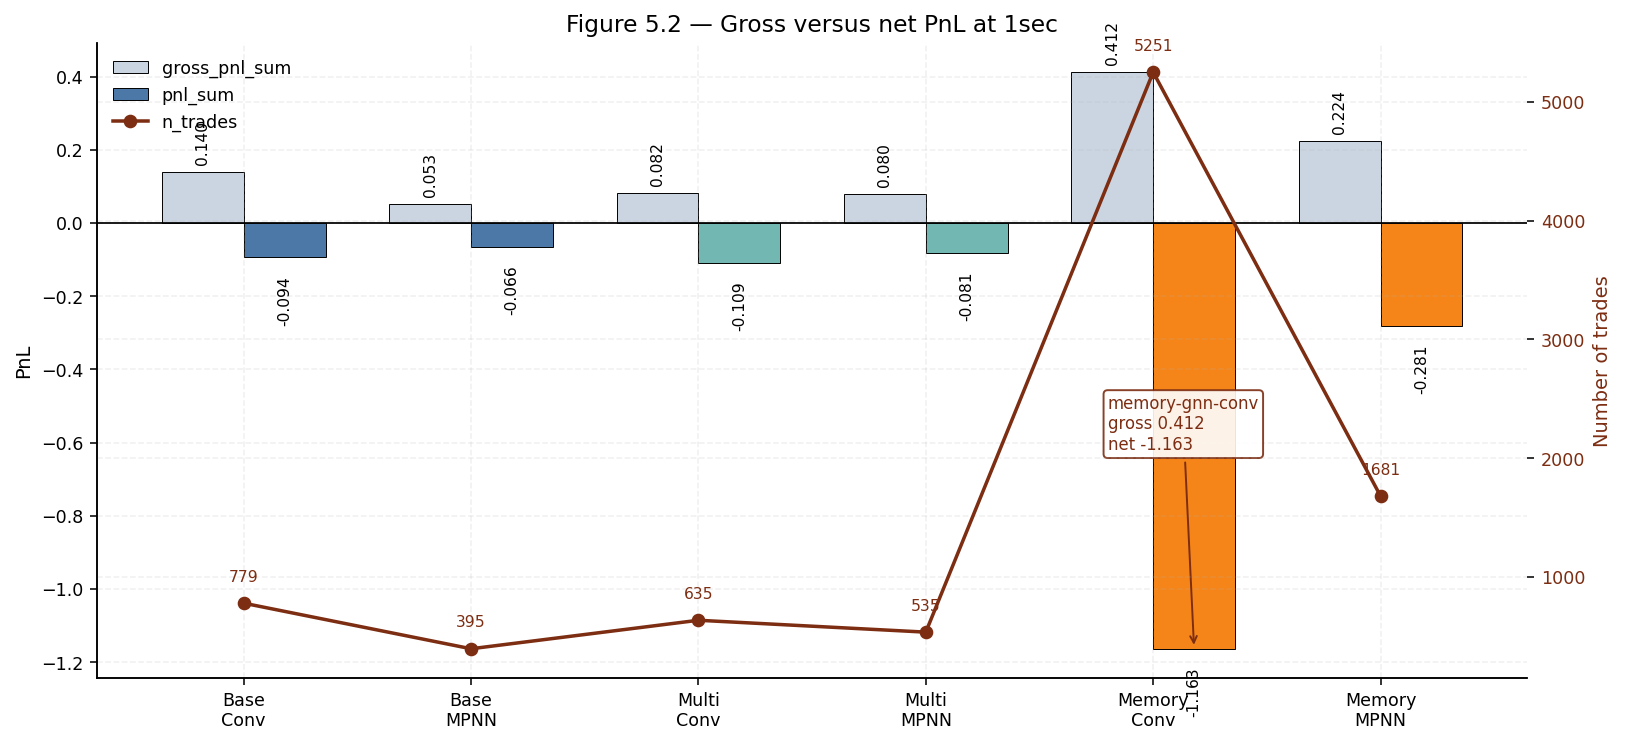

In [120]:
fig, ax = plt.subplots(figsize=(11.5, 5.2), constrained_layout=True)
x = np.arange(len(one_sec_df))
width = 0.36

ax.bar(x - width / 2, one_sec_df["gross_pnl_sum"], width=width, color="#cbd5e1", edgecolor="black", linewidth=0.5, label="gross_pnl_sum")
ax.bar(x + width / 2, one_sec_df["pnl_sum"], width=width, color=one_sec_df["family"].map(FAMILY_COLORS), edgecolor="black", linewidth=0.5, label="pnl_sum")
ax.axhline(0, color="black", linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels(one_sec_df["x_label"])
ax.set_ylabel("PnL")
ax.set_title("Figure 5.2 — Gross versus net PnL at 1sec")

for x_i, gross_value, net_value in zip(x, one_sec_df["gross_pnl_sum"], one_sec_df["pnl_sum"]):
    ax.text(x_i - width / 2, gross_value + 0.02, f"{gross_value:.3f}", ha="center", va="bottom", fontsize=8, rotation=90)
    ax.text(x_i + width / 2, net_value - 0.05 if net_value < 0 else net_value + 0.02, f"{net_value:.3f}", ha="center", va="top" if net_value < 0 else "bottom", fontsize=8, rotation=90)

ax2 = ax.twinx()
ax2.plot(x, one_sec_df["n_trades"], color="#7c2d12", marker="o", linewidth=1.8, label="n_trades")
ax2.set_ylabel("Number of trades", color="#7c2d12")
ax2.tick_params(axis="y", labelcolor="#7c2d12")
for x_i, trades in zip(x, one_sec_df["n_trades"]):
    ax2.text(x_i, trades + max(one_sec_df["n_trades"]) * 0.03, f"{int(trades)}", ha="center", va="bottom", fontsize=8, color="#7c2d12")

handles_1, labels_1 = ax.get_legend_handles_labels()
handles_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(handles_1 + handles_2, labels_1 + labels_2, loc="upper left", frameon=False)
#ax.text(0.98, 0.96, "memory-gnn-conv: strongest gross signal but\nturnover overwhelms post-cost viability", transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#7c2d12")

mem = one_sec_df[one_sec_df["model_label"] == "memory-gnn-conv"].iloc[0]
ax.annotate(
    f"memory-gnn-conv\ngross {mem['gross_pnl_sum']:.3f}\nnet {mem['pnl_sum']:.3f}",
    xy=(int(mem["order"]) + width / 2, mem["pnl_sum"]),
    xytext=(3.8, -0.62),
    arrowprops={"arrowstyle": "->", "color": "#7c2d12", "lw": 1.0},
    bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#7c2d12", "alpha": 0.9},
    fontsize=8.5,
    color="#7c2d12",
)
fig


In [121]:
# Figure 5.4 is rendered in the previous cell; this cell preserves the prepared plotting table for inspection.
one_sec_df[["model_label", "gross_pnl_sum", "pnl_sum", "cost_drag", "n_trades"]]


,model_label,gross_pnl_sum,pnl_sum,cost_drag,n_trades
0,base-gnn-conv,0.139515,-0.094185,0.2337,779
1,base-gnn-mpnn,0.052679,-0.065821,0.1185,395
2,multi-gnn-conv,0.081710,-0.108790,0.1905,635
3,multi-gnn-mpnn,0.079777,-0.080723,0.1605,535
4,memory-gnn-conv,0.412032,-1.163268,1.5753,5251
5,memory-gnn-mpnn,0.223788,-0.280512,0.5043,1681


In [122]:
fig_5_4_path = save_thesis_figure(
    fig,
    figure_id="5.4",
    filename_stem="fig_5_4_gross_vs_net_1sec",
    title="Gross versus net PnL at 1sec",
    source_artifacts=['final_runs/1sec-*/final_report.csv'],
    rendering_method="Python, artifact-grounded",
    main_text_section="Chapter 5",
    validation_checks="Exactly six 1sec models; cost drag equals n_trades × 0.0003.",
)
fig_5_4_path


PosixPath('/Users/vitalii/Desktop/Model_Market_Microstructure/GNN_for_LOB/paper_artifacts/figures_generated/fig_5_4_gross_vs_net_1sec.png')

## Figure 5.5 — One-second memory cost-drag path comparison

**Why this format**
- Python is mandatory because the figure reconstructs the cumulative gross-versus-net divergence directly from 1sec final-holdout trade logs.

**Metadata**
- Figure type: `executable`
- Evidence source: `artifact-grounded`
- Rendering method: `Python`
- Primary inputs: `1sec-memory-gnn-conv` and `1sec-base-gnn-mpnn` last_CV trade logs
- Acceptance check: one shared-axis chart with four cumulative paths (gross/net for memory-gnn-conv and base-gnn-mpnn), optional shaded transaction-cost drag, final gross/net/trade/cost annotations


In [ ]:
fig, ax = plt.subplots(figsize=(12.8, 6.4), constrained_layout=True)

cost_drag_cache = {}
line_handles = []
annotation_lines = []
for spec in ONE_SEC_COST_DRAG_SPECS:
    path, gross_total, net_total, n_trades, final_cost_drag = load_dual_metric_trade_path(spec)
    cost_drag_cache[spec["display_label"]] = (path, gross_total, net_total, n_trades, final_cost_drag)
    clipped_gross, _, shown_gross = path_on_window(path, "cum_gross_pnl", ONE_SEC_DISPLAY_START, ONE_SEC_DISPLAY_END)
    clipped_net, _, shown_net = path_on_window(path, "cum_net_pnl", ONE_SEC_DISPLAY_START, ONE_SEC_DISPLAY_END)
    merged = pd.merge_asof(
        clipped_gross.rename(columns={"cum_gross_pnl": "gross"}).sort_values("timestamp"),
        clipped_net.rename(columns={"cum_net_pnl": "net"}).sort_values("timestamp"),
        on="timestamp",
        direction="nearest",
        tolerance=pd.Timedelta(seconds=0),
    )
    if merged["net"].isna().any() or len(merged) != len(clipped_gross):
        merged = pd.DataFrame({
            "timestamp": clipped_gross["timestamp"],
            "gross": clipped_gross["cum_gross_pnl"].to_numpy(),
            "net": np.interp(
                mdates.date2num(clipped_gross["timestamp"]),
                mdates.date2num(clipped_net["timestamp"]),
                clipped_net["cum_net_pnl"],
            ),
        })
    gross_label = f"{spec['display_label']} gross"
    net_label = f"{spec['display_label']} net"
    gross_line = ax.step(
        clipped_gross["timestamp"],
        clipped_gross["cum_gross_pnl"],
        where="post",
        color=spec["color"],
        linewidth=2.1,
        linestyle="-",
        label=gross_label,
        zorder=3,
    )[0]
    net_line = ax.step(
        clipped_net["timestamp"],
        clipped_net["cum_net_pnl"],
        where="post",
        color=spec["color"],
        linewidth=2.1,
        linestyle="--",
        label=net_label,
        zorder=3,
    )[0]
    line_handles.extend([gross_line, net_line])
    ax.fill_between(
        merged["timestamp"],
        merged["gross"],
        merged["net"],
        step="post",
        color=spec["color"],
        alpha=0.10 if spec["model_label"] == "memory-gnn-conv" else 0.16,
        zorder=1,
    )
    annotation_lines.append(
        f"{spec['display_label']}: gross {gross_total:.3f}, net {net_total:.3f}, "
        f"trades {n_trades}, drag {final_cost_drag:.4f}"
    )

ax.axhline(0, color="black", linewidth=0.9)
ax.set_xlim(ONE_SEC_DISPLAY_START, ONE_SEC_DISPLAY_END)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
ax.set_xlabel("Final-holdout UTC clock time")
ax.set_ylabel("Cumulative PnL")
ax.set_title("Figure 5.5 — One-second cumulative gross-versus-net PnL paths")
ax.legend(handles=line_handles, loc="lower left", frameon=False, ncols=2)
ax.text(
    0.985,
    0.04,
    "\n".join(annotation_lines),
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8.3,
    bbox={"boxstyle": "round,pad=0.35", "fc": "white", "ec": "#cbd5e1", "alpha": 0.9},
)
ax.text(
    0.01,
    -0.18,
    "Single-axis view: solid lines are gross PnL, dashed lines are net PnL; shaded regions show each model's transaction-cost drag. The memory model's scale necessarily compresses the lower-turnover baseline.",
    transform=ax.transAxes,
    fontsize=8,
    color="#475569",
)
fig


In [ ]:
fig_5_5_path = save_thesis_figure(
    fig,
    figure_id="5.5",
    filename_stem="fig_5_5_1sec_memory_cost_drag_paths",
    title="One-second memory cost-drag path comparison",
    source_artifacts=['1sec-memory-gnn-conv trade log', '1sec-base-gnn-mpnn trade log'],
    rendering_method="Python, artifact-grounded",
    main_text_section="Chapter 5",
    validation_checks="Gross/net paths and shaded cost drag are built from trade logs.",
)
fig_5_5_path


In [ ]:
validation_rows = []
for spec in REPRESENTATIVE_TRADE_PATH_SPECS + [ONE_SEC_COST_DRAG_SPECS[0]]:
    path, gross_total, net_total, n_trades, final_cost_drag = load_dual_metric_trade_path(spec)
    expected_gross = spec["expected_gross"]
    expected_net = spec["expected_net"]
    assert abs(gross_total - expected_gross) <= 1e-9, (spec["display_label"], gross_total, expected_gross)
    assert abs(net_total - expected_net) <= 1e-9, (spec["display_label"], net_total, expected_net)
    assert abs(final_cost_drag - (gross_total - net_total)) <= 1e-12
    assert np.isclose(final_cost_drag, n_trades * TRADE_COST, atol=1e-9)
    validation_rows.append({
        "frequency": spec["frequency"],
        "model": spec["model_label"],
        "n_trades": n_trades,
        "gross_total": gross_total,
        "net_total": net_total,
        "cost_drag": final_cost_drag,
        "first_trade": path["timestamp"].iloc[1] if len(path) > 1 else pd.NaT,
        "last_trade": path["timestamp"].iloc[-1],
    })

for output_path in [fig_5_2_path, fig_5_3_path, fig_5_5_path]:
    assert output_path.exists() and output_path.stat().st_size > 0, output_path

eth_check = load_eth_midpoint_reference()
assert {"system_time", "midpoint"}.issubset(eth_check.columns)

trade_path_validation_summary = pd.DataFrame(validation_rows)
trade_path_validation_summary


## Figure 5.6 — `last_CV` versus `final_refit` as deployment-oriented model states

**Why this format**
- Python is appropriate because the comparison already exists in artifact tables and should be shown as a paired state comparison, not just as a conceptual diagram.

**Metadata**
- Figure type: `executable`
- Evidence source: `artifact-grounded`
- Rendering method: `Python`
- Primary inputs: `final_runs/*/final_report.csv`, `final_runs/**/*final_holdout_model_comparison_summary.csv`
- Acceptance check: `last_CV` vs `final_refit`, deployment-primary role of `last_CV`, informative-but-non-primary role of `final_refit`, representative model cases


**Generation body**
- Prefer slope chart or paired bars.
- Use selected representative models if full matrix is too dense.
- Preserve semantic emphasis: deployment reference vs larger-sample diagnostic comparison.

**Planned future code cells**
1. load state-comparison artifacts
2. choose representative cases
3. render paired state comparison
4. export figure


In [ ]:
state_case_files = {
    "5min | base-gnn-conv": REPO_ROOT / "final_runs/5min-base-gnn/adaptive_conv/adaptive_conv_final_holdout_model_comparison_summary.csv",
    "1min | base-gnn-conv": REPO_ROOT / "final_runs/1min-base-gnn-conv/adaptive_conv/adaptive_conv_final_holdout_model_comparison_summary.csv",
    "1sec | memory-gnn-conv": REPO_ROOT / "final_runs/1sec-memory-gnn-conv/conv/conv_final_holdout_model_comparison_summary.csv",
    "5min | multi-gnn-conv": REPO_ROOT / "final_runs/5min-multi-gnn/dynamic_rel_conv/dynamic_rel_conv_final_holdout_model_comparison_summary.csv",
}

state_rows = []
for case_label, csv_path in state_case_files.items():
    df = pd.read_csv(csv_path)
    df = df[df["model_role"].isin(["last_cv_fold_model", "final_refit_model"])].copy()
    df["case_label"] = case_label
    df["state"] = df["model_role"].map({"last_cv_fold_model": "last_CV", "final_refit_model": "final_refit"})
    state_rows.append(df[["case_label", "state", "pnl_sum", "dir_auc", "trade_auc", "n_trades", "gross_pnl_sum"]])

state_comparison_df = pd.concat(state_rows, ignore_index=True)
state_case_order = list(state_case_files.keys())
state_comparison_df["case_order"] = state_comparison_df["case_label"].map({label: i for i, label in enumerate(state_case_order)})
state_comparison_df["state_order"] = state_comparison_df["state"].map({"last_CV": 0, "final_refit": 1})
state_comparison_df.sort_values(["case_order", "state_order"])


In [ ]:
state_plot_df = state_comparison_df.sort_values(["case_order", "state_order"]).reset_index(drop=True)
state_colors = {"last_CV": "#4c78a8", "final_refit": "#f58518"}
state_y = np.arange(len(state_case_order))[::-1]


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6), constrained_layout=True)
for ax, metric, panel_title in zip(
    axes,
    ["pnl_sum", "dir_auc"],
    ["Economic outcome by model state", "Predictive ranking diagnostic by model state"],
):
    for i, case in enumerate(state_case_order):
        subset = state_plot_df[state_plot_df["case_label"] == case].sort_values("state_order")
        values = subset[metric].to_list()
        ax.plot(values, [state_y[i], state_y[i]], color="#94a3b8", linewidth=2.0, zorder=1)
        for _, row in subset.iterrows():
            ax.scatter(row[metric], state_y[i], s=90, color=state_colors[row["state"]], edgecolor="black", linewidth=0.4, zorder=3)
            text_dx = 0.008 if metric == "dir_auc" else 0.012
            ax.text(row[metric] + text_dx, state_y[i] + 0.07, f"{row[metric]:.3f}", fontsize=8, va="bottom")
    ax.set_yticks(state_y)
    ax.set_yticklabels(state_case_order)
    ax.set_title(panel_title)
    if metric == "pnl_sum":
        ax.axvline(0, color="black", linewidth=0.9)

axes[0].text(0.01, 1.05, "Figure 5.6 — `last_CV` versus `final_refit` as deployment-oriented model states", transform=axes[0].transAxes, fontsize=13, fontweight="bold", ha="left")
legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color, markeredgecolor="black", markersize=8, label=label)
    for label, color in state_colors.items()
]
axes[1].legend(handles=legend_handles, loc="lower right", frameon=False)
axes[0].text(
    0.01,
    -0.18,
    "Selected cases mirror the thesis discussion: two best shared-task models, one high-frequency stress example, and one informative multigraph refit case.",
    transform=axes[0].transAxes,
    fontsize=8,
    color="#475569",
)
fig


In [ ]:
fig_5_6_path = save_thesis_figure(
    fig,
    figure_id="5.6",
    filename_stem="fig_5_6_last_cv_vs_final_refit",
    title="Selected last_CV versus final_refit comparisons",
    source_artifacts=['*_final_holdout_model_comparison_summary.csv'],
    rendering_method="Python, artifact-grounded",
    main_text_section="Chapter 5",
    validation_checks="Both model states are visible for each selected case; last_CV role documented.",
)
fig_5_6_path


## Appendix Figure D.1 — Cost-sensitivity curves

**Why this format**
- Python is mandatory because the curves are derived from final-holdout gross PnL and trade counts.

**Metadata**
- Figure type: `executable`
- Evidence source: `artifact-grounded sensitivity analysis`
- Rendering method: `Python`
- Primary inputs: normalized `last_CV` benchmark table from `final_runs/*/final_report.csv`
- Acceptance check: curves equal reported `pnl_sum` at `cost_bps_per_side = 1.0`; benchmark cost marker visible; break-even labels shown when defined.


In [ ]:
cost_sensitivity_models = [
    ("5min", "base-gnn-conv"),
    ("1min", "base-gnn-conv"),
    ("1sec", "base-gnn-mpnn"),
    ("1sec", "memory-gnn-conv"),
    ("1min", "memory-gnn-mpnn"),
]
cost_grid_bps = np.linspace(0.0, 3.0, 301)
rows = []
for freq, label in cost_sensitivity_models:
    row = benchmark_df[(benchmark_df["frequency"] == freq) & (benchmark_df["model_label"] == label)].iloc[0]
    for cost_bps in cost_grid_bps:
        cost_per_trade = 3.0 * cost_bps * 1e-4
        rows.append({
            "frequency": freq,
            "model_label": label,
            "display_label": f"{freq} {label}",
            "cost_bps_per_side": cost_bps,
            "net_pnl": row["gross_pnl_sum"] - row["n_trades"] * cost_per_trade,
            "reported_pnl_sum": row["pnl_sum"],
            "gross_pnl_sum": row["gross_pnl_sum"],
            "n_trades": row["n_trades"],
        })

sens_df = pd.DataFrame(rows)
reported = sens_df[np.isclose(sens_df["cost_bps_per_side"], 1.0)]
for _, row in reported.iterrows():
    assert np.isclose(row["net_pnl"], row["reported_pnl_sum"], atol=1e-8), row
sens_df.head()


In [ ]:
fig, ax = plt.subplots(figsize=(10.8, 5.8), constrained_layout=True)
line_colors = {
    "5min base-gnn-conv": FAMILY_COLORS["base-gnn"],
    "1min base-gnn-conv": THESIS_COLORS["teal"],
    "1sec base-gnn-mpnn": THESIS_COLORS["purple"],
    "1sec memory-gnn-conv": FAMILY_COLORS["memory-gnn"],
    "1min memory-gnn-mpnn": "#b45309",
}
for display_label, subset in sens_df.groupby("display_label", sort=False):
    ax.plot(subset["cost_bps_per_side"], subset["net_pnl"], linewidth=2.0, color=line_colors.get(display_label, THESIS_COLORS["slate"]), label=display_label)
    first = subset.iloc[0]
    if first["gross_pnl_sum"] > 0 and first["n_trades"] > 0:
        break_even = first["gross_pnl_sum"] / (first["n_trades"] * 3e-4)
        if 0 <= break_even <= cost_grid_bps.max():
            ax.scatter([break_even], [0.0], s=38, color=line_colors.get(display_label, THESIS_COLORS["slate"]), edgecolor="black", linewidth=0.4, zorder=4)
            ax.text(break_even, 0.012, f"{break_even:.2f} bps", fontsize=7.5, ha="center", va="bottom", rotation=90)

ax.axhline(0, color="black", linewidth=0.9)
ax.axvline(1.0, color=THESIS_COLORS["slate"], linestyle="--", linewidth=1.1, label="benchmark 1.0 bps/side")
ax.set_xlabel("Assumed transaction cost per side (bps)")
ax.set_ylabel("Net PnL at fixed final-holdout gross signal and trade count")
ax.set_title("Appendix Figure D.1 — Cost-sensitivity curves for selected final-holdout models")
ax.legend(frameon=False, loc="upper right")
ax.text(
    0.01,
    -0.18,
    "Each curve uses net_pnl = gross_pnl_sum − n_trades × (3 × cost_bps_per_side × 10⁻⁴). Markers on y=0 indicate break-even costs when defined.",
    transform=ax.transAxes,
    fontsize=8,
    color="#475569",
)
fig


In [ ]:
appendix_fig_D_1_path = save_thesis_figure(
    fig,
    figure_id="D.1",
    filename_stem="appendix_fig_D_1_cost_sensitivity_curves",
    title="Cost-sensitivity curves for selected final-holdout models",
    source_artifacts=["final_runs/*/final_report.csv"],
    rendering_method="Python, artifact-grounded sensitivity analysis",
    main_text_section="Appendix D",
    validation_checks="At cost_bps_per_side=1.0, every curve equals the reported pnl_sum for the selected last_CV row.",
)
appendix_fig_D_1_path


## Appendix Figure D.2 — Trade count / turnover scatter

**Why this format**
- Python is mandatory because the scatter uses all eighteen `last_CV` configurations from normalized benchmark artifacts.

**Metadata**
- Figure type: `executable`
- Evidence source: `artifact-grounded diagnostic scatter`
- Rendering method: `Python`
- Primary inputs: normalized `last_CV` benchmark table from `final_runs/*/final_report.csv`
- Acceptance check: all 18 configurations, key labels, zero net-PnL reference, and no statistical-dominance claim.


In [ ]:
plot_df = benchmark_df.copy()
plot_df["display_label"] = plot_df["frequency"] + " " + plot_df["model_label"]
plot_df["marker_size"] = np.sqrt(plot_df["n_trades"].clip(lower=1)) * 9.0
freq_colors = {"5min": FAMILY_COLORS["base-gnn"], "1min": THESIS_COLORS["teal"], "1sec": THESIS_COLORS["orange"]}
family_markers = {"base-gnn": "o", "multi-gnn": "s", "memory-gnn": "^"}
label_keys = {
    ("5min", "base-gnn-conv"): "5min base-conv",
    ("1min", "base-gnn-conv"): "1min base-conv",
    ("1sec", "base-gnn-mpnn"): "1sec base-mpnn",
    ("1sec", "memory-gnn-conv"): "1sec memory-conv",
}
len(plot_df), plot_df[["frequency", "model_label", "trade_rate", "gross_pnl_sum", "pnl_sum", "n_trades"]].head()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.8), constrained_layout=True)

for ax in axes:
    ax.axhline(0, color="black", linewidth=0.9)

for family, marker in family_markers.items():
    subset_family = plot_df[plot_df["family"] == family]
    for freq, color in freq_colors.items():
        subset = subset_family[subset_family["frequency"] == freq]
        if subset.empty:
            continue
        axes[0].scatter(subset["trade_rate"], subset["pnl_sum"], s=70, marker=marker, color=color, edgecolor="black", linewidth=0.45, alpha=0.86)
        axes[1].scatter(subset["gross_pnl_sum"], subset["pnl_sum"], s=subset["marker_size"], marker=marker, color=color, edgecolor="black", linewidth=0.45, alpha=0.78)

axes[0].set_xlabel("Trade rate")
axes[0].set_ylabel("Net PnL (`pnl_sum`)")
axes[0].set_title("A. Turnover versus post-cost outcome")
axes[1].set_xlabel("Gross PnL (`gross_pnl_sum`)")
axes[1].set_ylabel("Net PnL (`pnl_sum`)")
axes[1].set_title("B. Gross signal versus net outcome\n(marker size ∝ √n_trades)")
min_val = min(plot_df["gross_pnl_sum"].min(), plot_df["pnl_sum"].min())
max_val = max(plot_df["gross_pnl_sum"].max(), plot_df["pnl_sum"].max())
axes[1].plot([min_val, max_val], [min_val, max_val], color=THESIS_COLORS["slate"], linestyle=":", linewidth=1.0, label="net = gross (no costs)")

for _, row in plot_df.iterrows():
    key = (row["frequency"], row["model_label"])
    if key in label_keys:
        label = label_keys[key]
        axes[0].annotate(label, (row["trade_rate"], row["pnl_sum"]), xytext=(5, 5), textcoords="offset points", fontsize=8)
        axes[1].annotate(label, (row["gross_pnl_sum"], row["pnl_sum"]), xytext=(5, 5), textcoords="offset points", fontsize=8)

freq_handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color, markeredgecolor="black", markersize=8, label=freq) for freq, color in freq_colors.items()]
family_handles = [plt.Line2D([0], [0], marker=marker, color="w", markerfacecolor="white", markeredgecolor="black", markersize=8, label=family) for family, marker in family_markers.items()]
axes[0].legend(handles=freq_handles + family_handles, frameon=False, loc="lower left", ncols=2)
axes[1].legend(frameon=False, loc="lower right")
fig.suptitle("Appendix Figure D.2 — Turnover, gross signal, and post-cost net PnL across last_CV configurations", fontsize=13)
axes[0].text(
    0.0,
    -0.22,
    "All eighteen last_CV configurations are included. The scatter is diagnostic only and does not represent a formal significance test.",
    transform=axes[0].transAxes,
    fontsize=8,
    color="#475569",
)
fig


In [ ]:
appendix_fig_D_2_path = save_thesis_figure(
    fig,
    figure_id="D.2",
    filename_stem="appendix_fig_D_2_turnover_scatter",
    title="Turnover, gross signal, and post-cost net PnL across last_CV configurations",
    source_artifacts=["final_runs/*/final_report.csv"],
    rendering_method="Python, artifact-grounded diagnostic scatter",
    main_text_section="Appendix D",
    validation_checks="All 18 last_CV rows are plotted; key points are labelled; zero net-PnL line is visible.",
)
appendix_fig_D_2_path


## Figure 6.1 — Deployment interpretation from prediction to post-cost evidence

**Why this format**
- ASCII works well because this is a reasoning chain rather than a data graphic.

**Metadata**
- Figure type: `conceptual`
- Evidence source: `thesis-only`
- Rendering method: `ASCII`
- Primary inputs: `co_om_thesis_enhanced.md`
- Acceptance check: predictive ranking, gross signal extraction, trade selectivity, cost adjustment, model-state stability, deployment-informative conclusion


**Generation body — final ASCII**

```text
 prediction quality
 (ranking diagnostics)
         │
         ▼
 gross signal extraction
 (`gross_pnl_sum` before cost)
         │
         ▼
 trade selectivity / turnover
 (`n_trades`, activity discipline)
         │
         ▼
 transaction-cost adjustment
 (gross edge must survive frictions)
         │
         ▼
 model-state stability
 (`last_CV` vs `final_refit` interpretation)
         │
         ▼
 deployment-informative evidence
 (`pnl_sum` after cost, with stable interpretation)
```


## Figure 7.1 — Future research roadmap for deployment-oriented graph LOB prediction

**Why this format**
- Manual-vector-first is the safest option because the roadmap is dense, conceptual, and taxonomy-sensitive; prompt can help as a draft, but should not be the authoritative final form.

**Metadata**
- Figure type: `conceptual`
- Evidence source: `thesis-only`
- Rendering method: `Manual-vector-first with prompt fallback`
- Primary inputs: `co_om_thesis_enhanced.md`
- Acceptance check: all seven roadmap directions present, thesis-faithful taxonomy, clear grouping, no generic fintech clichés


**Generation body — final image prompt fallback**

```text
Create an academic roadmap infographic for a master's thesis in graph-based market microstructure modelling.

Title: "Future research roadmap for deployment-oriented graph LOB prediction"

Central concept:
A roadmap centered on deployment-oriented graph LOB prediction.

Surrounding thematic branches:
1. turnover-aware learning
2. execution-aware evaluation
3. larger graph universes
4. selective memory mechanisms
5. regime robustness
6. uncertainty quantification
7. cost-sensitivity analysis

Important semantic constraint:
This figure is a future research agenda for a controlled benchmark thesis.
```


## Summary table

| Figure | Recommended rendering | Evidence source | Priority |
|---|---|---|---|
| 1.1 | Python/vector preferred; existing image prompt fallback | Mixed | Medium |
| 1.2 | Python | Thesis-only | High |
| 3.1 | Python | Code-grounded | Medium |
| 3.2 | Python | Artifact-grounded | High |
| 3.3 | Python-primary | Mixed | Medium |
| 3.4 | Python vector | Thesis/protocol-grounded | High |
| 3.5 | Python | Artifact-grounded | High |
| 3.6 | Python vector | Thesis/protocol-grounded | High |
| 4.1 | Python vector | Code-grounded | Medium |
| 4.2 | Python vector | Code-grounded | Medium |
| 5.1 | Python | Artifact-grounded | High |
| 5.2 | Python | Artifact-grounded | High |
| 5.3 | Python | Artifact-grounded | High |
| 5.4 | Python | Artifact-grounded | High |
| 5.5 | Python | Artifact-grounded | High |
| 5.6 | Python | Artifact-grounded | Medium |
| D.1 | Python | Artifact-grounded sensitivity analysis | High |
| D.2 | Python | Artifact-grounded diagnostic scatter | High |
| 6.1 | ASCII or Python vector | Thesis-only | Medium |
| 7.1 | Manual-vector-first, prompt fallback | Thesis-only | Medium |


## Recommended implementation order

1. highest-confidence artifact-grounded empirical figures: 3.2, 3.5, 5.1, 5.2, 5.3, 5.4, D.1, D.2
2. simple conceptual/vector figures: 1.2, 3.1, 3.4, 3.6
3. code-grounded architecture figures: 4.1, 4.2
4. hybrid/conceptual figures that may retain prompts as drafts: 1.1, 3.3, 6.1, 7.1
5. thesis integration pass: verify generated paths, captions, manifest, and absence of draft-caption placeholder wording.


## Final validation and figure manifest

This cell validates required generated outputs, re-checks benchmark cost consistency, and writes the machine-readable and markdown figure manifest.


In [ ]:
required_outputs = [
    "fig_1_2_research_question_map.png",
    "fig_3_1_graph_input_representation.png",
    "fig_3_2_split_design_v2.png",
    "fig_3_3_triple_barrier_eth_midpoint.png",
    "fig_3_4_entry_backtest_post_cost_pnl.png",
    "fig_3_5_walkforward_model_states.png",
    "fig_3_6_metric_hierarchy.png",
    "fig_4_1_architecture_comparison.png",
    "fig_4_2_memorygraph_recurrent_memory_update.png",
    "fig_5_1_benchmark_overview.png",
    "fig_5_2_trade_paths_gross_pnl.png",
    "fig_5_3_trade_paths_net_pnl.png",
    "fig_5_4_gross_vs_net_1sec.png",
    "fig_5_5_1sec_memory_cost_drag_paths.png",
    "fig_5_6_last_cv_vs_final_refit.png",
    "appendix_fig_D_1_cost_sensitivity_curves.png",
    "appendix_fig_D_2_turnover_scatter.png",
]
for name in required_outputs:
    path = FIGURES_DIR / name
    assert path.exists() and path.stat().st_size > 0, path

optional_conceptual_outputs = [
    "fig_1_1_ChatGPT_Image.png",
]
optional_present = [name for name in optional_conceptual_outputs if (FIGURES_DIR / name).exists()]

cost_check_df = load_benchmark_metrics(model_state="last_cv")
assert np.allclose(cost_check_df["gross_pnl_sum"] - cost_check_df["pnl_sum"], cost_check_df["n_trades"] * TRADE_COST, atol=1e-8)
assert len(cost_check_df) == 18
assert len(plot_df) == 18
manifest_df, manifest_csv_path, manifest_md_path = write_manifest()
assert manifest_csv_path.exists() and manifest_csv_path.stat().st_size > 0
assert manifest_md_path.exists() and manifest_md_path.stat().st_size > 0
assert set(["5.4", "5.5", "5.6", "D.1", "D.2"]).issubset(set(manifest_df["figure_id"]))
{
    "required_outputs": len(required_outputs),
    "optional_present": optional_present,
    "manifest_rows": len(manifest_df),
    "manifest_csv": str(manifest_csv_path),
    "manifest_md": str(manifest_md_path),
}
